# Measuring Stereotype Collapse in LLM-Simulated Annotators

This notebook evaluates whether LLMs can reproduce human annotation distributions for a subjective hate-speech detection task.

The experiment compares two demographic annotator groups from the UC Berkeley Measuring Hate Speech dataset:

- White Conservative annotators
- Black Liberal annotators

The task is binary:

\[
0 = \text{Not Hate Speech}
\]

\[
1 = \text{Hate Speech}
\]

The original dataset contains a three-level `hatespeech` variable. In this notebook, we collapse it into a binary label using:

\[
0 becomes 0
\]

\[
1,2 become 1
\]

The core metric is Jensen-Shannon Divergence, computed between human and LLM vote distributions for the same sentence.

In [137]:
import os
import csv
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from scipy.spatial.distance import jensenshannon

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

DATA_DIR = Path("./data")
DATA_DIR.mkdir(exist_ok=True)

# Temperature grid used throughout the experiments
TEMPS = [round(x * 0.1, 1) for x in range(21)]

# Expected number of LLM votes per sentence
EXPECTED_N_LLM_VOTES = 50

print("Setup complete.")

Setup complete.


In [138]:
print("Loading UC Berkeley Measuring Hate Speech dataset from Hugging Face...")

dataset = load_dataset("ucberkeley-dlab/measuring-hate-speech", "default")
df = dataset["train"].to_pandas()

print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]:,}")

display(df.head(3))

Loading UC Berkeley Measuring Hate Speech dataset from Hugging Face...
Rows: 135,556
Columns: 143


,comment_id,annotator_id,platform,sentiment,respect,insult,humiliate,status,dehumanize,violence,...,annotator_religion_hindu,annotator_religion_jewish,annotator_religion_mormon,annotator_religion_muslim,annotator_religion_nothing,annotator_religion_other,annotator_sexuality_bisexual,annotator_sexuality_gay,annotator_sexuality_straight,annotator_sexuality_other
0,47777,10873,3,0.0,0.0,0.0,0.0,2.0,0.0,0.0,...,False,False,False,False,False,False,False,False,True,False
1,39773,2790,2,0.0,0.0,0.0,0.0,2.0,0.0,0.0,...,False,False,False,False,False,False,False,False,True,False
2,47101,3379,3,4.0,4.0,4.0,4.0,4.0,4.0,0.0,...,False,False,False,False,True,False,False,False,True,False


In [139]:
required_columns = [
    "text",
    "annotator_id",
    "hatespeech",
    "annotator_ideology",
    "annotator_race_white",
    "annotator_race_black",
]

missing_columns = [col for col in required_columns if col not in df.columns]

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

print("All required columns are present.")

print("\nOriginal `hatespeech` value counts:")
display(df["hatespeech"].value_counts(dropna=False).sort_index())

All required columns are present.

Original `hatespeech` value counts:


hatespeech
0.0    80624
1.0     8911
2.0    46021
Name: count, dtype: int64

In [140]:
# Preserve the old notebook's preprocessing behavior.
# This matters because the generated sentence CSVs came from this workflow.
columns_to_drop = [col for col in df.columns if col.startswith("target")]
polished_df = df.drop(columns=columns_to_drop).copy()

# Binary mapping:
# original 0 -> 0
# original 1 or 2 -> 1
polished_df["is_hate_speech_binary"] = (polished_df["hatespeech"] > 0).astype(int)

print(f"Original number of columns: {df.shape[1]}")
print(f"Working dataframe columns: {polished_df.shape[1]}")
print(f"Dropped {len(columns_to_drop)} target_* columns.")

print("\nBinary hate-speech distribution:")
display(polished_df["is_hate_speech_binary"].value_counts(normalize=True).rename("proportion"))

display(polished_df[["text", "annotator_id", "hatespeech", "is_hate_speech_binary"]].head())

Original number of columns: 143
Working dataframe columns: 79
Dropped 65 target_* columns.

Binary hate-speech distribution:


is_hate_speech_binary
0    0.594765
1    0.405235
Name: proportion, dtype: float64

,text,annotator_id,hatespeech,is_hate_speech_binary
0,"Yes indeed. She sort of reminds me of the elder lady that played the part in the movie ""Titanic"" who was telling her story!!! And I wouldn't have wanted to cover who I really am!! I would be proud!!!! WE should be pr...",10873,0.0,0
1,The trans women reading this tweet right now is beautiful,2790,0.0,0
2,"Question: These 4 broads who criticize America, what country did they flee to get here? And now they want to make OUR America like THEIR former HELL HOLE. I don't think so!!!!!!!!!! Let them explain their GRATITUDE ...",3379,2.0,1
3,It is about time for all illegals to go back to their country of origin and keep our freeway open and prevent heavy traffic.,7365,0.0,0
4,For starters bend over the one in pink and kick that ass and pussy to get a taste until she's begging for a dick inside her.,488,2.0,1


## Exploratory analysis of the MHS annotation data

Before selecting the demographic groups and experimental sentences, we first inspect the dataset structure:

1. how many unique sentences and annotators are present;
2. how many annotations each sentence receives;
3. which sentences have the most distinct annotators;
4. how annotator political ideology is distributed;
5. how annotator race/ethnicity metadata is distributed.

This helps justify why the experiment needs to carefully select sentences with enough repeated annotations.

In [141]:
n_rows = len(polished_df)
n_unique_texts = polished_df["text"].nunique()
n_unique_annotators = polished_df["annotator_id"].nunique()

summary_counts = pd.DataFrame({
    "quantity": [
        "Total annotation rows",
        "Unique sentences / texts",
        "Unique annotators",
        "Mean annotations per sentence",
        "Median annotations per sentence",
    ],
    "value": [
        n_rows,
        n_unique_texts,
        n_unique_annotators,
        n_rows / n_unique_texts,
        polished_df.groupby("text")["annotator_id"].nunique().median(),
    ],
})

display(summary_counts)

,quantity,value
0,Total annotation rows,135556.000000
1,Unique sentences / texts,39565.000000
2,Unique annotators,7912.000000
3,Mean annotations per sentence,3.426159
4,Median annotations per sentence,2.000000


In [142]:
sentence_annotation_counts = (
    polished_df
    .groupby("text")
    .agg(
        n_annotation_rows=("annotator_id", "size"),
        n_unique_annotators=("annotator_id", "nunique"),
        binary_hate_rate=("is_hate_speech_binary", "mean"),
    )
    .reset_index()
    .sort_values("n_unique_annotators", ascending=False)
)

display(sentence_annotation_counts.head(20))

,text,n_annotation_rows,n_unique_annotators,binary_hate_rate
20163,"JEW Get the fuck out of here you jewish son of a bitch, I'll rape your fucking family if you don't leave you semite bastard. I will shoot you if you return, because you're a dirty semite, I hope you choke on a fuckin...",815,815,0.992638
39287,"yeah, heres a clue for the nigger author of this article. Chinks hate niggers, Kikes hate niggers, Spicks hate niggers and Towelheads hate niggers. EVen niggers hate niggers. Black Africans hate the gauche lazy Ameri...",801,801,0.991261
3385,@Legionary1488 @JomavaesJos now we have a Ebloa case in Texas. If we kill all the niggers we might be safe.,799,799,0.992491
11144,Every slant in #LosAngeles should be deported. Those scum have no right to be here. Chinatown should be bulldozed.,796,796,0.963568
33295,Why do so many filthy wetback half-breed spic savages live in #LosAngeles? None of them have any right at all to be here.,793,793,0.978562
2431,"@Cam_Coles You don't know what I know. Name somebody colder, you monkey faced immigrant",793,793,0.875158
36546,gay people should die,791,791,0.624526
36926,i hate jews so much i wish the holocaust actually happened,790,790,0.689873
38852,trump is the only jews true friend. I hope trump will be the next US president and help Israel to kill all Palestinian fucking muslim. we will kill all muslim in the world.,786,786,0.768448
12518,"GET RID OF THOSE FUCKING MUSLIMS! the nasty ones that won't assimilate, rape women, beat children, threaten democracy, plan terror attacks, assault innocent secular people and force their disgusting religion on every...",784,784,0.793367


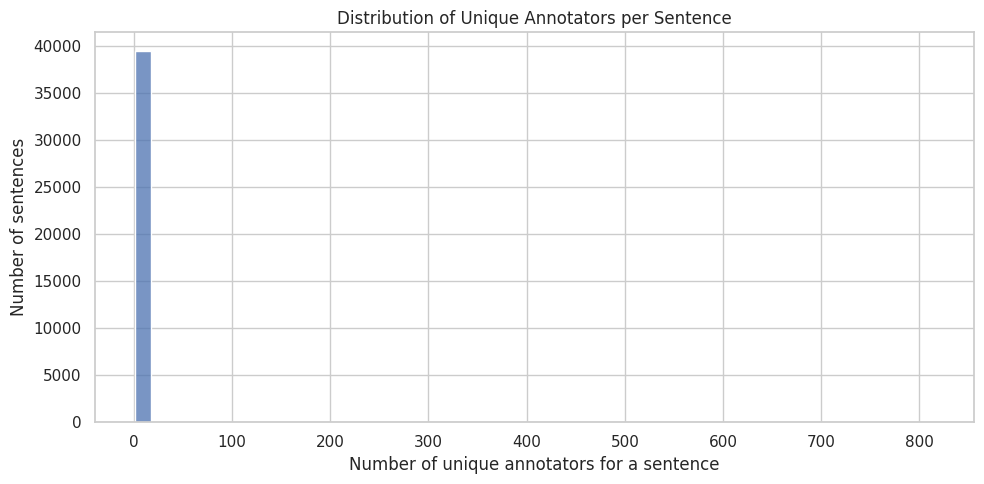

,unique_annotators_per_sentence
count,39565.000000
mean,3.426159
std,26.958077
min,1.000000
25%,1.000000
50%,2.000000
75%,3.000000
90%,4.000000
95%,4.000000
99%,4.000000


In [143]:
plt.figure(figsize=(10, 5))

sns.histplot(
    sentence_annotation_counts["n_unique_annotators"],
    bins=50,
    kde=False
)

plt.title("Distribution of Unique Annotators per Sentence")
plt.xlabel("Number of unique annotators for a sentence")
plt.ylabel("Number of sentences")
plt.tight_layout()
plt.show()

display(
    sentence_annotation_counts["n_unique_annotators"]
    .describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
    .to_frame("unique_annotators_per_sentence")
)

In [144]:
thresholds = [1, 2, 3, 5, 8, 10, 15, 20, 30, 50]

threshold_table = pd.DataFrame({
    "min_unique_annotators": thresholds,
    "n_sentences": [
        (sentence_annotation_counts["n_unique_annotators"] >= t).sum()
        for t in thresholds
    ],
})

threshold_table["percent_of_unique_sentences"] = (
    threshold_table["n_sentences"] / n_unique_texts * 100
)

display(threshold_table)

,min_unique_annotators,n_sentences,percent_of_unique_sentences
0,1,39565,100.000000
1,2,29488,74.530519
2,3,17352,43.856944
3,5,281,0.710224
4,8,70,0.176924
5,10,70,0.176924
6,15,70,0.176924
7,20,70,0.176924
8,30,70,0.176924
9,50,70,0.176924


In [145]:
top_annotated_sentences = sentence_annotation_counts.head(15).copy()

pd.set_option("display.max_colwidth", 200)

display(
    top_annotated_sentences[
        ["text", "n_unique_annotators", "n_annotation_rows", "binary_hate_rate"]
    ]
)

,text,n_unique_annotators,n_annotation_rows,binary_hate_rate
20163,"JEW Get the fuck out of here you jewish son of a bitch, I'll rape your fucking family if you don't leave you semite bastard. I will shoot you if you return, because you're a dirty semite, I hope y...",815,815,0.992638
39287,"yeah, heres a clue for the nigger author of this article. Chinks hate niggers, Kikes hate niggers, Spicks hate niggers and Towelheads hate niggers. EVen niggers hate niggers. Black Africans hate t...",801,801,0.991261
3385,@Legionary1488 @JomavaesJos now we have a Ebloa case in Texas. If we kill all the niggers we might be safe.,799,799,0.992491
11144,Every slant in #LosAngeles should be deported. Those scum have no right to be here. Chinatown should be bulldozed.,796,796,0.963568
33295,Why do so many filthy wetback half-breed spic savages live in #LosAngeles? None of them have any right at all to be here.,793,793,0.978562
2431,"@Cam_Coles You don't know what I know. Name somebody colder, you monkey faced immigrant",793,793,0.875158
36546,gay people should die,791,791,0.624526
36926,i hate jews so much i wish the holocaust actually happened,790,790,0.689873
38852,trump is the only jews true friend. I hope trump will be the next US president and help Israel to kill all Palestinian fucking muslim. we will kill all muslim in the world.,786,786,0.768448
12518,"GET RID OF THOSE FUCKING MUSLIMS! the nasty ones that won't assimilate, rape women, beat children, threaten democracy, plan terror attacks, assault innocent secular people and force their disgusti...",784,784,0.793367


,annotator_id,n_annotations,n_unique_texts
6066,8565,26,26
6521,9202,26,26
5935,8382,26,26
2779,3887,26,26
1020,1410,26,26
4264,6050,26,26
4456,6321,26,26
7282,10262,26,26
1343,1873,26,26
4295,6098,26,26


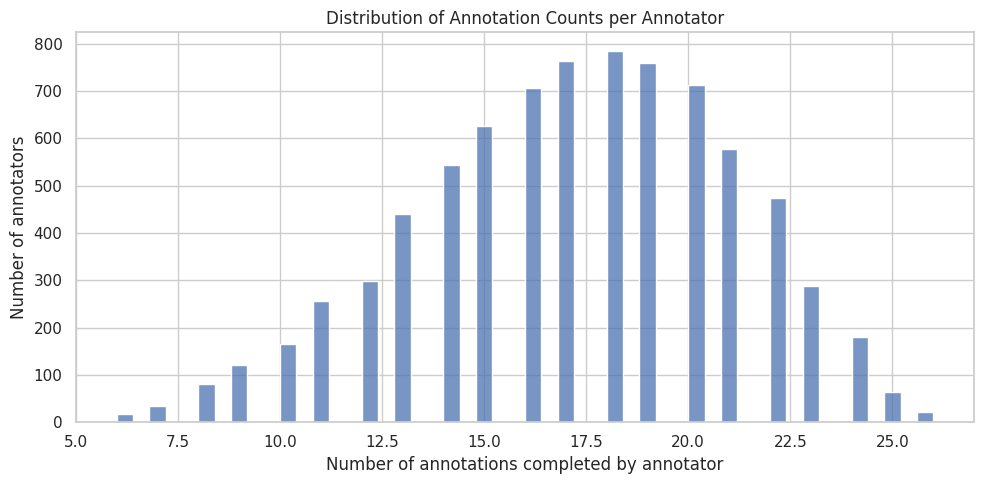

,annotations_per_annotator
count,7912.000000
mean,17.132963
std,3.825483
min,6.000000
25%,15.000000
50%,17.000000
75%,20.000000
90%,22.000000
95%,23.000000
99%,25.000000


In [146]:
annotator_workload = (
    polished_df
    .groupby("annotator_id")
    .agg(
        n_annotations=("text", "size"),
        n_unique_texts=("text", "nunique"),
    )
    .reset_index()
    .sort_values("n_annotations", ascending=False)
)

display(annotator_workload.head(20))

plt.figure(figsize=(10, 5))

sns.histplot(
    annotator_workload["n_annotations"],
    bins=50,
    kde=False
)

plt.title("Distribution of Annotation Counts per Annotator")
plt.xlabel("Number of annotations completed by annotator")
plt.ylabel("Number of annotators")
plt.tight_layout()
plt.show()

display(
    annotator_workload["n_annotations"]
    .describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
    .to_frame("annotations_per_annotator")
)

,annotator_ideology,n_annotation_rows,n_unique_annotators
0,conservative,15628,895
1,extremely_conservative,4544,264
2,extremely_liberal,17944,1065
3,liberal,33812,1968
4,missing,27,2
5,neutral,23112,1367
6,no_opinion,4055,249
7,slightly_conservative,15101,860
8,slightly_liberal,21333,1242


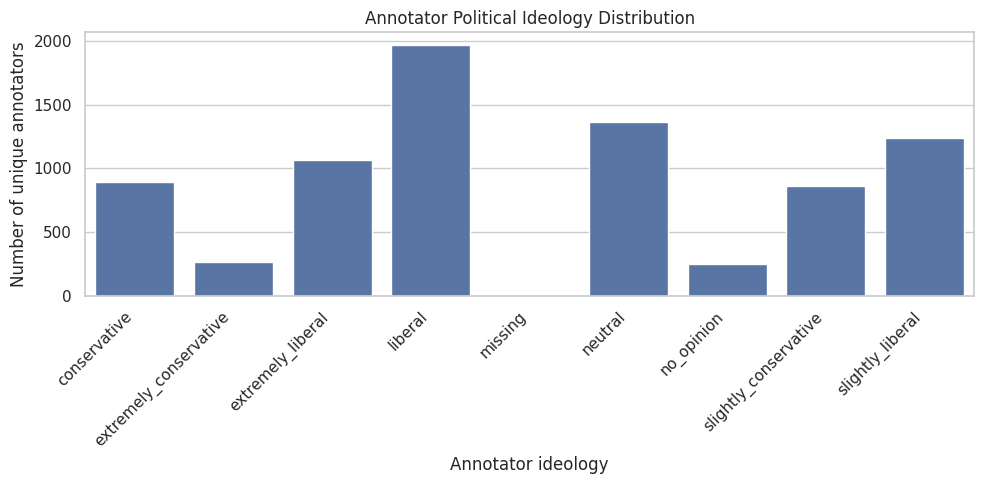

In [147]:
ideology_counts = (
    polished_df["annotator_ideology"]
    .fillna("missing")
    .value_counts()
    .reset_index()
)

ideology_counts.columns = ["annotator_ideology", "n_annotation_rows"]

ideology_annotator_counts = (
    polished_df
    .drop_duplicates("annotator_id")
    ["annotator_ideology"]
    .fillna("missing")
    .value_counts()
    .reset_index()
)

ideology_annotator_counts.columns = ["annotator_ideology", "n_unique_annotators"]

ideology_summary = ideology_counts.merge(
    ideology_annotator_counts,
    on="annotator_ideology",
    how="outer"
).fillna(0)

display(ideology_summary)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=ideology_summary,
    x="annotator_ideology",
    y="n_unique_annotators"
)

plt.title("Annotator Political Ideology Distribution")
plt.xlabel("Annotator ideology")
plt.ylabel("Number of unique annotators")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Detected race/ethnicity columns:
- annotator_race_asian
- annotator_race_black
- annotator_race_latinx
- annotator_race_middle_eastern
- annotator_race_native_american
- annotator_race_pacific_islander
- annotator_race_white
- annotator_race_other


,race_column,n_annotation_rows,n_unique_annotators
6,annotator_race_white,109090,6373
1,annotator_race_black,13606,791
2,annotator_race_latinx,9501,560
0,annotator_race_asian,9596,552
4,annotator_race_native_american,2636,154
7,annotator_race_other,1425,80
3,annotator_race_middle_eastern,827,51
5,annotator_race_pacific_islander,483,28


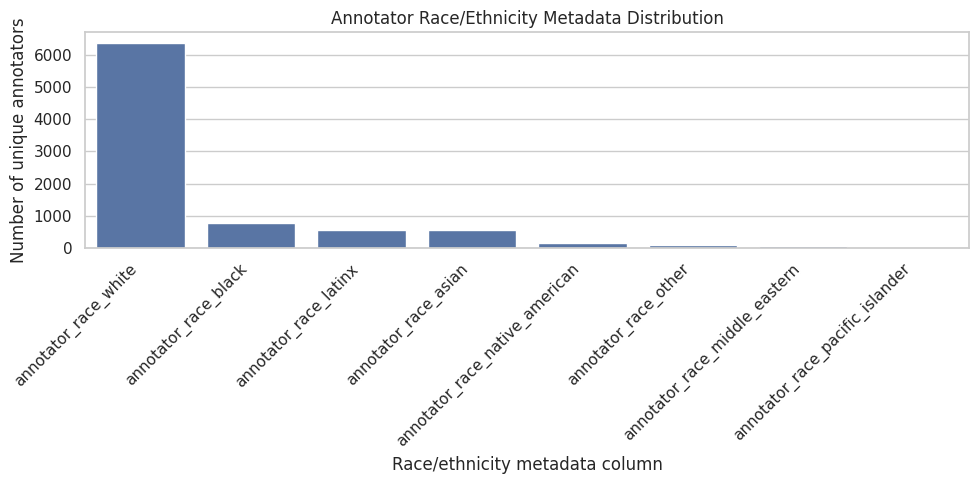

In [148]:
race_columns = [
    col for col in polished_df.columns
    if col.startswith("annotator_race_")
]

print("Detected race/ethnicity columns:")
for col in race_columns:
    print("-", col)

race_summary_rows = []

for col in race_columns:
    n_annotation_rows = polished_df[col].fillna(False).astype(bool).sum()
    
    n_unique_annotators = (
        polished_df[polished_df[col].fillna(False).astype(bool)]
        ["annotator_id"]
        .nunique()
    )
    
    race_summary_rows.append({
        "race_column": col,
        "n_annotation_rows": n_annotation_rows,
        "n_unique_annotators": n_unique_annotators,
    })

race_summary = (
    pd.DataFrame(race_summary_rows)
    .sort_values("n_unique_annotators", ascending=False)
)

display(race_summary)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=race_summary,
    x="race_column",
    y="n_unique_annotators"
)

plt.title("Annotator Race/Ethnicity Metadata Distribution")
plt.xlabel("Race/ethnicity metadata column")
plt.ylabel("Number of unique annotators")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

,annotator_ideology,n_unique_annotators,race_column
0,liberal,177,annotator_race_asian
1,slightly_liberal,111,annotator_race_asian
2,neutral,99,annotator_race_asian
3,extremely_liberal,54,annotator_race_asian
4,slightly_conservative,45,annotator_race_asian
...,...,...,...
51,extremely_liberal,860,annotator_race_white
52,conservative,818,annotator_race_white
53,slightly_conservative,736,annotator_race_white
54,extremely_conservative,242,annotator_race_white


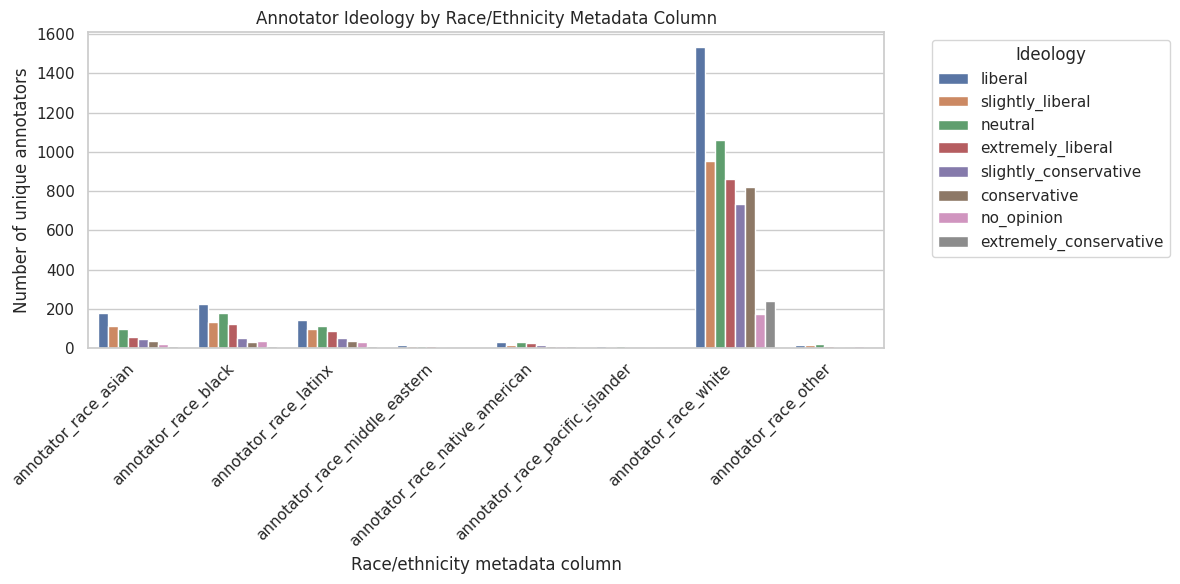

In [149]:
annotator_level = (
    polished_df
    .drop_duplicates("annotator_id")
    .copy()
)

race_ideology_rows = []

for race_col in race_columns:
    temp = annotator_level[annotator_level[race_col].fillna(False).astype(bool)]
    
    counts = (
        temp["annotator_ideology"]
        .fillna("missing")
        .value_counts()
        .reset_index()
    )
    
    counts.columns = ["annotator_ideology", "n_unique_annotators"]
    counts["race_column"] = race_col
    
    race_ideology_rows.append(counts)

race_ideology_summary = pd.concat(race_ideology_rows, ignore_index=True)

display(
    race_ideology_summary
    .sort_values(["race_column", "n_unique_annotators"], ascending=[True, False])
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=race_ideology_summary,
    x="race_column",
    y="n_unique_annotators",
    hue="annotator_ideology"
)

plt.title("Annotator Ideology by Race/Ethnicity Metadata Column")
plt.xlabel("Race/ethnicity metadata column")
plt.ylabel("Number of unique annotators")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Ideology", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Exploratory analysis takeaway

The dataset contains repeated annotations for many sentences, but the number of annotations per sentence varies substantially.

Because this project compares full vote distributions rather than single majority labels, the evaluation must focus on sentences that have enough repeated human annotations in both demographic groups of interest.

The next section defines the two human demographic groups used in the experiment constructs the set of sentences that will be prompted to the LLMs.

In [150]:
print("Observed ideology values:")
display(polished_df["annotator_ideology"].value_counts(dropna=False))

old_liberal_ideologies = ["liberal", "extreme_liberal", "moderate_liberal"]
old_conservative_ideologies = ["conservative", "extreme_conservative", "moderate_conservative"]

new_liberal_ideologies = ["liberal"]
new_conservative_ideologies = ["conservative"]

old_liberal_mask = polished_df["annotator_ideology"].isin(old_liberal_ideologies)
new_liberal_mask = polished_df["annotator_ideology"].isin(new_liberal_ideologies)

old_conservative_mask = polished_df["annotator_ideology"].isin(old_conservative_ideologies)
new_conservative_mask = polished_df["annotator_ideology"].isin(new_conservative_ideologies)

print("Old vs new liberal masks identical:", old_liberal_mask.equals(new_liberal_mask))
print("Old vs new conservative masks identical:", old_conservative_mask.equals(new_conservative_mask))

Observed ideology values:


annotator_ideology
liberal                   33812
neutral                   23112
slightly_liberal          21333
extremely_liberal         17944
conservative              15628
slightly_conservative     15101
extremely_conservative     4544
no_opinion                 4055
NaN                          27
Name: count, dtype: int64

Old vs new liberal masks identical: True
Old vs new conservative masks identical: True


For this experiment, I use the two clearest available ideology labels: `conservative` and `liberal`. This avoids mixing weaker or ambiguous political identities into the two comparison groups.

## Demographic groups for sentence selection

The experiment focuses mainly on White Conservative and Black Liberal annotators.

Before constructing the final test set, we also inspect controversial sentences for four race/ideology combinations:

- White Liberal annotators
- White Conservative annotators
- Black Liberal annotators
- Black Conservative annotators

A sentence is treated as controversial for a group when that group's binary hate-speech vote distribution is sufficiently close to 50/50.


In [151]:
liberal_ideologies = ["liberal"]
conservative_ideologies = ["conservative"]

white_liberal_df = polished_df[
    (polished_df["annotator_race_white"] == True)
    & (polished_df["annotator_ideology"].isin(liberal_ideologies))
].copy()

white_cons_df = polished_df[
    (polished_df["annotator_race_white"] == True)
    & (polished_df["annotator_ideology"].isin(conservative_ideologies))
].copy()

black_libs_df = polished_df[
    (polished_df["annotator_race_black"] == True)
    & (polished_df["annotator_ideology"].isin(liberal_ideologies))
].copy()

black_cons_df = polished_df[
    (polished_df["annotator_race_black"] == True)
    & (polished_df["annotator_ideology"].isin(conservative_ideologies))
].copy()

group_dfs = {
    "white_liberal": white_liberal_df,
    "white_conservative": white_cons_df,
    "black_liberal": black_libs_df,
    "black_conservative": black_cons_df,
}

group_summary = []

for group_name, group_df in group_dfs.items():
    group_summary.append({
        "group": group_name,
        "annotation_rows": len(group_df),
        "unique_annotators": group_df["annotator_id"].nunique(),
        "unique_sentences": group_df["text"].nunique(),
    })

group_summary_df = pd.DataFrame(group_summary)

display(group_summary_df)

,group,annotation_rows,unique_annotators,unique_sentences
0,white_liberal,26275,1532,15015
1,white_conservative,14299,818,9057
2,black_liberal,3884,226,2629
3,black_conservative,546,32,433


In [152]:
def extract_balanced_sentences(
    df_subset,
    group_name,
    min_annotators=5,
    top_n=15,
):
    """
    Extract sentences that are internally controversial for a demographic group.

    A sentence is considered more controversial when its binary hate-speech
    ratio is closer to 0.5.

    This function intentionally uses the same selection principle as the
    original notebook: rank sentences by closeness to 50/50 and keep top_n.
    """

    temp = df_subset.copy()

    if "is_hate_speech_binary" not in temp.columns:
        temp["is_hate_speech_binary"] = (temp["hatespeech"] > 0).astype(int)

    stats = (
        temp
        .groupby("text")
        .agg(
            n_annotators=("annotator_id", "nunique"),
            n_annotation_rows=("annotator_id", "size"),
            hate_speech_ratio=("is_hate_speech_binary", "mean"),
        )
        .reset_index()
    )

    stats = stats[stats["n_annotators"] >= min_annotators].copy()

    stats["distance_from_50_50"] = (stats["hate_speech_ratio"] - 0.5).abs()
    stats["group"] = group_name

    stats = stats.sort_values(
        by=["distance_from_50_50", "n_annotators"],
        ascending=[True, False],
    )

    return stats.head(top_n).reset_index(drop=True)

In [153]:
MIN_ANNOTATORS_PER_GROUP = 5
TOP_N_BALANCED_PER_GROUP = 15

balanced_white_liberal = extract_balanced_sentences(
    white_liberal_df,
    group_name="white_liberal",
    min_annotators=MIN_ANNOTATORS_PER_GROUP,
    top_n=TOP_N_BALANCED_PER_GROUP,
)

balanced_white_conservative = extract_balanced_sentences(
    white_cons_df,
    group_name="white_conservative",
    min_annotators=MIN_ANNOTATORS_PER_GROUP,
    top_n=TOP_N_BALANCED_PER_GROUP,
)

balanced_black_liberal = extract_balanced_sentences(
    black_libs_df,
    group_name="black_liberal",
    min_annotators=MIN_ANNOTATORS_PER_GROUP,
    top_n=TOP_N_BALANCED_PER_GROUP,
)

balanced_black_conservative = extract_balanced_sentences(
    black_cons_df,
    group_name="black_conservative",
    min_annotators=MIN_ANNOTATORS_PER_GROUP,
    top_n=TOP_N_BALANCED_PER_GROUP,
)

print("Most controversial sentences by group:")
print(f"White Liberal:       {len(balanced_white_liberal)}")
print(f"White Conservative:  {len(balanced_white_conservative)}")
print(f"Black Liberal:       {len(balanced_black_liberal)}")
print(f"Black Conservative:  {len(balanced_black_conservative)}")

Most controversial sentences by group:
White Liberal:       15
White Conservative:  15
Black Liberal:       15
Black Conservative:  8


In [154]:
pd.set_option("display.max_colwidth", 220)

display(
    balanced_white_liberal[
        [
            "text",
            "n_annotators",
            "hate_speech_ratio",
            "distance_from_50_50",
        ]
    ]
)

,text,n_annotators,hate_speech_ratio,distance_from_50_50
0,"Aint nobody wearing those new Westbrook ""Jordan's"" but Mexicans & trailer park trash white girls.",71,0.507042,0.007042
1,"RT @JihadistJoe: We Muslims have no military honour whatsoever, we are sub human savages that slaughter unarmed men, women & children http:…",158,0.582278,0.082278
2,"Lady in the back Blinks when ""her"" camera red light goes on. Part of the tranny SHOW. Before ya deny...see: Transvestigations on Yt. Trannies are PROUD to show How It's Done!👍",140,0.600000,0.100000
3,"They all need to be Kicked, taken out of our country. Obama brought them all in Illegally. Send the Trash back to there own country",136,0.632353,0.132353
4,"im ,i hate black people and minorities",74,0.364865,0.135135
5,holy shit i am just getting dunked on by a cripple this is unreal,66,0.666667,0.166667
6,Learn the fucking language you fucking useless immigrant.,79,0.670886,0.170886
7,gay people should die,152,0.671053,0.171053
8,"My God look at these BARBARIC PPL. And these pigs all watching. They r a very, very sick culture. And Omar and Rashid want this crap here. This is America not the Middle East. Round them up and send them home.",154,0.675325,0.175325
9,i hate jews so much i wish the holocaust actually happened,158,0.677215,0.177215


In [155]:
display(
    balanced_white_conservative[
        [
            "text",
            "n_annotators",
            "hate_speech_ratio",
            "distance_from_50_50",
        ]
    ]
)

,text,n_annotators,hate_speech_ratio,distance_from_50_50
0,Who hurt you? Lol. It's comical how stupid and angry you people are. MEH AMURICA. MY LAND. MINE. BANG BANG GUNS. NO BROWN PEOPLE. WAHH.,59,0.508475,0.008475
1,"RT @JihadistJoe: We Muslims have no military honour whatsoever, we are sub human savages that slaughter unarmed men, women & children http:…",86,0.569767,0.069767
2,"im ,i hate black people and minorities",33,0.424242,0.075758
3,"My God look at these BARBARIC PPL. And these pigs all watching. They r a very, very sick culture. And Omar and Rashid want this crap here. This is America not the Middle East. Round them up and send them home.",79,0.582278,0.082278
4,"They all need to be Kicked, taken out of our country. Obama brought them all in Illegally. Send the Trash back to there own country",96,0.604167,0.104167
5,holy shit i am just getting dunked on by a cripple this is unreal,38,0.631579,0.131579
6,"It takes belief in false morality to commit atrocities. Those who believe in the false morality of anti-abortion, anti-gay religions are primed for authoritarianism. They use their beliefs to prop themselves up as su...",38,0.368421,0.131579
7,gay people should die,74,0.635135,0.135135
8,"Aint nobody wearing those new Westbrook ""Jordan's"" but Mexicans & trailer park trash white girls.",44,0.636364,0.136364
9,shut the fuck up you dumb black bitch,45,0.644444,0.144444


In [156]:
display(
    balanced_black_liberal[
        [
            "text",
            "n_annotators",
            "hate_speech_ratio",
            "distance_from_50_50",
        ]
    ]
)

,text,n_annotators,hate_speech_ratio,distance_from_50_50
0,"Lady in the back Blinks when ""her"" camera red light goes on. Part of the tranny SHOW. Before ya deny...see: Transvestigations on Yt. Trannies are PROUD to show How It's Done!👍",30,0.533333,0.033333
1,@blackrepublican how long after the name change will al memorabilia w/redskins name be deemed racist and therby illegal?,11,0.454545,0.045455
2,i hate jews so much i wish the holocaust actually happened,25,0.560000,0.060000
3,gay people should die,21,0.571429,0.071429
4,"Careful what you wish for, you always wanted to feel a huge cock up your hole bitch so now whimper all you like, squeal & cry that ain't gonna stop this bull from raping your boi pussy apart he'll only stop when he i...",12,0.583333,0.083333
5,Who hurt you? Lol. It's comical how stupid and angry you people are. MEH AMURICA. MY LAND. MINE. BANG BANG GUNS. NO BROWN PEOPLE. WAHH.,17,0.411765,0.088235
6,trump is the only jews true friend. I hope trump will be the next US president and help Israel to kill all Palestinian fucking muslim. we will kill all muslim in the world.,17,0.588235,0.088235
7,"Aint nobody wearing those new Westbrook ""Jordan's"" but Mexicans & trailer park trash white girls.",16,0.625000,0.125000
8,"im ,i hate black people and minorities",11,0.363636,0.136364
9,"My God look at these BARBARIC PPL. And these pigs all watching. They r a very, very sick culture. And Omar and Rashid want this crap here. This is America not the Middle East. Round them up and send them home.",23,0.695652,0.195652


In [157]:
display(
    balanced_black_conservative[
        [
            "text",
            "n_annotators",
            "hate_speech_ratio",
            "distance_from_50_50",
        ]
    ]
)

,text,n_annotators,hate_speech_ratio,distance_from_50_50
0,"At 7:19 is why I hate people, women especially look how mad she got just because the dog splashed her.. f*** you you stupid b**** either have fun or go kill yourself",5,0.600000,0.100000
1,"Why did I click on your profile? You gave no source anyway, you just are a hateful human being. Good grief. You have been given sources by others disproving your statements, but no you didn't, once you cited the hate...",10,0.200000,0.300000
2,Keep the fucking Mexican scum rapists and murderers out of the country and the fucking Arab Islamic terrorists out of the U.S. too!! No Syrian refugees either!! Build a wall and keep all of these fucking parasites ou...,5,0.800000,0.300000
3,trump is the only jews true friend. I hope trump will be the next US president and help Israel to kill all Palestinian fucking muslim. we will kill all muslim in the world.,5,0.800000,0.300000
4,"Yes, in barbaric, authoritarian cultures that have since been condemned. Interesting that Christians desire to perpetuate the same idea.",6,0.166667,0.333333
5,"yeah, heres a clue for the nigger author of this article. Chinks hate niggers, Kikes hate niggers, Spicks hate niggers and Towelheads hate niggers. EVen niggers hate niggers. Black Africans hate the gauche lazy Ameri...",6,1.000000,0.500000
6,Every slant in #LosAngeles should be deported. Those scum have no right to be here. Chinatown should be bulldozed.,5,1.000000,0.500000
7,"Hey ,muslim dickhead !!!!!!!! Why don;t you go and shove Allah or whatever the fuck you call the retard up your stupid backwards ass !!!!!!!!! You fucking muslims are a bunch of jealous west hating mongs, Islam is a ...",5,1.000000,0.500000


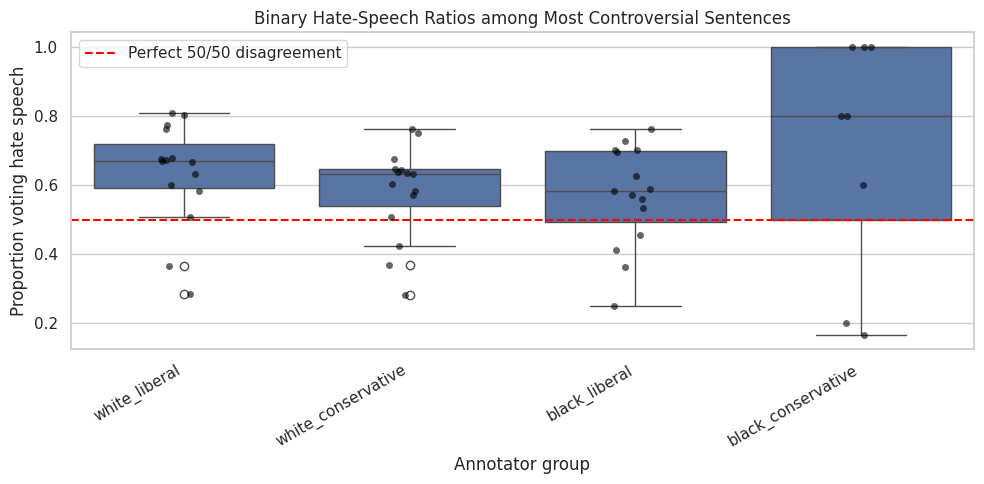

In [158]:
balanced_all_groups = pd.concat(
    [
        balanced_white_liberal,
        balanced_white_conservative,
        balanced_black_liberal,
        balanced_black_conservative,
    ],
    ignore_index=True,
)

plt.figure(figsize=(10, 5))

sns.boxplot(
    data=balanced_all_groups,
    x="group",
    y="hate_speech_ratio",
)

sns.stripplot(
    data=balanced_all_groups,
    x="group",
    y="hate_speech_ratio",
    color="black",
    alpha=0.6,
    jitter=True,
)

plt.axhline(0.5, color="red", linestyle="--", label="Perfect 50/50 disagreement")
plt.title("Binary Hate-Speech Ratios among Most Controversial Sentences")
plt.xlabel("Annotator group")
plt.ylabel("Proportion voting hate speech")
plt.xticks(rotation=30, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

## Construction of evaluation sentence sets

The experiment uses two sentence sets:

1. **Controversial test set**  
   Sentences for which both White Conservative and Black Liberal annotators show substantial internal disagreement.  
   These are the main evaluation items for testing whether LLM-simulated annotators reproduce human disagreement.

2. **Consensus diagnostic set**  
   Sentences for which both White Conservative and Black Liberal annotators show near-consensus.  
   These are used to test whether model sampling temperature introduces artificial disagreement where humans largely agree.

For both sets, labels are binary.

### Controversial sentence selection

For each demographic group, a sentence is considered more controversial when the group's empirical hate-speech vote rate is closer to 0.5.

To ensure that the empirical distribution is meaningful, each sentence must have at least 5 unique annotators from the group.

In [159]:
# The main controversial test set is the overlap between:
# 1. the most internally controversial White Conservative sentences;
# 2. the most internally controversial Black Liberal sentences.

balanced_wc = balanced_white_conservative.copy()
balanced_bl = balanced_black_liberal.copy()

intersection_df = pd.merge(
    balanced_wc,
    balanced_bl,
    on="text",
    how="inner",
    suffixes=("_wc", "_bl"),
)

print(f"Number of WC/BL controversial intersection sentences: {len(intersection_df)}")

display(
    intersection_df[
        [
            "text",
            "n_annotators_wc",
            "hate_speech_ratio_wc",
            "distance_from_50_50_wc",
            "n_annotators_bl",
            "hate_speech_ratio_bl",
            "distance_from_50_50_bl",
        ]
    ]
)

Number of WC/BL controversial intersection sentences: 11


,text,n_annotators_wc,hate_speech_ratio_wc,distance_from_50_50_wc,n_annotators_bl,hate_speech_ratio_bl,distance_from_50_50_bl
0,Who hurt you? Lol. It's comical how stupid and angry you people are. MEH AMURICA. MY LAND. MINE. BANG BANG GUNS. NO BROWN PEOPLE. WAHH.,59,0.508475,0.008475,17,0.411765,0.088235
1,"RT @JihadistJoe: We Muslims have no military honour whatsoever, we are sub human savages that slaughter unarmed men, women & children http:…",86,0.569767,0.069767,21,0.761905,0.261905
2,"im ,i hate black people and minorities",33,0.424242,0.075758,11,0.363636,0.136364
3,"My God look at these BARBARIC PPL. And these pigs all watching. They r a very, very sick culture. And Omar and Rashid want this crap here. This is America not the Middle East. Round them up and send them home.",79,0.582278,0.082278,23,0.695652,0.195652
4,holy shit i am just getting dunked on by a cripple this is unreal,38,0.631579,0.131579,10,0.700000,0.200000
5,"It takes belief in false morality to commit atrocities. Those who believe in the false morality of anti-abortion, anti-gay religions are primed for authoritarianism. They use their beliefs to prop themselves up as su...",38,0.368421,0.131579,8,0.250000,0.250000
6,gay people should die,74,0.635135,0.135135,21,0.571429,0.071429
7,"Aint nobody wearing those new Westbrook ""Jordan's"" but Mexicans & trailer park trash white girls.",44,0.636364,0.136364,16,0.625000,0.125000
8,i hate jews so much i wish the holocaust actually happened,79,0.645570,0.145570,25,0.560000,0.060000
9,Learn the fucking language you fucking useless immigrant.,37,0.675676,0.175676,10,0.700000,0.200000


In [160]:
intersectional_test_sentences_whicon_blalib = intersection_df[["text"]].copy()

# Standardize whitespace before saving.
# This avoids line breaks and tabs inside the prompt CSV while preserving the sentence content.
intersectional_test_sentences_whicon_blalib["text"] = (
    intersectional_test_sentences_whicon_blalib["text"]
    .str.replace(r"\r", " ", regex=True)
    .str.replace(r"\n", " ", regex=True)
    .str.replace(r"\t", " ", regex=True)
)

TEST_SENTENCE_PATH = DATA_DIR / "intersectional_test_sentences_whicon_blalib.csv"

intersectional_test_sentences_whicon_blalib.to_csv(
    TEST_SENTENCE_PATH,
    index=False,
    quoting=csv.QUOTE_ALL,
)

print(f"Saved controversial test set to: {TEST_SENTENCE_PATH}")
print(f"Number of saved sentences: {len(intersectional_test_sentences_whicon_blalib)}")

display(intersectional_test_sentences_whicon_blalib)

Saved controversial test set to: data/intersectional_test_sentences_whicon_blalib.csv
Number of saved sentences: 11


,text
0,Who hurt you? Lol. It's comical how stupid and angry you people are. MEH AMURICA. MY LAND. MINE. BANG BANG GUNS. NO BROWN PEOPLE. WAHH.
1,"RT @JihadistJoe: We Muslims have no military honour whatsoever, we are sub human savages that slaughter unarmed men, women & children http:…"
2,"im ,i hate black people and minorities"
3,"My God look at these BARBARIC PPL. And these pigs all watching. They r a very, very sick culture. And Omar and Rashid want this crap here. This is America not the Middle East. Round them up and send them home."
4,holy shit i am just getting dunked on by a cripple this is unreal
5,"It takes belief in false morality to commit atrocities. Those who believe in the false morality of anti-abortion, anti-gay religions are primed for authoritarianism. They use their beliefs to prop themselves up as su..."
6,gay people should die
7,"Aint nobody wearing those new Westbrook ""Jordan's"" but Mexicans & trailer park trash white girls."
8,i hate jews so much i wish the holocaust actually happened
9,Learn the fucking language you fucking useless immigrant.


### Consensus diagnostic sentence selection

The consensus diagnostic set is used to test whether model sampling temperature creates artificial disagreement.

A sentence is selected for the consensus diagnostic set when both demographic groups are close to consensus.

Each sentence must again have at least 5 unique annotators from the group.

The final consensus diagnostic set is constructed by intersecting near-consensus sentences for White Conservative and Black Liberal annotators, then taking the first 20 shared sentences. This keeps the diagnostic set small enough for repeated LLM evaluation.

In [161]:
def get_consensus_sentences(df_subset, min_annotators=5):
    """
    Extract near-consensus sentences for one demographic group.

    A sentence is retained if:
    - it has at least `min_annotators` unique annotators from the group;
    - its binary hate-speech rate is <= 0.10 or >= 0.90.

    This function preserves the original row order produced by groupby/reset_index,
    because the final consensus control set uses the first 20 overlapping rows.
    """

    temp = df_subset.copy()

    if "is_hate_speech_binary" not in temp.columns:
        temp["is_hate_speech_binary"] = (temp["hatespeech"] > 0).astype(int)

    group_cols = ["text_id", "text"] if "text_id" in temp.columns else ["text"]

    stats = (
        temp
        .groupby(group_cols)
        .agg(
            total_annotators=("annotator_id", "nunique"),
            hate_speech_ratio=("is_hate_speech_binary", "mean"),
        )
        .reset_index()
    )

    robust = stats[stats["total_annotators"] >= min_annotators].copy()

    consensus = robust[
        (robust["hate_speech_ratio"] <= 0.10)
        | (robust["hate_speech_ratio"] >= 0.90)
    ].copy()

    return consensus

In [162]:
MIN_ANNOTATORS_CONSENSUS = 5

consensus_wc = get_consensus_sentences(
    white_cons_df,
    min_annotators=MIN_ANNOTATORS_CONSENSUS,
)

consensus_bl = get_consensus_sentences(
    black_libs_df,
    min_annotators=MIN_ANNOTATORS_CONSENSUS,
)

print(f"White Conservative near-consensus sentences: {len(consensus_wc)}")
print(f"Black Liberal near-consensus sentences:      {len(consensus_bl)}")

merge_cols = ["text_id", "text"] if "text_id" in consensus_wc.columns else ["text"]

universal_consensus = pd.merge(
    consensus_wc,
    consensus_bl,
    on=merge_cols,
    suffixes=("_white_cons", "_black_libs"),
    how="inner",
)

print(f"WC/BL shared near-consensus sentences: {len(universal_consensus)}")

if universal_consensus.empty:
    print("No shared consensus sentences found.")
else:
    view_cols = [
        "text",
        "hate_speech_ratio_white_cons",
        "hate_speech_ratio_black_libs",
    ]

    with pd.option_context("display.max_colwidth", 220):
        display(universal_consensus[view_cols].head(10))

White Conservative near-consensus sentences: 39
Black Liberal near-consensus sentences:      43
WC/BL shared near-consensus sentences: 33


,text,hate_speech_ratio_white_cons,hate_speech_ratio_black_libs
0,"""@iamkrause: No need to thank me, killing niggers is it's own reward."" Dis my pal from our graduation when we was 26",0.965909,1.000000
1,#whitepower...I'll hang you nigger,0.972222,1.000000
2,31 Black Women Who Died In Police Custody URL,0.000000,0.043478
3,@L1LTR4P fucking losers wetbacks #SorryNotSorry,1.000000,1.000000
4,@Legionary1488 @JomavaesJos now we have a Ebloa case in Texas. If we kill all the niggers we might be safe.,1.000000,1.000000
5,Every gook in #LosAngeles should be deported or killed.,0.986842,1.000000
6,Every slant in #LosAngeles should be deported. Those scum have no right to be here. Chinatown should be bulldozed.,0.945946,0.950000
7,Fuck you fuck you you stupid cheating bitch go lick a dick and die ur a stupid nigger bitch,0.967742,0.960000
8,Fucking fagot burn in hell,0.947368,1.000000
9,"Hey ,muslim dickhead !!!!!!!! Why don;t you go and shove Allah or whatever the fuck you call the retard up your stupid backwards ass !!!!!!!!! You fucking muslims are a bunch of jealous west hating mongs, Islam is a ...",0.972973,0.944444


In [163]:
if universal_consensus.empty:
    raise ValueError("Cannot save consensus diagnostic set because universal_consensus is empty.")

# Standardize whitespace before saving.
universal_consensus["text"] = (
    universal_consensus["text"]
    .str.replace(r"[\r\n\t]", " ", regex=True)
)

# The consensus diagnostic set uses the first 20 shared near-consensus sentences.
intersectional_consensus_sentences = (
    universal_consensus
    .head(20)[["text"]]
    .copy()
)

CONSENSUS_SENTENCE_PATH = DATA_DIR / "intersectional_consensus_sentences.csv"

intersectional_consensus_sentences.to_csv(
    CONSENSUS_SENTENCE_PATH,
    index=False,
    quoting=csv.QUOTE_ALL,
)

print(f"Saved consensus diagnostic set to: {CONSENSUS_SENTENCE_PATH}")
print(f"Number of saved consensus sentences: {len(intersectional_consensus_sentences)}")

display(intersectional_consensus_sentences)

Saved consensus diagnostic set to: data/intersectional_consensus_sentences.csv
Number of saved consensus sentences: 20


,text
0,"""@iamkrause: No need to thank me, killing niggers is it's own reward."" Dis my pal from our graduation when we was 26"
1,#whitepower...I'll hang you nigger
2,31 Black Women Who Died In Police Custody URL
3,@L1LTR4P fucking losers wetbacks #SorryNotSorry
4,@Legionary1488 @JomavaesJos now we have a Ebloa case in Texas. If we kill all the niggers we might be safe.
5,Every gook in #LosAngeles should be deported or killed.
6,Every slant in #LosAngeles should be deported. Those scum have no right to be here. Chinatown should be bulldozed.
7,Fuck you fuck you you stupid cheating bitch go lick a dick and die ur a stupid nigger bitch
8,Fucking fagot burn in hell
9,"Hey ,muslim dickhead !!!!!!!! Why don;t you go and shove Allah or whatever the fuck you call the retard up your stupid backwards ass !!!!!!!!! You fucking muslims are a bunch of jealous west hating mongs, Islam is a ..."


# LLM output analysis

This section evaluates the LLM-generated binary annotations against the human annotation distributions.

Each LLM output CSV contains repeated votes for each sentence. For each unique sentence, the 50 repeated votes are converted into a binary distribution:

- proportion voting 0: Not Hate Speech
- proportion voting 1: Hate Speech

The same binary distribution is computed from the human annotations for the matching sentence and demographic group.

The main metrics are:

- Fidelity Error WC: JSD between LLM White Conservative votes and human White Conservative votes.
- Fidelity Error BL: JSD between LLM Black Liberal votes and human Black Liberal votes.
- LLM Polarization: JSD between LLM White Conservative votes and LLM Black Liberal votes.
- Human Polarization: JSD between human White Conservative votes and human Black Liberal votes.
- Amplification: LLM Polarization minus Human Polarization.

All Jensen-Shannon Divergence values are computed in bits. Lower fidelity error means the LLM distribution is closer to the corresponding human distribution.

## Baseline instruct model: no Chain-of-Persona prompting

The first analysis evaluates the baseline instruct model on the controversial sentence set.

In these runs, the model is prompted directly with the demographic persona, without first generating a panel of sub-personas.

Two prompt variants are compared:

1. Aggressive system prompt: stored in `./binary_data4`
2. Sandwiched persona prompt: stored in `./binary_data2`

For each model temperature, the notebook computes distributional fidelity and polarization metrics.

In [164]:
JSD_YLIM = (-0.05, 0.45)

def get_binary_dist_from_votes(votes_series):
    """
    Convert a series of LLM or human votes into a binary probability distribution.

    Valid labels are:
    - 0: Not Hate Speech
    - 1: Hate Speech

    Any non-numeric value, missing value, or value outside {0, 1} is counted as invalid
    and excluded from the empirical distribution.
    """

    raw = pd.to_numeric(votes_series, errors="coerce")
    n_total = len(votes_series)

    valid = raw.dropna()
    valid = valid[valid.isin([0, 1])]

    n_valid = len(valid)
    n_invalid = n_total - n_valid

    if n_valid == 0:
        return None, {
            "n_total": n_total,
            "n_valid": 0,
            "n_invalid": n_invalid,
            "invalid_rate": 1.0 if n_total > 0 else np.nan,
        }

    counts = valid.value_counts(normalize=True)

    dist = [
        counts.get(0, 0.0),
        counts.get(1, 0.0),
    ]

    return dist, {
        "n_total": n_total,
        "n_valid": n_valid,
        "n_invalid": n_invalid,
        "invalid_rate": n_invalid / n_total if n_total > 0 else np.nan,
    }


def calculate_true_jsd(p, q):
    """
    Compute Jensen-Shannon Divergence in bits.

    scipy.spatial.distance.jensenshannon returns Jensen-Shannon distance,
    so we square it to obtain Jensen-Shannon Divergence.
    """

    if p is None or q is None:
        return np.nan

    p = np.asarray(p, dtype=np.float64)
    q = np.asarray(q, dtype=np.float64)

    if p.sum() == 0 or q.sum() == 0:
        return np.nan

    p = p / p.sum()
    q = q / q.sum()

    return jensenshannon(p, q, base=2) ** 2

In [165]:
def add_sanitized_text_column(df_in, source_col="text", target_col="text_sanitized"):
    """
    Add a sanitized text column matching the prompt CSV formatting.
    """

    df_out = df_in.copy()

    df_out[target_col] = (
        df_out[source_col]
        .astype(str)
        .str.replace(r"[\r\n\t]", " ", regex=True)
    )

    return df_out


def analyze_binary_llm_file(
    df_llm,
    df_human_wc,
    df_human_bl,
    expected_votes_per_sentence=50,
):
    """
    Analyze one LLM output CSV.

    The CSV is expected to contain:
    - text
    - whicon_vote
    - blalib_vote

    The function returns:
    - summary metrics averaged across sentences
    - per-sentence detail dataframe
    """

    required_llm_cols = ["text", "whicon_vote", "blalib_vote"]
    missing_cols = [col for col in required_llm_cols if col not in df_llm.columns]

    if missing_cols:
        raise ValueError(f"LLM dataframe is missing required columns: {missing_cols}")

    df_llm = add_sanitized_text_column(df_llm, source_col="text", target_col="text_sanitized")
    df_human_wc = add_sanitized_text_column(df_human_wc, source_col="text", target_col="text_sanitized")
    df_human_bl = add_sanitized_text_column(df_human_bl, source_col="text", target_col="text_sanitized")

    if "is_hate_speech_binary" not in df_human_wc.columns:
        df_human_wc["is_hate_speech_binary"] = (df_human_wc["hatespeech"] > 0).astype(int)

    if "is_hate_speech_binary" not in df_human_bl.columns:
        df_human_bl["is_hate_speech_binary"] = (df_human_bl["hatespeech"] > 0).astype(int)

    rows = []

    for sentence in df_llm["text_sanitized"].dropna().unique():
        llm_subset = df_llm[df_llm["text_sanitized"] == sentence]
        hum_wc_subset = df_human_wc[df_human_wc["text_sanitized"] == sentence]
        hum_bl_subset = df_human_bl[df_human_bl["text_sanitized"] == sentence]

        llm_wc, llm_wc_meta = get_binary_dist_from_votes(llm_subset["whicon_vote"])
        llm_bl, llm_bl_meta = get_binary_dist_from_votes(llm_subset["blalib_vote"])
        hum_wc, hum_wc_meta = get_binary_dist_from_votes(hum_wc_subset["is_hate_speech_binary"])
        hum_bl, hum_bl_meta = get_binary_dist_from_votes(hum_bl_subset["is_hate_speech_binary"])

        fid_wc = calculate_true_jsd(llm_wc, hum_wc)
        fid_bl = calculate_true_jsd(llm_bl, hum_bl)
        pol_llm = calculate_true_jsd(llm_wc, llm_bl)
        pol_hum = calculate_true_jsd(hum_wc, hum_bl)

        rows.append({
            "text": sentence,

            "llm_wc_dist": llm_wc,
            "llm_bl_dist": llm_bl,
            "human_wc_dist": hum_wc,
            "human_bl_dist": hum_bl,

            "n_llm_wc_total": llm_wc_meta["n_total"],
            "n_llm_wc_valid": llm_wc_meta["n_valid"],
            "n_llm_wc_invalid": llm_wc_meta["n_invalid"],
            "llm_wc_invalid_rate": llm_wc_meta["invalid_rate"],

            "n_llm_bl_total": llm_bl_meta["n_total"],
            "n_llm_bl_valid": llm_bl_meta["n_valid"],
            "n_llm_bl_invalid": llm_bl_meta["n_invalid"],
            "llm_bl_invalid_rate": llm_bl_meta["invalid_rate"],

            "n_human_wc": hum_wc_meta["n_valid"],
            "n_human_bl": hum_bl_meta["n_valid"],

            "expected_votes_per_sentence": expected_votes_per_sentence,
            "wc_vote_count_matches_expected": llm_wc_meta["n_total"] == expected_votes_per_sentence,
            "bl_vote_count_matches_expected": llm_bl_meta["n_total"] == expected_votes_per_sentence,

            "fid_wc": fid_wc,
            "fid_bl": fid_bl,
            "pol_llm": pol_llm,
            "pol_hum": pol_hum,
            "amplification": (
                pol_llm - pol_hum
                if not np.isnan(pol_llm) and not np.isnan(pol_hum)
                else np.nan
            ),
        })

    detail_df = pd.DataFrame(rows)

    metric_cols = [
        "fid_wc",
        "fid_bl",
        "pol_llm",
        "pol_hum",
        "amplification",
    ]

    summary = detail_df[metric_cols].mean(skipna=True).to_dict()

    summary.update({
        "n_sentences": len(detail_df),
        "n_valid_fid_wc": detail_df["fid_wc"].notna().sum(),
        "n_valid_fid_bl": detail_df["fid_bl"].notna().sum(),
        "n_valid_pol_llm": detail_df["pol_llm"].notna().sum(),
        "n_valid_pol_hum": detail_df["pol_hum"].notna().sum(),

        "total_invalid_wc_votes": detail_df["n_llm_wc_invalid"].sum(),
        "total_invalid_bl_votes": detail_df["n_llm_bl_invalid"].sum(),
        "total_invalid_votes": (
            detail_df["n_llm_wc_invalid"].sum()
            + detail_df["n_llm_bl_invalid"].sum()
        ),

        "mean_wc_invalid_rate": detail_df["llm_wc_invalid_rate"].mean(),
        "mean_bl_invalid_rate": detail_df["llm_bl_invalid_rate"].mean(),

        "min_llm_wc_votes_per_sentence": detail_df["n_llm_wc_total"].min(),
        "max_llm_wc_votes_per_sentence": detail_df["n_llm_wc_total"].max(),
        "min_llm_bl_votes_per_sentence": detail_df["n_llm_bl_total"].min(),
        "max_llm_bl_votes_per_sentence": detail_df["n_llm_bl_total"].max(),

        "all_wc_vote_counts_match_expected": detail_df["wc_vote_count_matches_expected"].all(),
        "all_bl_vote_counts_match_expected": detail_df["bl_vote_count_matches_expected"].all(),

        "mean_n_human_wc": detail_df["n_human_wc"].mean(),
        "mean_n_human_bl": detail_df["n_human_bl"].mean(),
        "min_n_human_wc": detail_df["n_human_wc"].min(),
        "min_n_human_bl": detail_df["n_human_bl"].min(),
    })

    return summary, detail_df

In [166]:
def process_instruct_baseline_folder(
    folder_path,
    filename_template,
    prompt_variant_label,
    temperatures=TEMPS,
):
    """
    Process baseline/no-CoP runs for one prompt variant.

    filename_template should contain '{temp}'.
    """

    folder_path = Path(folder_path)
    summaries = []
    details_by_temp = {}
    missing_files = []

    print(f"Processing baseline runs: {prompt_variant_label}")
    print(f"Folder: {folder_path}")

    for temp in temperatures:
        file_path = folder_path / filename_template.format(temp=temp)

        if not file_path.exists():
            missing_files.append(file_path.name)
            continue

        df_llm = pd.read_csv(file_path)

        summary, detail_df = analyze_binary_llm_file(
            df_llm=df_llm,
            df_human_wc=white_cons_df,
            df_human_bl=black_libs_df,
            expected_votes_per_sentence=EXPECTED_N_LLM_VOTES,
        )

        summary.update({
            "prompt_variant": prompt_variant_label,
            "temperature": temp,
            "file_path": str(file_path),
        })

        summaries.append(summary)
        details_by_temp[temp] = detail_df

    if missing_files:
        print(f"Missing files: {len(missing_files)} out of {len(temperatures)} expected files.")
        print("First missing examples:")
        for filename in missing_files[:5]:
            print("-", filename)

    if len(summaries) == 0:
        print(f"No matching files found for: {prompt_variant_label}")
        return pd.DataFrame(), details_by_temp

    summary_df = (
        pd.DataFrame(summaries)
        .sort_values("temperature")
        .reset_index(drop=True)
    )

    print(f"Successfully processed {len(summary_df)} files.")

    return summary_df, details_by_temp


aggressive_baseline_summary, aggressive_baseline_details = process_instruct_baseline_folder(
    folder_path="./binary_data4",
    filename_template="llama3_binary_baseline_aggressive_T{temp}_N50.csv",
    prompt_variant_label="Aggressive system prompt",
)

sandwiched_baseline_summary, sandwiched_baseline_details = process_instruct_baseline_folder(
    folder_path="./binary_data2",
    filename_template="llama3_binary_baseline_sandwiched_T{temp}_N50.csv",
    prompt_variant_label="Sandwiched persona prompt",
)

baseline_parts = [
    df_part
    for df_part in [aggressive_baseline_summary, sandwiched_baseline_summary]
    if not df_part.empty
]

if baseline_parts:
    baseline_instruct_summary = pd.concat(
        baseline_parts,
        ignore_index=True,
    )
else:
    baseline_instruct_summary = pd.DataFrame()

display(baseline_instruct_summary)

Processing baseline runs: Aggressive system prompt
Folder: binary_data4


Successfully processed 21 files.
Processing baseline runs: Sandwiched persona prompt
Folder: binary_data2
Missing files: 21 out of 21 expected files.
First missing examples:
- llama3_binary_baseline_sandwiched_T0.0_N50.csv
- llama3_binary_baseline_sandwiched_T0.1_N50.csv
- llama3_binary_baseline_sandwiched_T0.2_N50.csv
- llama3_binary_baseline_sandwiched_T0.3_N50.csv
- llama3_binary_baseline_sandwiched_T0.4_N50.csv
No matching files found for: Sandwiched persona prompt


,fid_wc,fid_bl,pol_llm,pol_hum,amplification,n_sentences,n_valid_fid_wc,n_valid_fid_bl,n_valid_pol_llm,n_valid_pol_hum,...,max_llm_bl_votes_per_sentence,all_wc_vote_counts_match_expected,all_bl_vote_counts_match_expected,mean_n_human_wc,mean_n_human_bl,min_n_human_wc,min_n_human_bl,prompt_variant,temperature,file_path
0,0.267444,0.238232,0.000000,0.011169,-0.011169,11,11,11,11,11,...,50,True,True,57.363636,17.454545,33,8,Aggressive system prompt,0.0,binary_data4/llama3_binary_baseline_aggressive_T0.0_N50.csv
1,0.267444,0.238232,0.000000,0.011169,-0.011169,11,11,11,11,11,...,50,True,True,57.363636,17.454545,33,8,Aggressive system prompt,0.1,binary_data4/llama3_binary_baseline_aggressive_T0.1_N50.csv
2,0.267444,0.238232,0.000000,0.011169,-0.011169,11,11,11,11,11,...,50,True,True,57.363636,17.454545,33,8,Aggressive system prompt,0.2,binary_data4/llama3_binary_baseline_aggressive_T0.2_N50.csv
3,0.234507,0.238232,0.016600,0.011169,0.005431,11,11,11,11,11,...,50,True,True,57.363636,17.454545,33,8,Aggressive system prompt,0.3,binary_data4/llama3_binary_baseline_aggressive_T0.3_N50.csv
4,0.227169,0.238232,0.030961,0.011169,0.019793,11,11,11,11,11,...,50,True,True,57.363636,17.454545,33,8,Aggressive system prompt,0.4,binary_data4/llama3_binary_baseline_aggressive_T0.4_N50.csv
5,0.227347,0.238232,0.034782,0.011169,0.023613,11,11,11,11,11,...,50,True,True,57.363636,17.454545,33,8,Aggressive system prompt,0.5,binary_data4/llama3_binary_baseline_aggressive_T0.5_N50.csv
6,0.225497,0.238232,0.033113,0.011169,0.021944,11,11,11,11,11,...,50,True,True,57.363636,17.454545,33,8,Aggressive system prompt,0.6,binary_data4/llama3_binary_baseline_aggressive_T0.6_N50.csv
7,0.212770,0.227104,0.027076,0.011169,0.015907,11,11,11,11,11,...,50,True,True,57.363636,17.454545,33,8,Aggressive system prompt,0.7,binary_data4/llama3_binary_baseline_aggressive_T0.7_N50.csv
8,0.200933,0.223151,0.034101,0.011169,0.022932,11,11,11,11,11,...,50,True,True,57.363636,17.454545,33,8,Aggressive system prompt,0.8,binary_data4/llama3_binary_baseline_aggressive_T0.8_N50.csv
9,0.190738,0.225342,0.039099,0.011169,0.027930,11,11,11,11,11,...,50,True,True,57.363636,17.454545,33,8,Aggressive system prompt,0.9,binary_data4/llama3_binary_baseline_aggressive_T0.9_N50.csv


In [167]:
aggressive_baseline_summary, aggressive_baseline_details = process_instruct_baseline_folder(
    folder_path="./binary_data4",
    filename_template="llama3_binary_baseline_aggressive_T{temp}_N50.csv",
    prompt_variant_label="Aggressive system prompt",
)

sandwiched_baseline_summary, sandwiched_baseline_details = process_instruct_baseline_folder(
    folder_path="./binary_data2",
    filename_template="llama3_binary_baseline_T{temp}_N50.csv",
    prompt_variant_label="Standard persona prompt",
)

baseline_parts = [
    df_part
    for df_part in [aggressive_baseline_summary, sandwiched_baseline_summary]
    if not df_part.empty
]

if baseline_parts:
    baseline_instruct_summary = pd.concat(
        baseline_parts,
        ignore_index=True,
    )
else:
    baseline_instruct_summary = pd.DataFrame()

display(baseline_instruct_summary)

Processing baseline runs: Aggressive system prompt
Folder: binary_data4
Successfully processed 21 files.
Processing baseline runs: Standard persona prompt
Folder: binary_data2
Successfully processed 21 files.


,fid_wc,fid_bl,pol_llm,pol_hum,amplification,n_sentences,n_valid_fid_wc,n_valid_fid_bl,n_valid_pol_llm,n_valid_pol_hum,...,max_llm_bl_votes_per_sentence,all_wc_vote_counts_match_expected,all_bl_vote_counts_match_expected,mean_n_human_wc,mean_n_human_bl,min_n_human_wc,min_n_human_bl,prompt_variant,temperature,file_path
0,0.267444,0.238232,0.000000,0.011169,-0.011169,11,11,11,11,11,...,50,True,True,57.363636,17.454545,33,8,Aggressive system prompt,0.0,binary_data4/llama3_binary_baseline_aggressive_T0.0_N50.csv
1,0.267444,0.238232,0.000000,0.011169,-0.011169,11,11,11,11,11,...,50,True,True,57.363636,17.454545,33,8,Aggressive system prompt,0.1,binary_data4/llama3_binary_baseline_aggressive_T0.1_N50.csv
2,0.267444,0.238232,0.000000,0.011169,-0.011169,11,11,11,11,11,...,50,True,True,57.363636,17.454545,33,8,Aggressive system prompt,0.2,binary_data4/llama3_binary_baseline_aggressive_T0.2_N50.csv
3,0.234507,0.238232,0.016600,0.011169,0.005431,11,11,11,11,11,...,50,True,True,57.363636,17.454545,33,8,Aggressive system prompt,0.3,binary_data4/llama3_binary_baseline_aggressive_T0.3_N50.csv
4,0.227169,0.238232,0.030961,0.011169,0.019793,11,11,11,11,11,...,50,True,True,57.363636,17.454545,33,8,Aggressive system prompt,0.4,binary_data4/llama3_binary_baseline_aggressive_T0.4_N50.csv
5,0.227347,0.238232,0.034782,0.011169,0.023613,11,11,11,11,11,...,50,True,True,57.363636,17.454545,33,8,Aggressive system prompt,0.5,binary_data4/llama3_binary_baseline_aggressive_T0.5_N50.csv
6,0.225497,0.238232,0.033113,0.011169,0.021944,11,11,11,11,11,...,50,True,True,57.363636,17.454545,33,8,Aggressive system prompt,0.6,binary_data4/llama3_binary_baseline_aggressive_T0.6_N50.csv
7,0.212770,0.227104,0.027076,0.011169,0.015907,11,11,11,11,11,...,50,True,True,57.363636,17.454545,33,8,Aggressive system prompt,0.7,binary_data4/llama3_binary_baseline_aggressive_T0.7_N50.csv
8,0.200933,0.223151,0.034101,0.011169,0.022932,11,11,11,11,11,...,50,True,True,57.363636,17.454545,33,8,Aggressive system prompt,0.8,binary_data4/llama3_binary_baseline_aggressive_T0.8_N50.csv
9,0.190738,0.225342,0.039099,0.011169,0.027930,11,11,11,11,11,...,50,True,True,57.363636,17.454545,33,8,Aggressive system prompt,0.9,binary_data4/llama3_binary_baseline_aggressive_T0.9_N50.csv


In [168]:
invalid_vote_audit_cols = [
    "prompt_variant",
    "temperature",
    "n_sentences",
    "total_invalid_wc_votes",
    "total_invalid_bl_votes",
    "total_invalid_votes",
    "mean_wc_invalid_rate",
    "mean_bl_invalid_rate",
    "all_wc_vote_counts_match_expected",
    "all_bl_vote_counts_match_expected",
    "min_llm_wc_votes_per_sentence",
    "max_llm_wc_votes_per_sentence",
    "min_llm_bl_votes_per_sentence",
    "max_llm_bl_votes_per_sentence",
]

invalid_vote_audit = baseline_instruct_summary[invalid_vote_audit_cols].copy()

display(invalid_vote_audit)

print("Total invalid votes across all baseline instruct runs:")
display(
    invalid_vote_audit
    .groupby("prompt_variant")[["total_invalid_wc_votes", "total_invalid_bl_votes", "total_invalid_votes"]]
    .sum()
)

,prompt_variant,temperature,n_sentences,total_invalid_wc_votes,total_invalid_bl_votes,total_invalid_votes,mean_wc_invalid_rate,mean_bl_invalid_rate,all_wc_vote_counts_match_expected,all_bl_vote_counts_match_expected,min_llm_wc_votes_per_sentence,max_llm_wc_votes_per_sentence,min_llm_bl_votes_per_sentence,max_llm_bl_votes_per_sentence
0,Aggressive system prompt,0.0,11,0,0,0,0.0,0.0,True,True,50,50,50,50
1,Aggressive system prompt,0.1,11,0,0,0,0.0,0.0,True,True,50,50,50,50
2,Aggressive system prompt,0.2,11,0,0,0,0.0,0.0,True,True,50,50,50,50
3,Aggressive system prompt,0.3,11,0,0,0,0.0,0.0,True,True,50,50,50,50
4,Aggressive system prompt,0.4,11,0,0,0,0.0,0.0,True,True,50,50,50,50
5,Aggressive system prompt,0.5,11,0,0,0,0.0,0.0,True,True,50,50,50,50
6,Aggressive system prompt,0.6,11,0,0,0,0.0,0.0,True,True,50,50,50,50
7,Aggressive system prompt,0.7,11,0,0,0,0.0,0.0,True,True,50,50,50,50
8,Aggressive system prompt,0.8,11,0,0,0,0.0,0.0,True,True,50,50,50,50
9,Aggressive system prompt,0.9,11,0,0,0,0.0,0.0,True,True,50,50,50,50


Total invalid votes across all baseline instruct runs:


,total_invalid_wc_votes,total_invalid_bl_votes,total_invalid_votes
prompt_variant,,,
Aggressive system prompt,0,0,0
Standard persona prompt,0,0,0


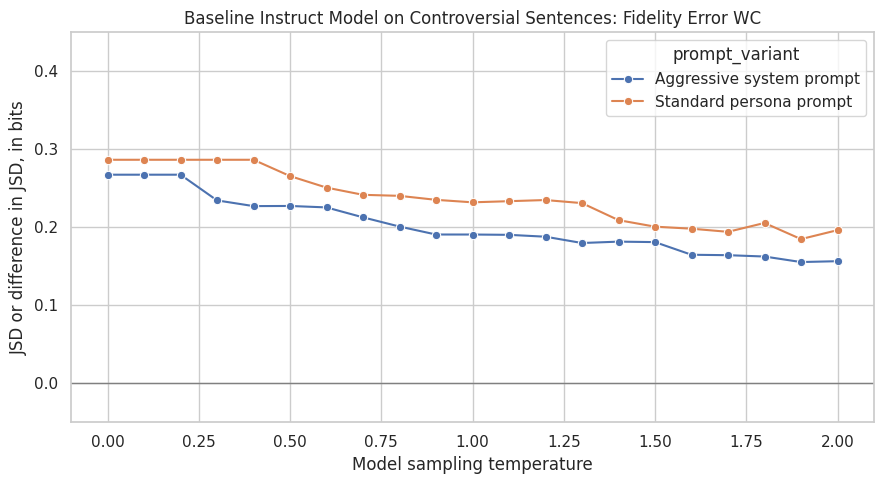

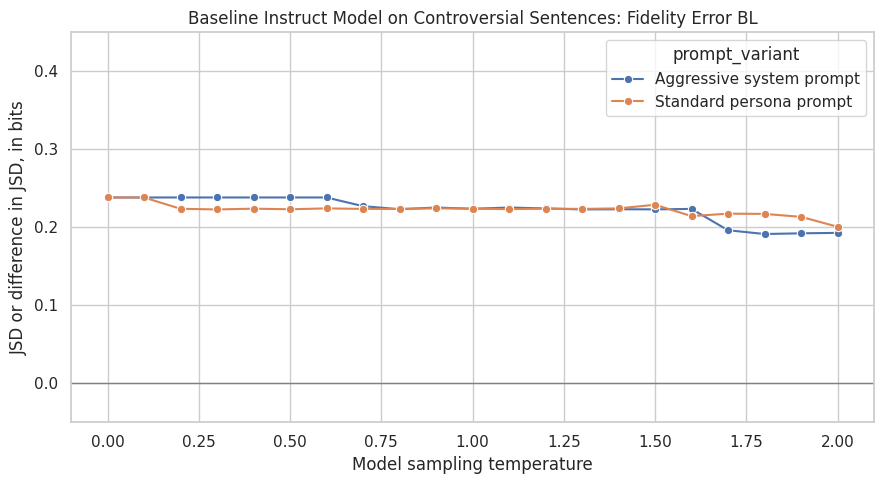

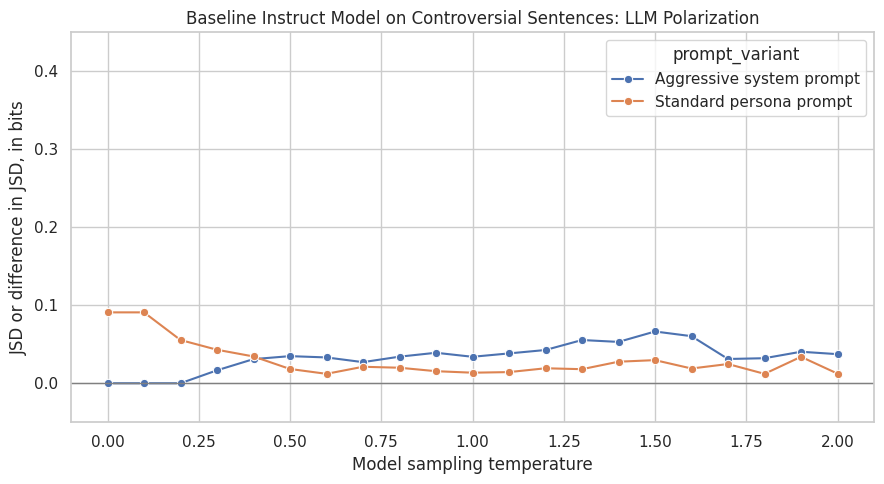

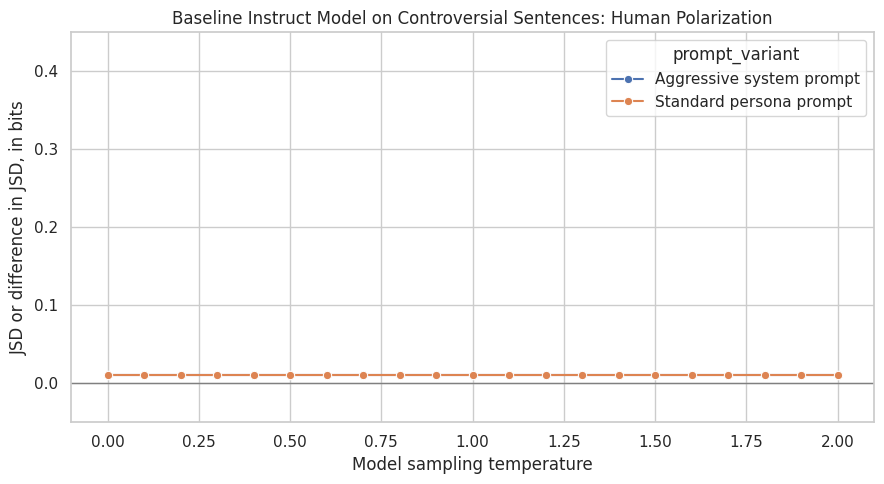

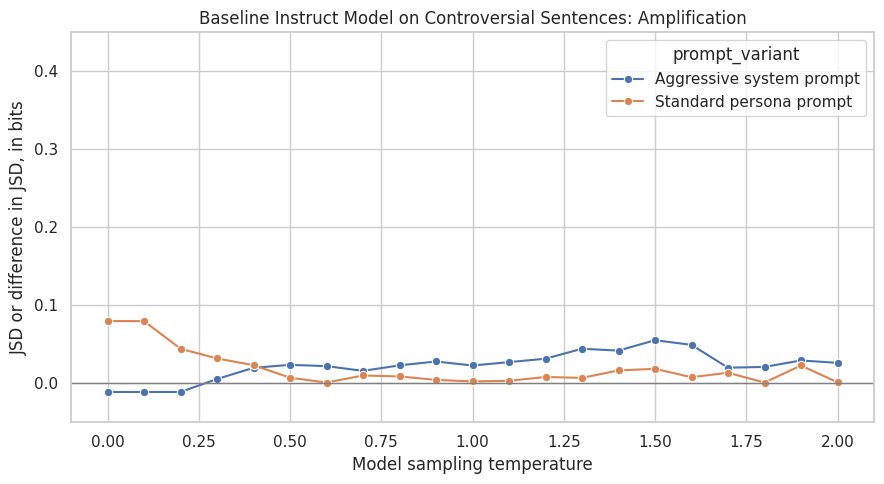

In [169]:
def plot_baseline_instruct_metrics(summary_df):
    metric_configs = [
        ("fid_wc", "Fidelity Error WC"),
        ("fid_bl", "Fidelity Error BL"),
        ("pol_llm", "LLM Polarization"),
        ("pol_hum", "Human Polarization"),
        ("amplification", "Amplification"),
    ]

    for metric, title in metric_configs:
        plt.figure(figsize=(9, 5))

        sns.lineplot(
            data=summary_df,
            x="temperature",
            y=metric,
            hue="prompt_variant",
            marker="o",
        )

        plt.axhline(0, color="gray", linewidth=1)
        plt.title(f"Baseline Instruct Model on Controversial Sentences: {title}")
        plt.xlabel("Model sampling temperature")
        plt.ylabel("JSD or difference in JSD, in bits")
        plt.ylim(JSD_YLIM)
        plt.tight_layout()
        plt.show()


plot_baseline_instruct_metrics(baseline_instruct_summary)

## Baseline instruct model on consensus diagnostic sentences

The previous section evaluated the baseline instruct model on controversial sentences, where human annotators disagree.

This section repeats the same baseline analysis on the consensus diagnostic set. These are sentences where both White Conservative and Black Liberal annotators are close to consensus.

This diagnostic is useful because increasing sampling temperature may create artificial disagreement even when humans mostly agree. In that case, lower fidelity error on controversial examples may be misleading: the model may be adding random variance rather than reproducing human-like disagreement.

In [170]:
aggressive_consensus_baseline_summary, aggressive_consensus_baseline_details = process_instruct_baseline_folder(
    folder_path="./data_instruct_consensus_aggressive1",
    filename_template="llama3_consensus_baseline_aggressive_T{temp}_N50.csv",
    prompt_variant_label="Aggressive system prompt",
)

sandwiched_consensus_baseline_summary, sandwiched_consensus_baseline_details = process_instruct_baseline_folder(
    folder_path="./data_instruct_consensus_sandwiched2",
    filename_template="llama3_consensus_baseline_sandwiched_T{temp}_N50.csv",
    prompt_variant_label="Standard persona prompt",
)

consensus_baseline_parts = [
    df_part
    for df_part in [
        aggressive_consensus_baseline_summary,
        sandwiched_consensus_baseline_summary,
    ]
    if not df_part.empty
]

if consensus_baseline_parts:
    consensus_instruct_baseline_summary = pd.concat(
        consensus_baseline_parts,
        ignore_index=True,
    )
else:
    consensus_instruct_baseline_summary = pd.DataFrame()

display(consensus_instruct_baseline_summary)

Processing baseline runs: Aggressive system prompt
Folder: data_instruct_consensus_aggressive1
Successfully processed 21 files.
Processing baseline runs: Standard persona prompt
Folder: data_instruct_consensus_sandwiched2
Successfully processed 21 files.


,fid_wc,fid_bl,pol_llm,pol_hum,amplification,n_sentences,n_valid_fid_wc,n_valid_fid_bl,n_valid_pol_llm,n_valid_pol_hum,...,max_llm_bl_votes_per_sentence,all_wc_vote_counts_match_expected,all_bl_vote_counts_match_expected,mean_n_human_wc,mean_n_human_bl,min_n_human_wc,min_n_human_bl,prompt_variant,temperature,file_path
0,0.014158,0.009430,0.000000,0.008343,-0.008343,20,20,20,20,20,...,50,True,True,70.0,19.4,32,7,Aggressive system prompt,0.0,data_instruct_consensus_aggressive1/llama3_consensus_baseline_aggressive_T0.0_N50.csv
1,0.014158,0.009430,0.000000,0.008343,-0.008343,20,20,20,20,20,...,50,True,True,70.0,19.4,32,7,Aggressive system prompt,0.1,data_instruct_consensus_aggressive1/llama3_consensus_baseline_aggressive_T0.1_N50.csv
2,0.014158,0.009430,0.000000,0.008343,-0.008343,20,20,20,20,20,...,50,True,True,70.0,19.4,32,7,Aggressive system prompt,0.2,data_instruct_consensus_aggressive1/llama3_consensus_baseline_aggressive_T0.2_N50.csv
3,0.014158,0.009430,0.000000,0.008343,-0.008343,20,20,20,20,20,...,50,True,True,70.0,19.4,32,7,Aggressive system prompt,0.3,data_instruct_consensus_aggressive1/llama3_consensus_baseline_aggressive_T0.3_N50.csv
4,0.014158,0.009430,0.000000,0.008343,-0.008343,20,20,20,20,20,...,50,True,True,70.0,19.4,32,7,Aggressive system prompt,0.4,data_instruct_consensus_aggressive1/llama3_consensus_baseline_aggressive_T0.4_N50.csv
5,0.014158,0.012568,0.003138,0.008343,-0.005205,20,20,20,20,20,...,50,True,True,70.0,19.4,32,7,Aggressive system prompt,0.5,data_instruct_consensus_aggressive1/llama3_consensus_baseline_aggressive_T0.5_N50.csv
6,0.014158,0.014831,0.005402,0.008343,-0.002941,20,20,20,20,20,...,50,True,True,70.0,19.4,32,7,Aggressive system prompt,0.6,data_instruct_consensus_aggressive1/llama3_consensus_baseline_aggressive_T0.6_N50.csv
7,0.014158,0.018536,0.009106,0.008343,0.000763,20,20,20,20,20,...,50,True,True,70.0,19.4,32,7,Aggressive system prompt,0.7,data_instruct_consensus_aggressive1/llama3_consensus_baseline_aggressive_T0.7_N50.csv
8,0.014158,0.015421,0.005992,0.008343,-0.002351,20,20,20,20,20,...,50,True,True,70.0,19.4,32,7,Aggressive system prompt,0.8,data_instruct_consensus_aggressive1/llama3_consensus_baseline_aggressive_T0.8_N50.csv
9,0.014158,0.019194,0.009765,0.008343,0.001422,20,20,20,20,20,...,50,True,True,70.0,19.4,32,7,Aggressive system prompt,0.9,data_instruct_consensus_aggressive1/llama3_consensus_baseline_aggressive_T0.9_N50.csv


In [171]:
consensus_invalid_vote_audit = consensus_instruct_baseline_summary[invalid_vote_audit_cols].copy()

display(consensus_invalid_vote_audit)

print("Total invalid votes across all consensus baseline instruct runs:")
display(
    consensus_invalid_vote_audit
    .groupby("prompt_variant")[["total_invalid_wc_votes", "total_invalid_bl_votes", "total_invalid_votes"]]
    .sum()
)

,prompt_variant,temperature,n_sentences,total_invalid_wc_votes,total_invalid_bl_votes,total_invalid_votes,mean_wc_invalid_rate,mean_bl_invalid_rate,all_wc_vote_counts_match_expected,all_bl_vote_counts_match_expected,min_llm_wc_votes_per_sentence,max_llm_wc_votes_per_sentence,min_llm_bl_votes_per_sentence,max_llm_bl_votes_per_sentence
0,Aggressive system prompt,0.0,20,0,0,0,0.0,0.0,True,True,50,50,50,50
1,Aggressive system prompt,0.1,20,0,0,0,0.0,0.0,True,True,50,50,50,50
2,Aggressive system prompt,0.2,20,0,0,0,0.0,0.0,True,True,50,50,50,50
3,Aggressive system prompt,0.3,20,0,0,0,0.0,0.0,True,True,50,50,50,50
4,Aggressive system prompt,0.4,20,0,0,0,0.0,0.0,True,True,50,50,50,50
5,Aggressive system prompt,0.5,20,0,0,0,0.0,0.0,True,True,50,50,50,50
6,Aggressive system prompt,0.6,20,0,0,0,0.0,0.0,True,True,50,50,50,50
7,Aggressive system prompt,0.7,20,0,0,0,0.0,0.0,True,True,50,50,50,50
8,Aggressive system prompt,0.8,20,0,0,0,0.0,0.0,True,True,50,50,50,50
9,Aggressive system prompt,0.9,20,0,0,0,0.0,0.0,True,True,50,50,50,50


Total invalid votes across all consensus baseline instruct runs:


,total_invalid_wc_votes,total_invalid_bl_votes,total_invalid_votes
prompt_variant,,,
Aggressive system prompt,0,0,0
Standard persona prompt,0,0,0


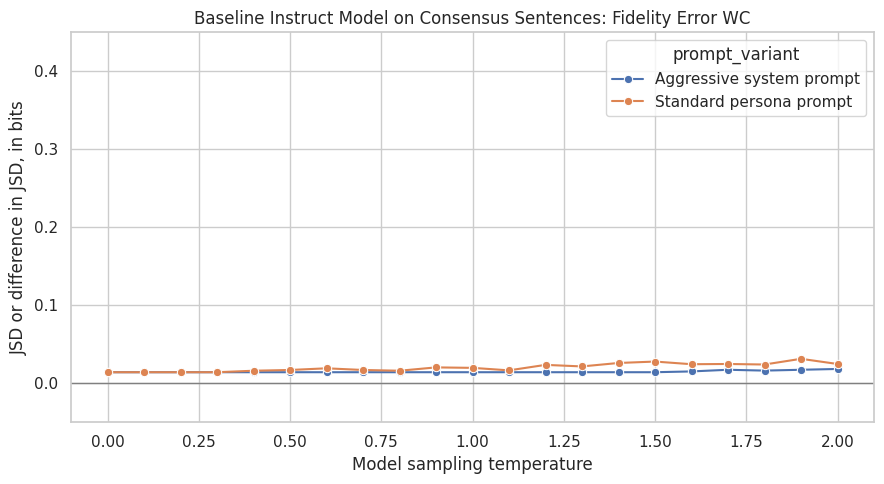

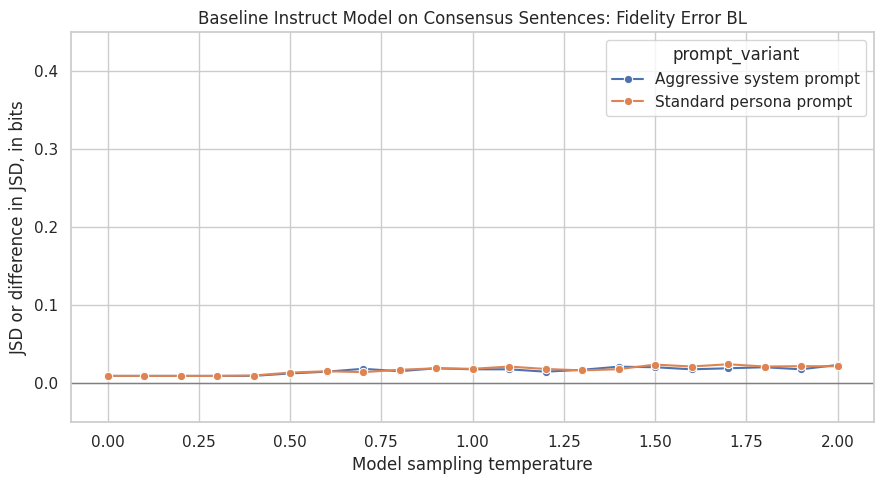

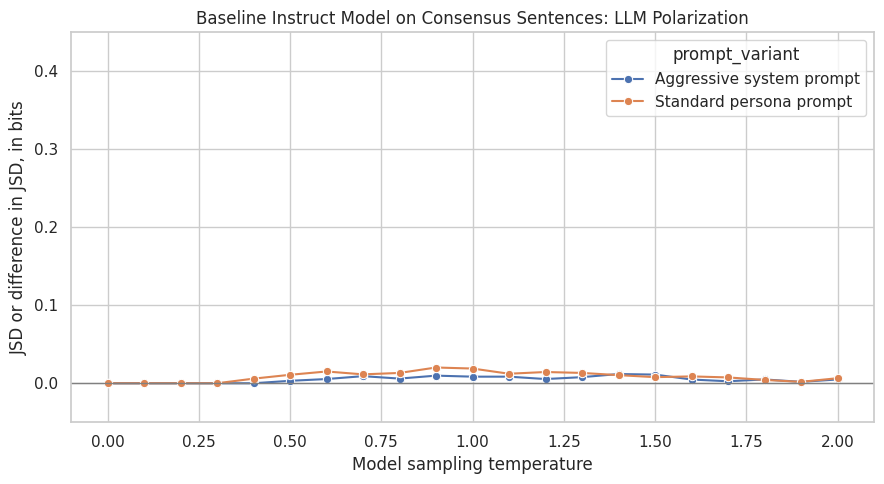

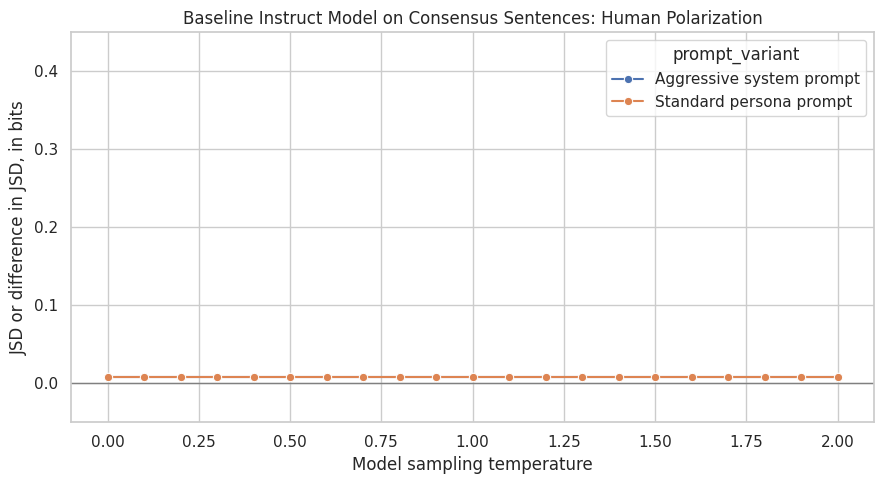

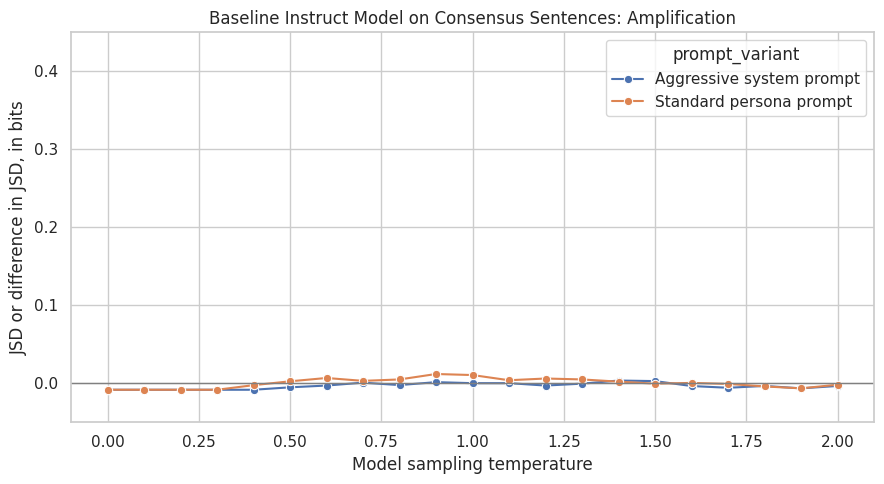

In [172]:
def plot_consensus_baseline_instruct_metrics(summary_df):
    metric_configs = [
        ("fid_wc", "Fidelity Error WC"),
        ("fid_bl", "Fidelity Error BL"),
        ("pol_llm", "LLM Polarization"),
        ("pol_hum", "Human Polarization"),
        ("amplification", "Amplification"),
    ]

    for metric, title in metric_configs:
        plt.figure(figsize=(9, 5))

        sns.lineplot(
            data=summary_df,
            x="temperature",
            y=metric,
            hue="prompt_variant",
            marker="o",
        )

        plt.axhline(0, color="gray", linewidth=1)
        plt.title(f"Baseline Instruct Model on Consensus Sentences: {title}")
        plt.xlabel("Model sampling temperature")
        plt.ylabel("JSD or difference in JSD, in bits")
        plt.ylim(JSD_YLIM)
        plt.tight_layout()
        plt.show()


plot_consensus_baseline_instruct_metrics(consensus_instruct_baseline_summary)

In [173]:
controversial_baseline_for_comparison = baseline_instruct_summary.copy()
controversial_baseline_for_comparison["sentence_set"] = "Controversial"

consensus_baseline_for_comparison = consensus_instruct_baseline_summary.copy()
consensus_baseline_for_comparison["sentence_set"] = "Consensus"

baseline_set_comparison = pd.concat(
    [
        controversial_baseline_for_comparison,
        consensus_baseline_for_comparison,
    ],
    ignore_index=True,
)

baseline_set_comparison["mean_fidelity_error"] = (
    baseline_set_comparison["fid_wc"] + baseline_set_comparison["fid_bl"]
) / 2

display(
    baseline_set_comparison[
        [
            "sentence_set",
            "prompt_variant",
            "temperature",
            "fid_wc",
            "fid_bl",
            "mean_fidelity_error",
            "pol_llm",
            "pol_hum",
            "amplification",
            "total_invalid_votes",
        ]
    ]
)

,sentence_set,prompt_variant,temperature,fid_wc,fid_bl,mean_fidelity_error,pol_llm,pol_hum,amplification,total_invalid_votes
0,Controversial,Aggressive system prompt,0.0,0.267444,0.238232,0.252838,0.000000,0.011169,-0.011169,0
1,Controversial,Aggressive system prompt,0.1,0.267444,0.238232,0.252838,0.000000,0.011169,-0.011169,0
2,Controversial,Aggressive system prompt,0.2,0.267444,0.238232,0.252838,0.000000,0.011169,-0.011169,0
3,Controversial,Aggressive system prompt,0.3,0.234507,0.238232,0.236370,0.016600,0.011169,0.005431,0
4,Controversial,Aggressive system prompt,0.4,0.227169,0.238232,0.232701,0.030961,0.011169,0.019793,0
...,...,...,...,...,...,...,...,...,...,...
79,Consensus,Standard persona prompt,1.6,0.024423,0.021474,0.022948,0.008788,0.008343,0.000445,0
80,Consensus,Standard persona prompt,1.7,0.024718,0.024368,0.024543,0.007478,0.008343,-0.000865,0
81,Consensus,Standard persona prompt,1.8,0.024031,0.021474,0.022752,0.004285,0.008343,-0.004058,0
82,Consensus,Standard persona prompt,1.9,0.031345,0.021900,0.026622,0.001805,0.008343,-0.006538,0


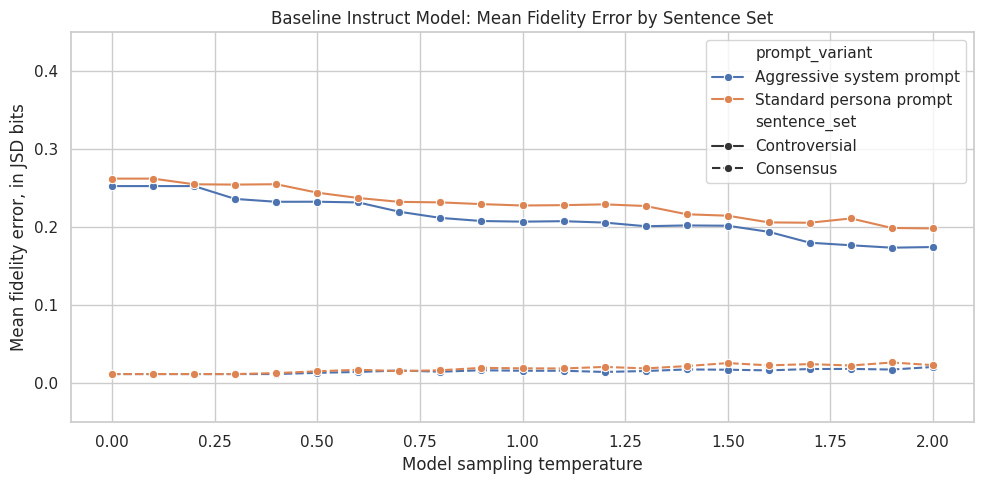

In [174]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=baseline_set_comparison,
    x="temperature",
    y="mean_fidelity_error",
    hue="prompt_variant",
    style="sentence_set",
    marker="o",
)

plt.title("Baseline Instruct Model: Mean Fidelity Error by Sentence Set")
plt.xlabel("Model sampling temperature")
plt.ylabel("Mean fidelity error, in JSD bits")
plt.ylim(JSD_YLIM)
plt.tight_layout()
plt.show()

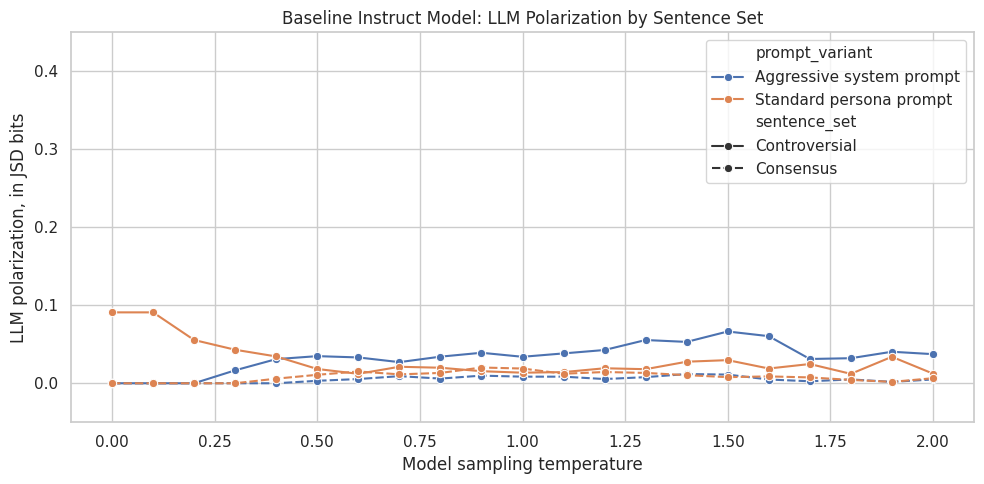

In [175]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=baseline_set_comparison,
    x="temperature",
    y="pol_llm",
    hue="prompt_variant",
    style="sentence_set",
    marker="o",
)

plt.title("Baseline Instruct Model: LLM Polarization by Sentence Set")
plt.xlabel("Model sampling temperature")
plt.ylabel("LLM polarization, in JSD bits")
plt.ylim(JSD_YLIM)
plt.tight_layout()
plt.show()

In [176]:
best_baseline_set_rows = []

for (sentence_set, prompt_variant), group_df in baseline_set_comparison.groupby(
    ["sentence_set", "prompt_variant"]
):
    temp_df = group_df.copy()

    best_mean_fid = (
        temp_df
        .assign(mean_fidelity_error=(temp_df["fid_wc"] + temp_df["fid_bl"]) / 2)
        .loc[lambda x: x["mean_fidelity_error"].idxmin()]
    )

    best_baseline_set_rows.append({
        "sentence_set": sentence_set,
        "prompt_variant": prompt_variant,
        "best_temperature_for_mean_fidelity": best_mean_fid["temperature"],
        "best_mean_fidelity_error": best_mean_fid["mean_fidelity_error"],
        "fid_wc_at_best_temp": best_mean_fid["fid_wc"],
        "fid_bl_at_best_temp": best_mean_fid["fid_bl"],
        "pol_llm_at_best_temp": best_mean_fid["pol_llm"],
        "pol_hum_at_best_temp": best_mean_fid["pol_hum"],
        "amplification_at_best_temp": best_mean_fid["amplification"],
        "invalid_votes_at_best_temp": best_mean_fid["total_invalid_votes"],
    })

best_baseline_set_summary = pd.DataFrame(best_baseline_set_rows)

display(best_baseline_set_summary)

,sentence_set,prompt_variant,best_temperature_for_mean_fidelity,best_mean_fidelity_error,fid_wc_at_best_temp,fid_bl_at_best_temp,pol_llm_at_best_temp,pol_hum_at_best_temp,amplification_at_best_temp,invalid_votes_at_best_temp
0,Consensus,Aggressive system prompt,0.0,0.011794,0.014158,0.009430,0.000000,0.008343,-0.008343,0
1,Consensus,Standard persona prompt,0.0,0.011794,0.014158,0.009430,0.000000,0.008343,-0.008343,0
2,Controversial,Aggressive system prompt,1.9,0.173852,0.155432,0.192271,0.040413,0.011169,0.029244,0
3,Controversial,Standard persona prompt,2.0,0.198533,0.196334,0.200731,0.012364,0.011169,0.001195,0


## Stereotype-collapse diagnostic for instruct baselines

To quantify stereotype collapse, we compute entropy over the 50 LLM votes for each sentence-persona pair.

A sentence-persona pair has entropy 0 when all valid LLM votes are identical, and entropy 1 when votes are split 50/50.

For compact reporting, we pool White Conservative and Black Liberal personas and report the average entropy across sentence-persona pairs. We also compute the monolith rate, defined as the fraction of sentence-persona pairs where all valid LLM votes collapse to a single label.

This table is restricted to the instruct baseline models on the controversial sentence set and temperatures from 0.0 to 1.0.

In [177]:
def binary_entropy_from_dist(dist):
    """
    Compute binary entropy in bits from [P(0), P(1)].
    Returns 0 for deterministic distributions and 1 for a 50/50 distribution.
    """

    if dist is None:
        return np.nan

    p = np.asarray(dist, dtype=float)

    if p.sum() == 0:
        return np.nan

    p = p / p.sum()
    p = p[p > 0]

    return float(-(p * np.log2(p)).sum())


def max_probability_from_dist(dist):
    """
    Return max(P(0), P(1)) from a binary distribution.
    """

    if dist is None:
        return np.nan

    p = np.asarray(dist, dtype=float)

    if p.sum() == 0:
        return np.nan

    p = p / p.sum()

    return float(p.max())


def monolith_rows_from_details(details_by_temp, prompt_variant, temperatures_to_keep):
    """
    Build sentence-persona-level monolith diagnostic rows from a details dictionary.

    Each row corresponds to one sentence and one persona at one temperature.
    """

    rows = []

    for temp, detail_df in details_by_temp.items():
        if round(float(temp), 1) not in temperatures_to_keep:
            continue

        if detail_df is None or len(detail_df) == 0:
            continue

        for _, row in detail_df.iterrows():
            persona_specs = [
                {
                    "persona": "WC",
                    "llm_dist": row["llm_wc_dist"],
                    "human_dist": row["human_wc_dist"],
                    "n_valid_llm": row["n_llm_wc_valid"],
                },
                {
                    "persona": "BL",
                    "llm_dist": row["llm_bl_dist"],
                    "human_dist": row["human_bl_dist"],
                    "n_valid_llm": row["n_llm_bl_valid"],
                },
            ]

            for spec in persona_specs:
                llm_entropy = binary_entropy_from_dist(spec["llm_dist"])
                human_entropy = binary_entropy_from_dist(spec["human_dist"])
                llm_max_prob = max_probability_from_dist(spec["llm_dist"])

                rows.append({
                    "prompt_variant": prompt_variant,
                    "temperature": round(float(temp), 1),
                    "persona": spec["persona"],
                    "text": row["text"],
                    "n_valid_llm": spec["n_valid_llm"],
                    "llm_entropy": llm_entropy,
                    "human_entropy": human_entropy,
                    "entropy_gap": llm_entropy - human_entropy,
                    "llm_max_probability": llm_max_prob,
                    "exact_monolith": llm_max_prob == 1.0,
                    "near_monolith_95": llm_max_prob >= 0.95,
                })

    return pd.DataFrame(rows)


TEMPS_MONOLITH_TABLE = [round(x * 0.1, 1) for x in range(11)]

monolith_instruct_parts = [
    monolith_rows_from_details(
        details_by_temp=aggressive_baseline_details,
        prompt_variant="Aggressive",
        temperatures_to_keep=TEMPS_MONOLITH_TABLE,
    ),
    monolith_rows_from_details(
        details_by_temp=sandwiched_baseline_details,
        prompt_variant="Sandwiched",
        temperatures_to_keep=TEMPS_MONOLITH_TABLE,
    ),
]

monolith_instruct_detail = pd.concat(
    monolith_instruct_parts,
    ignore_index=True,
)

display(monolith_instruct_detail.head())

,prompt_variant,temperature,persona,text,n_valid_llm,llm_entropy,human_entropy,entropy_gap,llm_max_probability,exact_monolith,near_monolith_95
0,Aggressive,0.0,WC,Who hurt you? Lol. It's comical how stupid and angry you people are. MEH AMURICA. MY LAND. MINE. BANG BANG GUNS. NO BROWN PEOPLE. WAHH.,50,-0.0,0.999793,-0.999793,1.0,True,True
1,Aggressive,0.0,BL,Who hurt you? Lol. It's comical how stupid and angry you people are. MEH AMURICA. MY LAND. MINE. BANG BANG GUNS. NO BROWN PEOPLE. WAHH.,50,-0.0,0.977418,-0.977418,1.0,True,True
2,Aggressive,0.0,WC,"RT @JihadistJoe: We Muslims have no military honour whatsoever, we are sub human savages that slaughter unarmed men, women & children http:…",50,-0.0,0.985909,-0.985909,1.0,True,True
3,Aggressive,0.0,BL,"RT @JihadistJoe: We Muslims have no military honour whatsoever, we are sub human savages that slaughter unarmed men, women & children http:…",50,-0.0,0.791858,-0.791858,1.0,True,True
4,Aggressive,0.0,WC,"im ,i hate black people and minorities",50,-0.0,0.983376,-0.983376,1.0,True,True


In [178]:
monolith_instruct_summary = (
    monolith_instruct_detail
    .groupby(["prompt_variant", "temperature"])
    .agg(
        n_sentence_persona_cases=("text", "count"),
        mean_llm_entropy=("llm_entropy", "mean"),
        mean_human_entropy=("human_entropy", "mean"),
        mean_entropy_gap=("entropy_gap", "mean"),
        exact_monolith_rate=("exact_monolith", "mean"),
        near_monolith_95_rate=("near_monolith_95", "mean"),
        mean_valid_llm_votes=("n_valid_llm", "mean"),
    )
    .reset_index()
)

monolith_instruct_summary_for_latex = monolith_instruct_summary.copy()

round_cols = [
    "mean_llm_entropy",
    "mean_human_entropy",
    "mean_entropy_gap",
    "exact_monolith_rate",
    "near_monolith_95_rate",
    "mean_valid_llm_votes",
]

for col in round_cols:
    monolith_instruct_summary_for_latex[col] = monolith_instruct_summary_for_latex[col].round(3)

display(monolith_instruct_summary_for_latex)

,prompt_variant,temperature,n_sentence_persona_cases,mean_llm_entropy,mean_human_entropy,mean_entropy_gap,exact_monolith_rate,near_monolith_95_rate,mean_valid_llm_votes
0,Aggressive,0.0,22,0.000,0.934,-0.934,1.000,1.000,50.0
1,Aggressive,0.1,22,0.000,0.934,-0.934,1.000,1.000,50.0
2,Aggressive,0.2,22,0.000,0.934,-0.934,1.000,1.000,50.0
3,Aggressive,0.3,22,0.059,0.934,-0.875,0.909,0.909,50.0
4,Aggressive,0.4,22,0.079,0.934,-0.855,0.909,0.909,50.0
5,Aggressive,0.5,22,0.081,0.934,-0.853,0.909,0.909,50.0
6,Aggressive,0.6,22,0.082,0.934,-0.852,0.909,0.909,50.0
7,Aggressive,0.7,22,0.124,0.934,-0.810,0.773,0.864,50.0
8,Aggressive,0.8,22,0.161,0.934,-0.773,0.773,0.818,50.0
9,Aggressive,0.9,22,0.166,0.934,-0.768,0.773,0.773,50.0


In [179]:
MONOLITH_OUTPUT_DIR = Path("./diagnostic_outputs")
MONOLITH_OUTPUT_DIR.mkdir(exist_ok=True)

MONOLITH_DETAIL_PATH = MONOLITH_OUTPUT_DIR / "instruct_baseline_monolith_detail_T0_to_T1.csv"
MONOLITH_SUMMARY_PATH = MONOLITH_OUTPUT_DIR / "instruct_baseline_monolith_summary_T0_to_T1.csv"

monolith_instruct_detail.to_csv(
    MONOLITH_DETAIL_PATH,
    index=False,
)

monolith_instruct_summary_for_latex.to_csv(
    MONOLITH_SUMMARY_PATH,
    index=False,
)

print(f"Saved detailed monolith diagnostics to: {MONOLITH_DETAIL_PATH}")
print(f"Saved compact monolith summary to:      {MONOLITH_SUMMARY_PATH}")

Saved detailed monolith diagnostics to: diagnostic_outputs/instruct_baseline_monolith_detail_T0_to_T1.csv
Saved compact monolith summary to:      diagnostic_outputs/instruct_baseline_monolith_summary_T0_to_T1.csv


## Baseline base model: no instruction tuning and no Chain-of-Persona prompting

This section evaluates the non-instruct/base Llama model without Chain-of-Persona prompting.

Unlike the instruct model, the base model was prompted using a few-shot completion format rather than a system-instruction format. The purpose is to test whether removing instruction tuning and safety-oriented alignment changes the model's ability to reproduce human annotation distributions.

The analysis is run on two sentence sets:

1. Controversial sentences, where humans disagree.
2. Consensus diagnostic sentences, where humans mostly agree.

As before, each CSV contains 50 binary votes per sentence for the White Conservative and Black Liberal personas.

In [180]:
base_controversial_baseline_summary, base_controversial_baseline_details = process_instruct_baseline_folder(
    folder_path="./data_binary3",
    filename_template="llama3_base_binary_baseline_T{temp}_N50.csv",
    prompt_variant_label="Base model few-shot prompt",
)

base_controversial_baseline_summary["sentence_set"] = "Controversial"

display(base_controversial_baseline_summary)

Processing baseline runs: Base model few-shot prompt
Folder: data_binary3
Successfully processed 21 files.


,fid_wc,fid_bl,pol_llm,pol_hum,amplification,n_sentences,n_valid_fid_wc,n_valid_fid_bl,n_valid_pol_llm,n_valid_pol_hum,...,all_wc_vote_counts_match_expected,all_bl_vote_counts_match_expected,mean_n_human_wc,mean_n_human_bl,min_n_human_wc,min_n_human_bl,prompt_variant,temperature,file_path,sentence_set
0,0.307656,0.273106,0.000000,0.011169,-0.011169,11,11,11,11,11,...,True,True,57.363636,17.454545,33,8,Base model few-shot prompt,0.0,data_binary3/llama3_base_binary_baseline_T0.0_N50.csv,Controversial
1,0.269517,0.273106,0.029757,0.011169,0.018588,11,11,11,11,11,...,True,True,57.363636,17.454545,33,8,Base model few-shot prompt,0.1,data_binary3/llama3_base_binary_baseline_T0.1_N50.csv,Controversial
2,0.246212,0.241250,0.011242,0.011169,0.000073,11,11,11,11,11,...,True,True,57.363636,17.454545,33,8,Base model few-shot prompt,0.2,data_binary3/llama3_base_binary_baseline_T0.2_N50.csv,Controversial
3,0.228317,0.217863,0.004193,0.011169,-0.006976,11,11,11,11,11,...,True,True,57.363636,17.454545,33,8,Base model few-shot prompt,0.3,data_binary3/llama3_base_binary_baseline_T0.3_N50.csv,Controversial
4,0.208333,0.197304,0.005532,0.011169,-0.005637,11,11,11,11,11,...,True,True,57.363636,17.454545,33,8,Base model few-shot prompt,0.4,data_binary3/llama3_base_binary_baseline_T0.4_N50.csv,Controversial
5,0.148211,0.164122,0.007803,0.011169,-0.003366,11,11,11,11,11,...,True,True,57.363636,17.454545,33,8,Base model few-shot prompt,0.5,data_binary3/llama3_base_binary_baseline_T0.5_N50.csv,Controversial
6,0.163959,0.151725,0.003864,0.011169,-0.007305,11,11,11,11,11,...,True,True,57.363636,17.454545,33,8,Base model few-shot prompt,0.6,data_binary3/llama3_base_binary_baseline_T0.6_N50.csv,Controversial
7,0.111888,0.123342,0.007351,0.011169,-0.003818,11,11,11,11,11,...,True,True,57.363636,17.454545,33,8,Base model few-shot prompt,0.7,data_binary3/llama3_base_binary_baseline_T0.7_N50.csv,Controversial
8,0.084048,0.097542,0.006623,0.011169,-0.004546,11,11,11,11,11,...,True,True,57.363636,17.454545,33,8,Base model few-shot prompt,0.8,data_binary3/llama3_base_binary_baseline_T0.8_N50.csv,Controversial
9,0.090601,0.083045,0.008384,0.011169,-0.002785,11,11,11,11,11,...,True,True,57.363636,17.454545,33,8,Base model few-shot prompt,0.9,data_binary3/llama3_base_binary_baseline_T0.9_N50.csv,Controversial


In [181]:
base_controversial_invalid_vote_audit = base_controversial_baseline_summary[
    invalid_vote_audit_cols
].copy()

display(base_controversial_invalid_vote_audit)

print("Total invalid votes for base model baseline on controversial sentences:")
display(
    base_controversial_invalid_vote_audit[
        ["total_invalid_wc_votes", "total_invalid_bl_votes", "total_invalid_votes"]
    ].sum()
)

,prompt_variant,temperature,n_sentences,total_invalid_wc_votes,total_invalid_bl_votes,total_invalid_votes,mean_wc_invalid_rate,mean_bl_invalid_rate,all_wc_vote_counts_match_expected,all_bl_vote_counts_match_expected,min_llm_wc_votes_per_sentence,max_llm_wc_votes_per_sentence,min_llm_bl_votes_per_sentence,max_llm_bl_votes_per_sentence
0,Base model few-shot prompt,0.0,11,0,0,0,0.0,0.000000,True,True,50,50,50,50
1,Base model few-shot prompt,0.1,11,0,0,0,0.0,0.000000,True,True,50,50,50,50
2,Base model few-shot prompt,0.2,11,0,0,0,0.0,0.000000,True,True,50,50,50,50
3,Base model few-shot prompt,0.3,11,0,0,0,0.0,0.000000,True,True,50,50,50,50
4,Base model few-shot prompt,0.4,11,0,0,0,0.0,0.000000,True,True,50,50,50,50
5,Base model few-shot prompt,0.5,11,0,0,0,0.0,0.000000,True,True,50,50,50,50
6,Base model few-shot prompt,0.6,11,0,0,0,0.0,0.000000,True,True,50,50,50,50
7,Base model few-shot prompt,0.7,11,0,0,0,0.0,0.000000,True,True,50,50,50,50
8,Base model few-shot prompt,0.8,11,0,0,0,0.0,0.000000,True,True,50,50,50,50
9,Base model few-shot prompt,0.9,11,0,0,0,0.0,0.000000,True,True,50,50,50,50


Total invalid votes for base model baseline on controversial sentences:


total_invalid_wc_votes    0
total_invalid_bl_votes    8
total_invalid_votes       8
dtype: int64

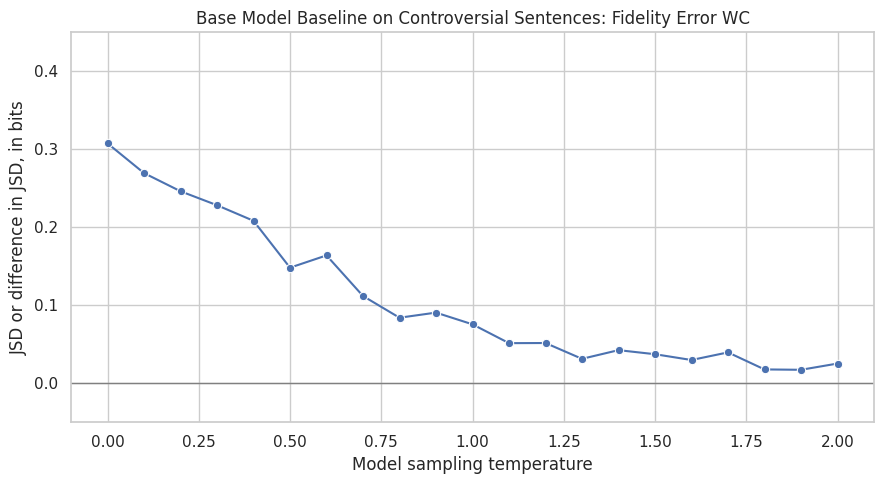

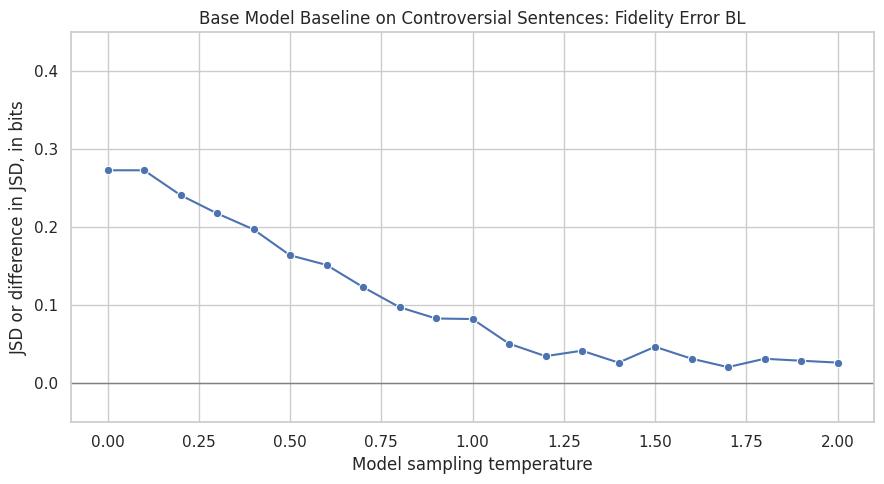

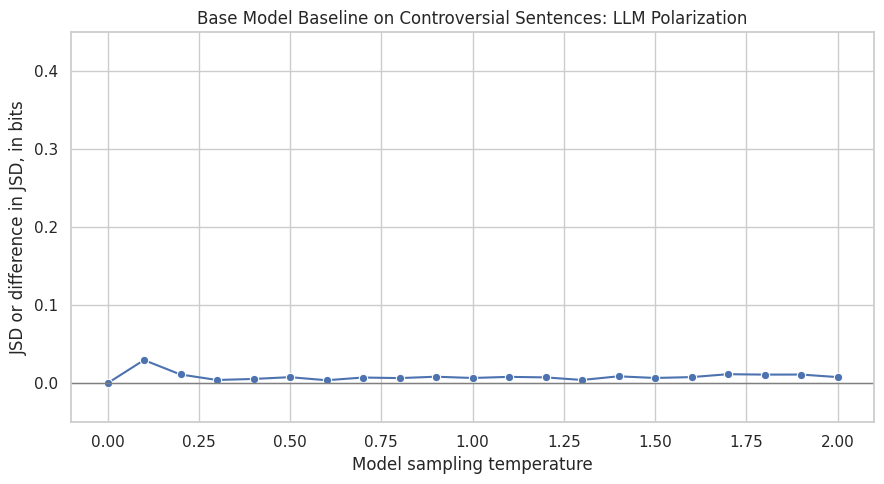

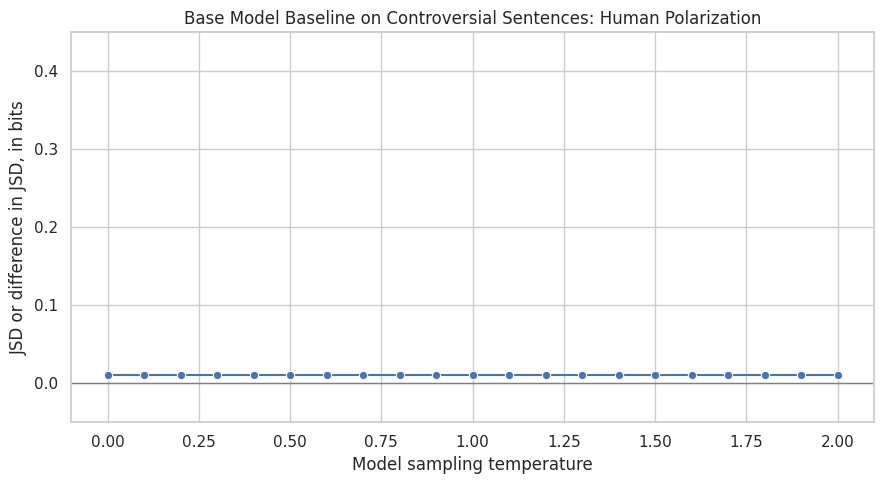

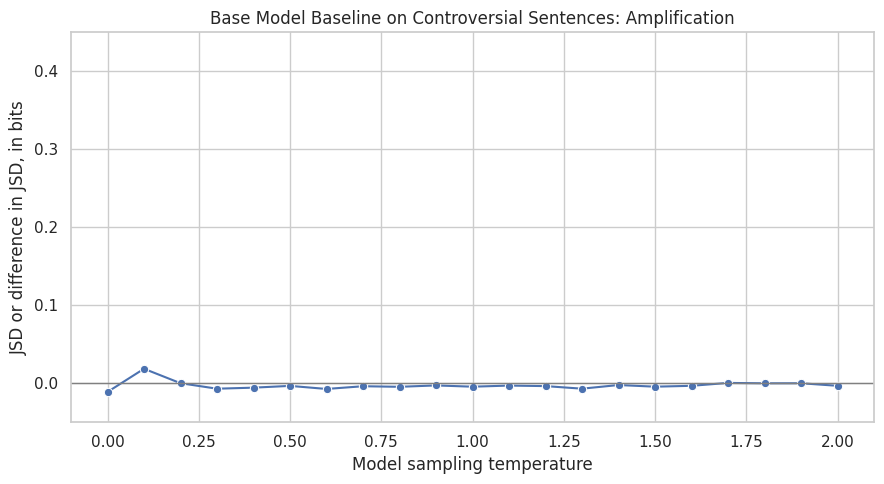

In [182]:
def plot_base_baseline_metrics(summary_df, sentence_set_label):
    metric_configs = [
        ("fid_wc", "Fidelity Error WC"),
        ("fid_bl", "Fidelity Error BL"),
        ("pol_llm", "LLM Polarization"),
        ("pol_hum", "Human Polarization"),
        ("amplification", "Amplification"),
    ]

    for metric, title in metric_configs:
        plt.figure(figsize=(9, 5))

        sns.lineplot(
            data=summary_df,
            x="temperature",
            y=metric,
            marker="o",
        )

        plt.axhline(0, color="gray", linewidth=1)
        plt.title(f"Base Model Baseline on {sentence_set_label} Sentences: {title}")
        plt.xlabel("Model sampling temperature")
        plt.ylabel("JSD or difference in JSD, in bits")
        plt.ylim(JSD_YLIM)
        plt.tight_layout()
        plt.show()


plot_base_baseline_metrics(
    base_controversial_baseline_summary,
    sentence_set_label="Controversial",
)

In [183]:
base_consensus_baseline_summary, base_consensus_baseline_details = process_instruct_baseline_folder(
    folder_path="./data_base_consensus",
    filename_template="llama3_base_consensus_T{temp}_N50.csv",
    prompt_variant_label="Base model few-shot prompt",
)

base_consensus_baseline_summary["sentence_set"] = "Consensus"

display(base_consensus_baseline_summary)

Processing baseline runs: Base model few-shot prompt
Folder: data_base_consensus
Successfully processed 21 files.


,fid_wc,fid_bl,pol_llm,pol_hum,amplification,n_sentences,n_valid_fid_wc,n_valid_fid_bl,n_valid_pol_llm,n_valid_pol_hum,...,all_wc_vote_counts_match_expected,all_bl_vote_counts_match_expected,mean_n_human_wc,mean_n_human_bl,min_n_human_wc,min_n_human_bl,prompt_variant,temperature,file_path,sentence_set
0,0.014158,0.009430,0.000000,0.008343,-0.008343,20,20,20,20,20,...,True,True,70.0,19.4,32,7,Base model few-shot prompt,0.0,data_base_consensus/llama3_base_consensus_T0.0_N50.csv,Consensus
1,0.014158,0.009430,0.000000,0.008343,-0.008343,20,20,20,20,20,...,True,True,70.0,19.4,32,7,Base model few-shot prompt,0.1,data_base_consensus/llama3_base_consensus_T0.1_N50.csv,Consensus
2,0.014158,0.009430,0.000000,0.008343,-0.008343,20,20,20,20,20,...,True,True,70.0,19.4,32,7,Base model few-shot prompt,0.2,data_base_consensus/llama3_base_consensus_T0.2_N50.csv,Consensus
3,0.014158,0.009430,0.000000,0.008343,-0.008343,20,20,20,20,20,...,True,True,70.0,19.4,32,7,Base model few-shot prompt,0.3,data_base_consensus/llama3_base_consensus_T0.3_N50.csv,Consensus
4,0.016753,0.015250,0.004970,0.008343,-0.003373,20,20,20,20,20,...,True,True,70.0,19.4,32,7,Base model few-shot prompt,0.4,data_base_consensus/llama3_base_consensus_T0.4_N50.csv,Consensus
5,0.019993,0.015575,0.000153,0.008343,-0.008190,20,20,20,20,20,...,True,True,70.0,19.4,32,7,Base model few-shot prompt,0.5,data_base_consensus/llama3_base_consensus_T0.5_N50.csv,Consensus
6,0.024238,0.017814,0.002482,0.008343,-0.005861,20,20,20,20,20,...,True,True,70.0,19.4,32,7,Base model few-shot prompt,0.6,data_base_consensus/llama3_base_consensus_T0.6_N50.csv,Consensus
7,0.020653,0.022735,0.002384,0.008343,-0.005959,20,20,20,20,20,...,True,True,70.0,19.4,32,7,Base model few-shot prompt,0.7,data_base_consensus/llama3_base_consensus_T0.7_N50.csv,Consensus
8,0.030400,0.026646,0.001060,0.008343,-0.007283,20,20,20,20,20,...,True,True,70.0,19.4,32,7,Base model few-shot prompt,0.8,data_base_consensus/llama3_base_consensus_T0.8_N50.csv,Consensus
9,0.036349,0.042284,0.007542,0.008343,-0.000801,20,20,20,20,20,...,True,True,70.0,19.4,32,7,Base model few-shot prompt,0.9,data_base_consensus/llama3_base_consensus_T0.9_N50.csv,Consensus


In [184]:
base_consensus_invalid_vote_audit = base_consensus_baseline_summary[
    invalid_vote_audit_cols
].copy()

display(base_consensus_invalid_vote_audit)

print("Total invalid votes for base model baseline on consensus sentences:")
display(
    base_consensus_invalid_vote_audit[
        ["total_invalid_wc_votes", "total_invalid_bl_votes", "total_invalid_votes"]
    ].sum()
)

,prompt_variant,temperature,n_sentences,total_invalid_wc_votes,total_invalid_bl_votes,total_invalid_votes,mean_wc_invalid_rate,mean_bl_invalid_rate,all_wc_vote_counts_match_expected,all_bl_vote_counts_match_expected,min_llm_wc_votes_per_sentence,max_llm_wc_votes_per_sentence,min_llm_bl_votes_per_sentence,max_llm_bl_votes_per_sentence
0,Base model few-shot prompt,0.0,20,0,0,0,0.000,0.000,True,True,50,50,50,50
1,Base model few-shot prompt,0.1,20,0,0,0,0.000,0.000,True,True,50,50,50,50
2,Base model few-shot prompt,0.2,20,0,0,0,0.000,0.000,True,True,50,50,50,50
3,Base model few-shot prompt,0.3,20,0,0,0,0.000,0.000,True,True,50,50,50,50
4,Base model few-shot prompt,0.4,20,0,0,0,0.000,0.000,True,True,50,50,50,50
5,Base model few-shot prompt,0.5,20,0,0,0,0.000,0.000,True,True,50,50,50,50
6,Base model few-shot prompt,0.6,20,0,0,0,0.000,0.000,True,True,50,50,50,50
7,Base model few-shot prompt,0.7,20,0,0,0,0.000,0.000,True,True,50,50,50,50
8,Base model few-shot prompt,0.8,20,0,0,0,0.000,0.000,True,True,50,50,50,50
9,Base model few-shot prompt,0.9,20,0,0,0,0.000,0.000,True,True,50,50,50,50


Total invalid votes for base model baseline on consensus sentences:


total_invalid_wc_votes    14
total_invalid_bl_votes    22
total_invalid_votes       36
dtype: int64

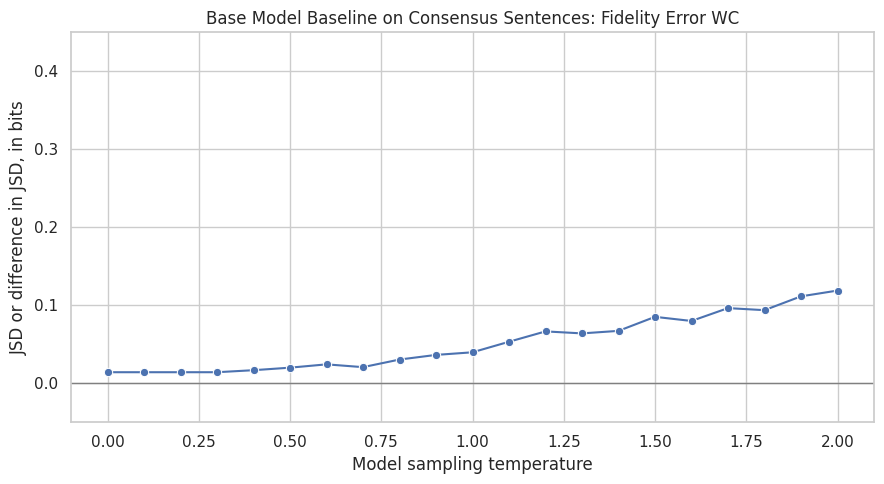

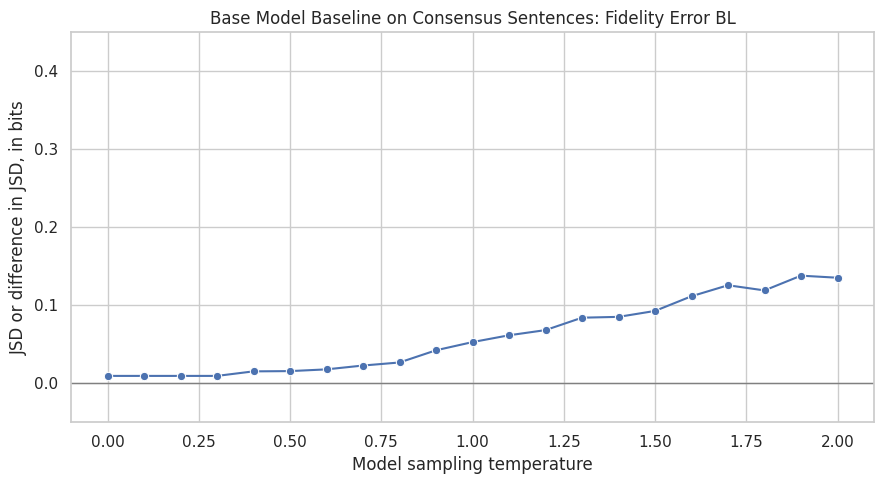

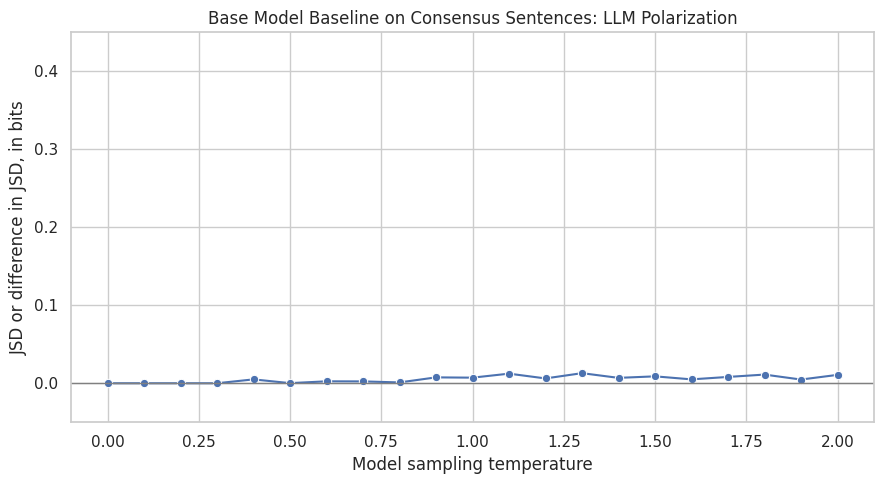

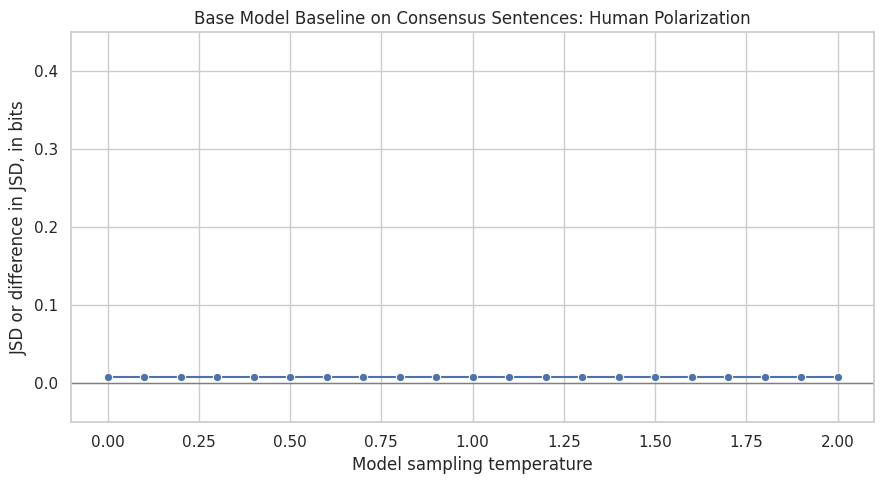

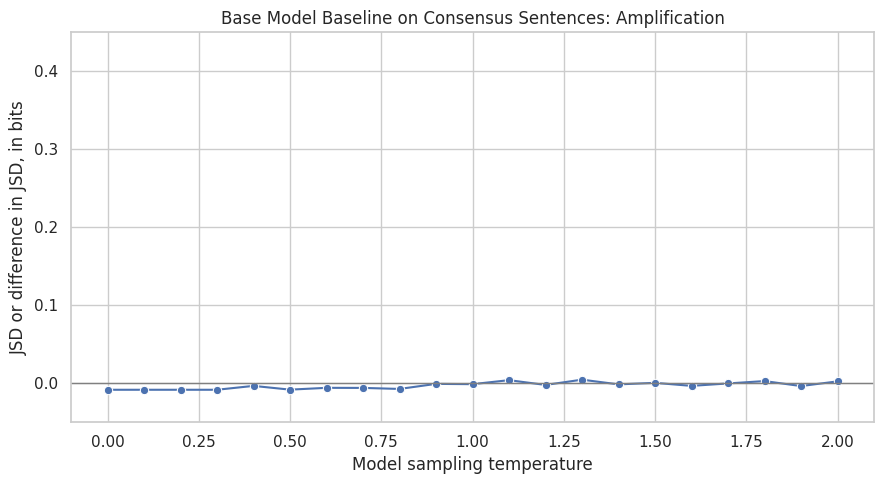

In [185]:
plot_base_baseline_metrics(
    base_consensus_baseline_summary,
    sentence_set_label="Consensus",
)

In [186]:
base_baseline_set_comparison = pd.concat(
    [
        base_controversial_baseline_summary,
        base_consensus_baseline_summary,
    ],
    ignore_index=True,
)

base_baseline_set_comparison["mean_fidelity_error"] = (
    base_baseline_set_comparison["fid_wc"]
    + base_baseline_set_comparison["fid_bl"]
) / 2

display(
    base_baseline_set_comparison[
        [
            "sentence_set",
            "temperature",
            "fid_wc",
            "fid_bl",
            "mean_fidelity_error",
            "pol_llm",
            "pol_hum",
            "amplification",
            "total_invalid_votes",
        ]
    ]
)

,sentence_set,temperature,fid_wc,fid_bl,mean_fidelity_error,pol_llm,pol_hum,amplification,total_invalid_votes
0,Controversial,0.0,0.307656,0.273106,0.290381,0.000000,0.011169,-0.011169,0
1,Controversial,0.1,0.269517,0.273106,0.271311,0.029757,0.011169,0.018588,0
2,Controversial,0.2,0.246212,0.241250,0.243731,0.011242,0.011169,0.000073,0
3,Controversial,0.3,0.228317,0.217863,0.223090,0.004193,0.011169,-0.006976,0
4,Controversial,0.4,0.208333,0.197304,0.202818,0.005532,0.011169,-0.005637,0
5,Controversial,0.5,0.148211,0.164122,0.156166,0.007803,0.011169,-0.003366,0
6,Controversial,0.6,0.163959,0.151725,0.157842,0.003864,0.011169,-0.007305,0
7,Controversial,0.7,0.111888,0.123342,0.117615,0.007351,0.011169,-0.003818,0
8,Controversial,0.8,0.084048,0.097542,0.090795,0.006623,0.011169,-0.004546,0
9,Controversial,0.9,0.090601,0.083045,0.086823,0.008384,0.011169,-0.002785,0


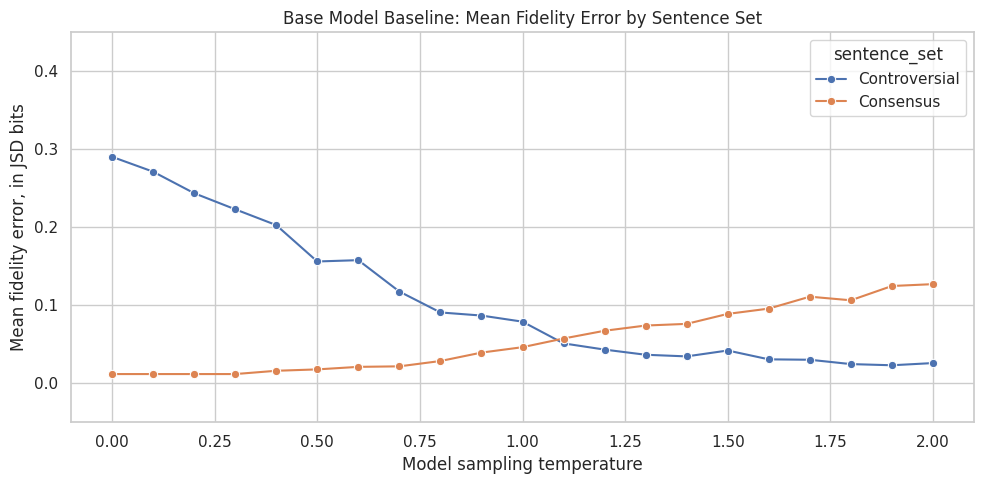

In [187]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=base_baseline_set_comparison,
    x="temperature",
    y="mean_fidelity_error",
    hue="sentence_set",
    marker="o",
)

plt.title("Base Model Baseline: Mean Fidelity Error by Sentence Set")
plt.xlabel("Model sampling temperature")
plt.ylabel("Mean fidelity error, in JSD bits")
plt.ylim(JSD_YLIM)
plt.tight_layout()
plt.show()

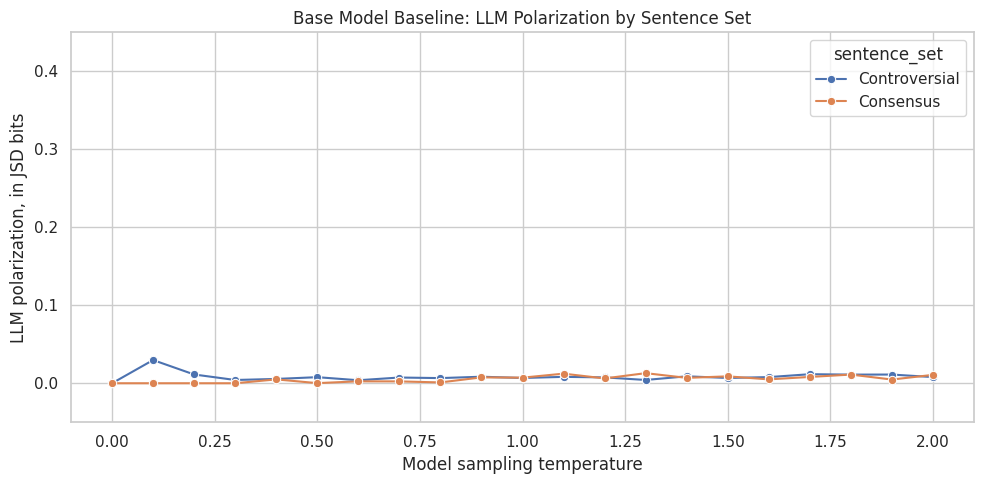

In [188]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=base_baseline_set_comparison,
    x="temperature",
    y="pol_llm",
    hue="sentence_set",
    marker="o",
)

plt.title("Base Model Baseline: LLM Polarization by Sentence Set")
plt.xlabel("Model sampling temperature")
plt.ylabel("LLM polarization, in JSD bits")
plt.ylim(JSD_YLIM)
plt.tight_layout()
plt.show()

In [189]:
best_base_baseline_rows = []

for sentence_set, group_df in base_baseline_set_comparison.groupby("sentence_set"):
    temp_df = group_df.copy()

    best_mean_fid = (
        temp_df
        .assign(mean_fidelity_error=(temp_df["fid_wc"] + temp_df["fid_bl"]) / 2)
        .loc[lambda x: x["mean_fidelity_error"].idxmin()]
    )

    best_base_baseline_rows.append({
        "sentence_set": sentence_set,
        "best_temperature_for_mean_fidelity": best_mean_fid["temperature"],
        "best_mean_fidelity_error": best_mean_fid["mean_fidelity_error"],
        "fid_wc_at_best_temp": best_mean_fid["fid_wc"],
        "fid_bl_at_best_temp": best_mean_fid["fid_bl"],
        "pol_llm_at_best_temp": best_mean_fid["pol_llm"],
        "pol_hum_at_best_temp": best_mean_fid["pol_hum"],
        "amplification_at_best_temp": best_mean_fid["amplification"],
        "invalid_votes_at_best_temp": best_mean_fid["total_invalid_votes"],
    })

best_base_baseline_summary = pd.DataFrame(best_base_baseline_rows)

display(best_base_baseline_summary)

,sentence_set,best_temperature_for_mean_fidelity,best_mean_fidelity_error,fid_wc_at_best_temp,fid_bl_at_best_temp,pol_llm_at_best_temp,pol_hum_at_best_temp,amplification_at_best_temp,invalid_votes_at_best_temp
0,Consensus,0.0,0.011794,0.014158,0.009430,0.000000,0.008343,-0.008343,0
1,Controversial,1.9,0.023070,0.017260,0.028879,0.011163,0.011169,-0.000006,0


## Dolphin baseline models: no Chain-of-Persona prompting

This section evaluates Dolphin-Llama models without Chain-of-Persona prompting.

Dolphin models are included as less safety-aligned / uncensored variants. The goal is to test whether the baseline behavior differs from the instruct and base Llama models when the same demographic simulation task is performed.

This section evaluates only the baseline files, meaning direct demographic prompting without generated sub-personas.

The analysis is run for:

- Dolphin 8B on controversial sentences
- Dolphin 70B on controversial sentences
- Dolphin 8B on consensus sentences
- Dolphin 70B on consensus sentences

In [190]:
dolphin8b_controversial_baseline_summary, dolphin8b_controversial_baseline_details = process_instruct_baseline_folder(
    folder_path="./data_dolphin_binary",
    filename_template="dolphin8b_binary_baseline_T{temp}_N50.csv",
    prompt_variant_label="Dolphin 8B baseline",
)

dolphin70b_controversial_baseline_summary, dolphin70b_controversial_baseline_details = process_instruct_baseline_folder(
    folder_path="./data_dolphin_binary70",
    filename_template="dolphin70b_binary_baseline_T{temp}_N50.csv",
    prompt_variant_label="Dolphin 70B baseline",
)

dolphin8b_controversial_baseline_summary["model"] = "Dolphin 8B"
dolphin70b_controversial_baseline_summary["model"] = "Dolphin 70B"

dolphin8b_controversial_baseline_summary["sentence_set"] = "Controversial"
dolphin70b_controversial_baseline_summary["sentence_set"] = "Controversial"

dolphin_controversial_baseline_summary = pd.concat(
    [
        dolphin8b_controversial_baseline_summary,
        dolphin70b_controversial_baseline_summary,
    ],
    ignore_index=True,
)

display(dolphin_controversial_baseline_summary)

Processing baseline runs: Dolphin 8B baseline
Folder: data_dolphin_binary
Successfully processed 21 files.
Processing baseline runs: Dolphin 70B baseline
Folder: data_dolphin_binary70
Successfully processed 21 files.


,fid_wc,fid_bl,pol_llm,pol_hum,amplification,n_sentences,n_valid_fid_wc,n_valid_fid_bl,n_valid_pol_llm,n_valid_pol_hum,...,all_bl_vote_counts_match_expected,mean_n_human_wc,mean_n_human_bl,min_n_human_wc,min_n_human_bl,prompt_variant,temperature,file_path,model,sentence_set
0,0.286584,0.275584,0.000000,0.011169,-0.011169,11,11,11,11,11,...,True,57.363636,17.454545,33,8,Dolphin 8B baseline,0.0,data_dolphin_binary/dolphin8b_binary_baseline_T0.0_N50.csv,Dolphin 8B,Controversial
1,0.286584,0.275584,0.000000,0.011169,-0.011169,11,11,11,11,11,...,True,57.363636,17.454545,33,8,Dolphin 8B baseline,0.1,data_dolphin_binary/dolphin8b_binary_baseline_T0.1_N50.csv,Dolphin 8B,Controversial
2,0.286584,0.275584,0.000000,0.011169,-0.011169,11,11,11,11,11,...,True,57.363636,17.454545,33,8,Dolphin 8B baseline,0.2,data_dolphin_binary/dolphin8b_binary_baseline_T0.2_N50.csv,Dolphin 8B,Controversial
3,0.254590,0.260750,0.011405,0.011169,0.000236,11,11,11,11,11,...,True,57.363636,17.454545,33,8,Dolphin 8B baseline,0.3,data_dolphin_binary/dolphin8b_binary_baseline_T0.3_N50.csv,Dolphin 8B,Controversial
4,0.252412,0.260234,0.005295,0.011169,-0.005873,11,11,11,11,11,...,True,57.363636,17.454545,33,8,Dolphin 8B baseline,0.4,data_dolphin_binary/dolphin8b_binary_baseline_T0.4_N50.csv,Dolphin 8B,Controversial
5,0.244487,0.260234,0.010753,0.011169,-0.000416,11,11,11,11,11,...,True,57.363636,17.454545,33,8,Dolphin 8B baseline,0.5,data_dolphin_binary/dolphin8b_binary_baseline_T0.5_N50.csv,Dolphin 8B,Controversial
6,0.220471,0.260203,0.021274,0.011169,0.010105,11,11,11,11,11,...,True,57.363636,17.454545,33,8,Dolphin 8B baseline,0.6,data_dolphin_binary/dolphin8b_binary_baseline_T0.6_N50.csv,Dolphin 8B,Controversial
7,0.214338,0.155845,0.027841,0.011169,0.016672,11,11,11,11,11,...,True,57.363636,17.454545,33,8,Dolphin 8B baseline,0.7,data_dolphin_binary/dolphin8b_binary_baseline_T0.7_N50.csv,Dolphin 8B,Controversial
8,0.190731,0.131057,0.026375,0.011169,0.015206,11,11,11,11,11,...,True,57.363636,17.454545,33,8,Dolphin 8B baseline,0.8,data_dolphin_binary/dolphin8b_binary_baseline_T0.8_N50.csv,Dolphin 8B,Controversial
9,0.140021,0.092337,0.022123,0.011169,0.010954,11,11,11,11,11,...,True,57.363636,17.454545,33,8,Dolphin 8B baseline,0.9,data_dolphin_binary/dolphin8b_binary_baseline_T0.9_N50.csv,Dolphin 8B,Controversial


In [191]:
dolphin_controversial_invalid_vote_audit = dolphin_controversial_baseline_summary[
    [
        "model",
        "sentence_set",
        "temperature",
        "n_sentences",
        "total_invalid_wc_votes",
        "total_invalid_bl_votes",
        "total_invalid_votes",
        "mean_wc_invalid_rate",
        "mean_bl_invalid_rate",
        "all_wc_vote_counts_match_expected",
        "all_bl_vote_counts_match_expected",
        "min_llm_wc_votes_per_sentence",
        "max_llm_wc_votes_per_sentence",
        "min_llm_bl_votes_per_sentence",
        "max_llm_bl_votes_per_sentence",
    ]
].copy()

display(dolphin_controversial_invalid_vote_audit)

print("Total invalid votes for Dolphin baselines on controversial sentences:")
display(
    dolphin_controversial_invalid_vote_audit
    .groupby("model")[["total_invalid_wc_votes", "total_invalid_bl_votes", "total_invalid_votes"]]
    .sum()
)

,model,sentence_set,temperature,n_sentences,total_invalid_wc_votes,total_invalid_bl_votes,total_invalid_votes,mean_wc_invalid_rate,mean_bl_invalid_rate,all_wc_vote_counts_match_expected,all_bl_vote_counts_match_expected,min_llm_wc_votes_per_sentence,max_llm_wc_votes_per_sentence,min_llm_bl_votes_per_sentence,max_llm_bl_votes_per_sentence
0,Dolphin 8B,Controversial,0.0,11,0,0,0,0.000000,0.000000,True,True,50,50,50,50
1,Dolphin 8B,Controversial,0.1,11,0,0,0,0.000000,0.000000,True,True,50,50,50,50
2,Dolphin 8B,Controversial,0.2,11,0,0,0,0.000000,0.000000,True,True,50,50,50,50
3,Dolphin 8B,Controversial,0.3,11,0,0,0,0.000000,0.000000,True,True,50,50,50,50
4,Dolphin 8B,Controversial,0.4,11,0,0,0,0.000000,0.000000,True,True,50,50,50,50
5,Dolphin 8B,Controversial,0.5,11,0,0,0,0.000000,0.000000,True,True,50,50,50,50
6,Dolphin 8B,Controversial,0.6,11,0,0,0,0.000000,0.000000,True,True,50,50,50,50
7,Dolphin 8B,Controversial,0.7,11,0,0,0,0.000000,0.000000,True,True,50,50,50,50
8,Dolphin 8B,Controversial,0.8,11,0,0,0,0.000000,0.000000,True,True,50,50,50,50
9,Dolphin 8B,Controversial,0.9,11,0,0,0,0.000000,0.000000,True,True,50,50,50,50


Total invalid votes for Dolphin baselines on controversial sentences:


,total_invalid_wc_votes,total_invalid_bl_votes,total_invalid_votes
model,,,
Dolphin 70B,19,19,38
Dolphin 8B,474,609,1083


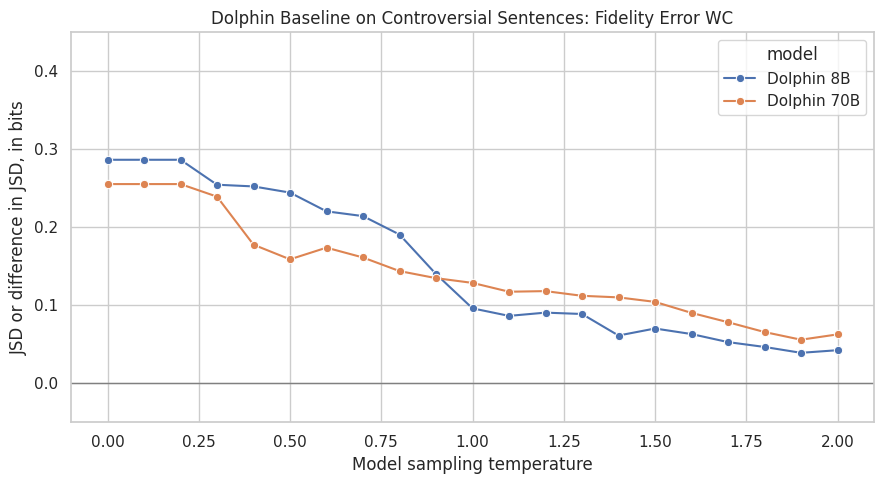

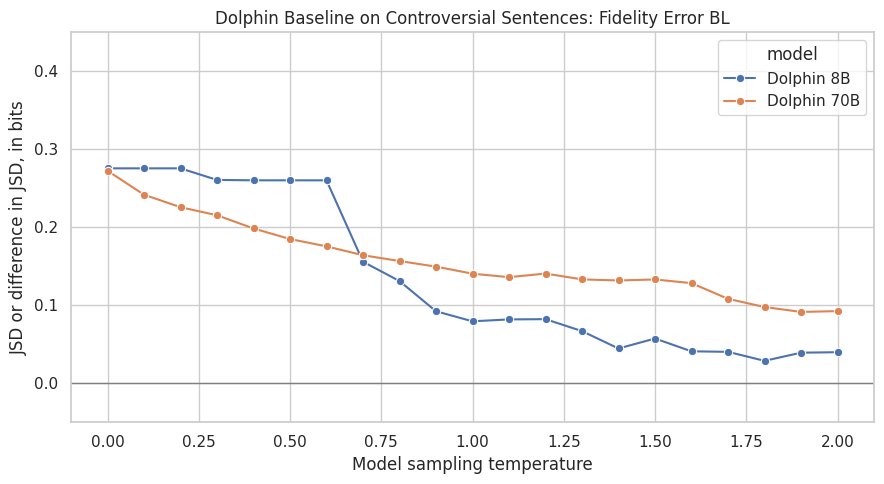

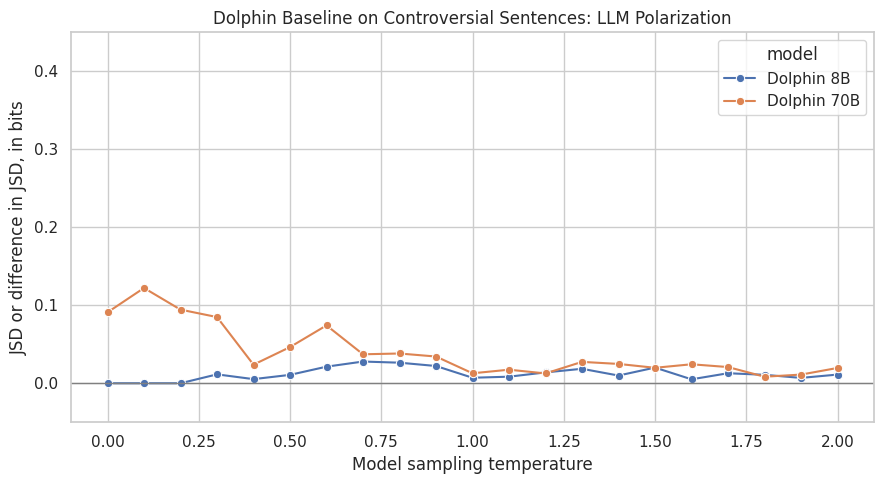

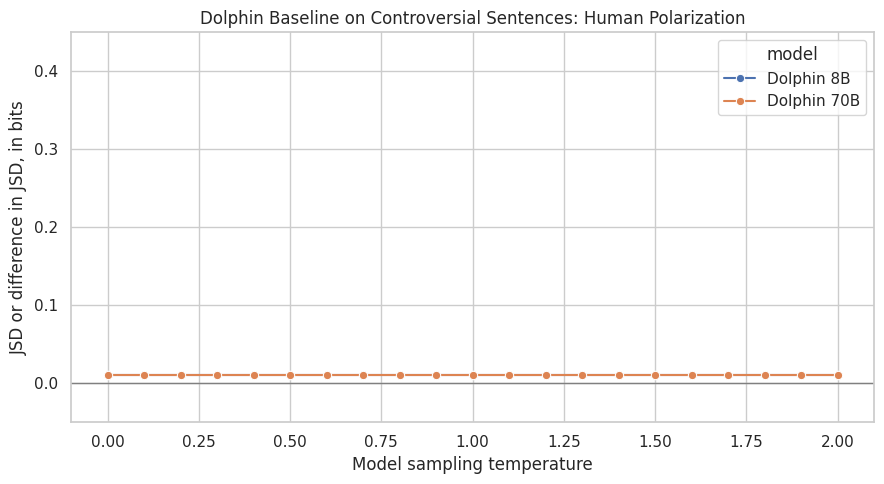

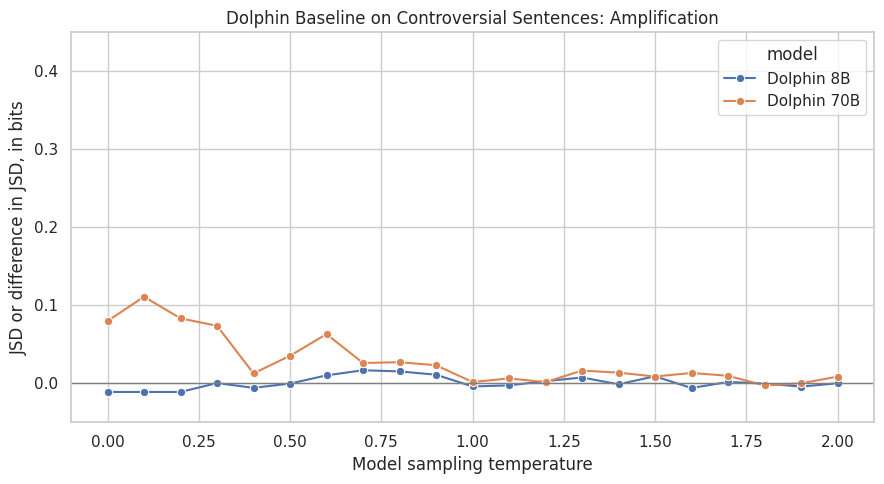

In [192]:
def plot_dolphin_baseline_metrics(summary_df, sentence_set_label):
    metric_configs = [
        ("fid_wc", "Fidelity Error WC"),
        ("fid_bl", "Fidelity Error BL"),
        ("pol_llm", "LLM Polarization"),
        ("pol_hum", "Human Polarization"),
        ("amplification", "Amplification"),
    ]

    for metric, title in metric_configs:
        plt.figure(figsize=(9, 5))

        sns.lineplot(
            data=summary_df,
            x="temperature",
            y=metric,
            hue="model",
            marker="o",
        )

        plt.axhline(0, color="gray", linewidth=1)
        plt.title(f"Dolphin Baseline on {sentence_set_label} Sentences: {title}")
        plt.xlabel("Model sampling temperature")
        plt.ylabel("JSD or difference in JSD, in bits")
        plt.ylim(JSD_YLIM)
        plt.tight_layout()
        plt.show()


plot_dolphin_baseline_metrics(
    dolphin_controversial_baseline_summary,
    sentence_set_label="Controversial",
)

In [193]:
dolphin8b_consensus_baseline_summary, dolphin8b_consensus_baseline_details = process_instruct_baseline_folder(
    folder_path="./data_dolphin_consensus",
    filename_template="dolphin8b_consensus_baseline_T{temp}_N50.csv",
    prompt_variant_label="Dolphin 8B baseline",
)

dolphin70b_consensus_baseline_summary, dolphin70b_consensus_baseline_details = process_instruct_baseline_folder(
    folder_path="./data_dolphin_consensus70",
    filename_template="dolphin70b_consensus_baseline_T{temp}_N50.csv",
    prompt_variant_label="Dolphin 70B baseline",
)

dolphin8b_consensus_baseline_summary["model"] = "Dolphin 8B"
dolphin70b_consensus_baseline_summary["model"] = "Dolphin 70B"

dolphin8b_consensus_baseline_summary["sentence_set"] = "Consensus"
dolphin70b_consensus_baseline_summary["sentence_set"] = "Consensus"

dolphin_consensus_baseline_summary = pd.concat(
    [
        dolphin8b_consensus_baseline_summary,
        dolphin70b_consensus_baseline_summary,
    ],
    ignore_index=True,
)

display(dolphin_consensus_baseline_summary)

Processing baseline runs: Dolphin 8B baseline
Folder: data_dolphin_consensus
Successfully processed 21 files.
Processing baseline runs: Dolphin 70B baseline
Folder: data_dolphin_consensus70
Successfully processed 21 files.


,fid_wc,fid_bl,pol_llm,pol_hum,amplification,n_sentences,n_valid_fid_wc,n_valid_fid_bl,n_valid_pol_llm,n_valid_pol_hum,...,all_bl_vote_counts_match_expected,mean_n_human_wc,mean_n_human_bl,min_n_human_wc,min_n_human_bl,prompt_variant,temperature,file_path,model,sentence_set
0,0.291585,0.286241,0.000000,0.008343,-0.008343,20,20,20,20,20,...,True,70.0,19.4,32,7,Dolphin 8B baseline,0.0,data_dolphin_consensus/dolphin8b_consensus_baseline_T0.0_N50.csv,Dolphin 8B,Consensus
1,0.291585,0.286241,0.000000,0.008343,-0.008343,20,20,20,20,20,...,True,70.0,19.4,32,7,Dolphin 8B baseline,0.1,data_dolphin_consensus/dolphin8b_consensus_baseline_T0.1_N50.csv,Dolphin 8B,Consensus
2,0.291585,0.289931,0.003690,0.008343,-0.004653,20,20,20,20,20,...,True,70.0,19.4,32,7,Dolphin 8B baseline,0.2,data_dolphin_consensus/dolphin8b_consensus_baseline_T0.2_N50.csv,Dolphin 8B,Consensus
3,0.291585,0.292233,0.005992,0.008343,-0.002351,20,20,20,20,20,...,True,70.0,19.4,32,7,Dolphin 8B baseline,0.3,data_dolphin_consensus/dolphin8b_consensus_baseline_T0.3_N50.csv,Dolphin 8B,Consensus
4,0.280629,0.277170,0.003225,0.008343,-0.005118,20,20,20,20,20,...,True,70.0,19.4,32,7,Dolphin 8B baseline,0.4,data_dolphin_consensus/dolphin8b_consensus_baseline_T0.4_N50.csv,Dolphin 8B,Consensus
5,0.265317,0.279221,0.003786,0.008343,-0.004557,20,20,20,20,20,...,True,70.0,19.4,32,7,Dolphin 8B baseline,0.5,data_dolphin_consensus/dolphin8b_consensus_baseline_T0.5_N50.csv,Dolphin 8B,Consensus
6,0.246437,0.256273,0.009906,0.008343,0.001563,20,20,20,20,20,...,True,70.0,19.4,32,7,Dolphin 8B baseline,0.6,data_dolphin_consensus/dolphin8b_consensus_baseline_T0.6_N50.csv,Dolphin 8B,Consensus
7,0.220271,0.236356,0.011671,0.008343,0.003328,20,20,20,20,20,...,True,70.0,19.4,32,7,Dolphin 8B baseline,0.7,data_dolphin_consensus/dolphin8b_consensus_baseline_T0.7_N50.csv,Dolphin 8B,Consensus
8,0.198314,0.251670,0.025165,0.008343,0.016822,20,20,20,20,20,...,True,70.0,19.4,32,7,Dolphin 8B baseline,0.8,data_dolphin_consensus/dolphin8b_consensus_baseline_T0.8_N50.csv,Dolphin 8B,Consensus
9,0.208048,0.227978,0.008687,0.008343,0.000344,20,20,20,20,20,...,True,70.0,19.4,32,7,Dolphin 8B baseline,0.9,data_dolphin_consensus/dolphin8b_consensus_baseline_T0.9_N50.csv,Dolphin 8B,Consensus


In [194]:
dolphin_consensus_invalid_vote_audit = dolphin_consensus_baseline_summary[
    [
        "model",
        "sentence_set",
        "temperature",
        "n_sentences",
        "total_invalid_wc_votes",
        "total_invalid_bl_votes",
        "total_invalid_votes",
        "mean_wc_invalid_rate",
        "mean_bl_invalid_rate",
        "all_wc_vote_counts_match_expected",
        "all_bl_vote_counts_match_expected",
        "min_llm_wc_votes_per_sentence",
        "max_llm_wc_votes_per_sentence",
        "min_llm_bl_votes_per_sentence",
        "max_llm_bl_votes_per_sentence",
    ]
].copy()

display(dolphin_consensus_invalid_vote_audit)

print("Total invalid votes for Dolphin baselines on consensus sentences:")
display(
    dolphin_consensus_invalid_vote_audit
    .groupby("model")[["total_invalid_wc_votes", "total_invalid_bl_votes", "total_invalid_votes"]]
    .sum()
)

,model,sentence_set,temperature,n_sentences,total_invalid_wc_votes,total_invalid_bl_votes,total_invalid_votes,mean_wc_invalid_rate,mean_bl_invalid_rate,all_wc_vote_counts_match_expected,all_bl_vote_counts_match_expected,min_llm_wc_votes_per_sentence,max_llm_wc_votes_per_sentence,min_llm_bl_votes_per_sentence,max_llm_bl_votes_per_sentence
0,Dolphin 8B,Consensus,0.0,20,0,0,0,0.000,0.000,True,True,50,50,50,50
1,Dolphin 8B,Consensus,0.1,20,0,0,0,0.000,0.000,True,True,50,50,50,50
2,Dolphin 8B,Consensus,0.2,20,0,0,0,0.000,0.000,True,True,50,50,50,50
3,Dolphin 8B,Consensus,0.3,20,0,0,0,0.000,0.000,True,True,50,50,50,50
4,Dolphin 8B,Consensus,0.4,20,0,0,0,0.000,0.000,True,True,50,50,50,50
5,Dolphin 8B,Consensus,0.5,20,0,0,0,0.000,0.000,True,True,50,50,50,50
6,Dolphin 8B,Consensus,0.6,20,0,3,3,0.000,0.003,True,True,50,50,50,50
7,Dolphin 8B,Consensus,0.7,20,0,7,7,0.000,0.007,True,True,50,50,50,50
8,Dolphin 8B,Consensus,0.8,20,0,16,16,0.000,0.016,True,True,50,50,50,50
9,Dolphin 8B,Consensus,0.9,20,0,21,21,0.000,0.021,True,True,50,50,50,50


Total invalid votes for Dolphin baselines on consensus sentences:


,total_invalid_wc_votes,total_invalid_bl_votes,total_invalid_votes
model,,,
Dolphin 70B,67,76,143
Dolphin 8B,1437,2009,3446


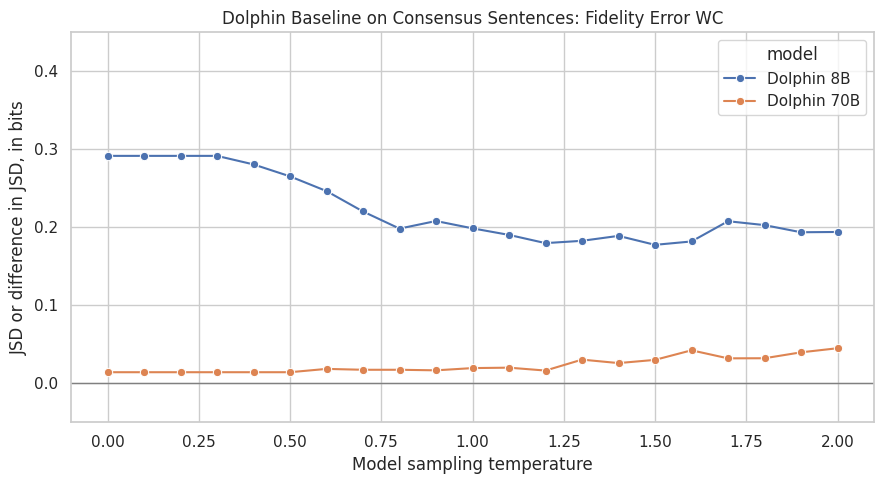

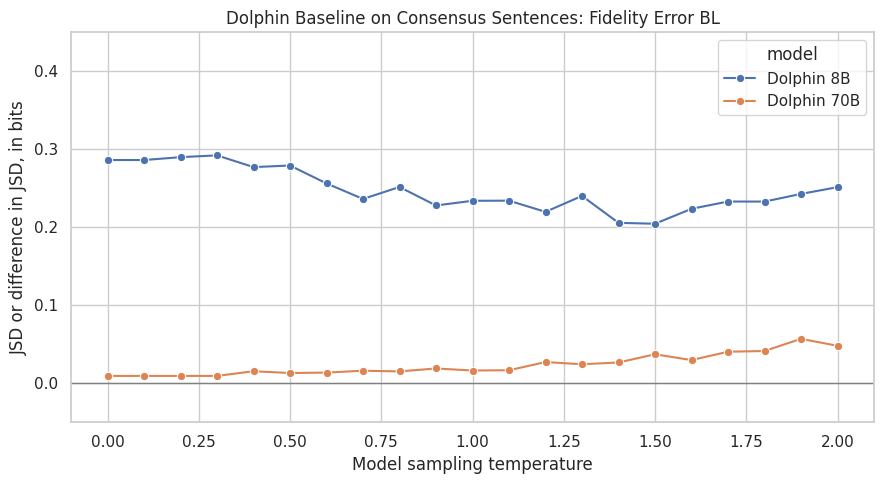

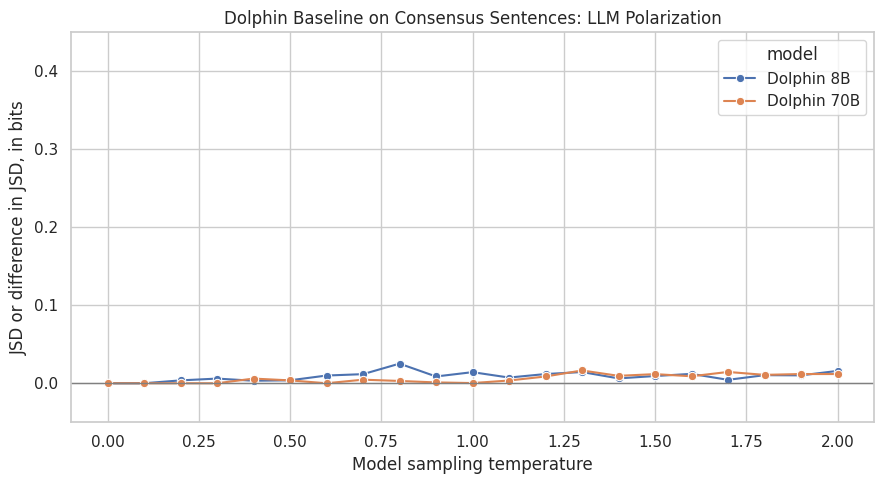

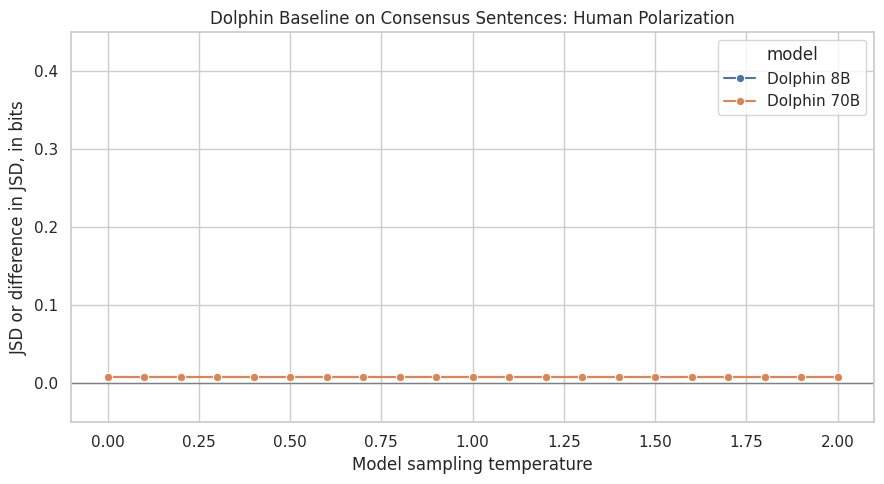

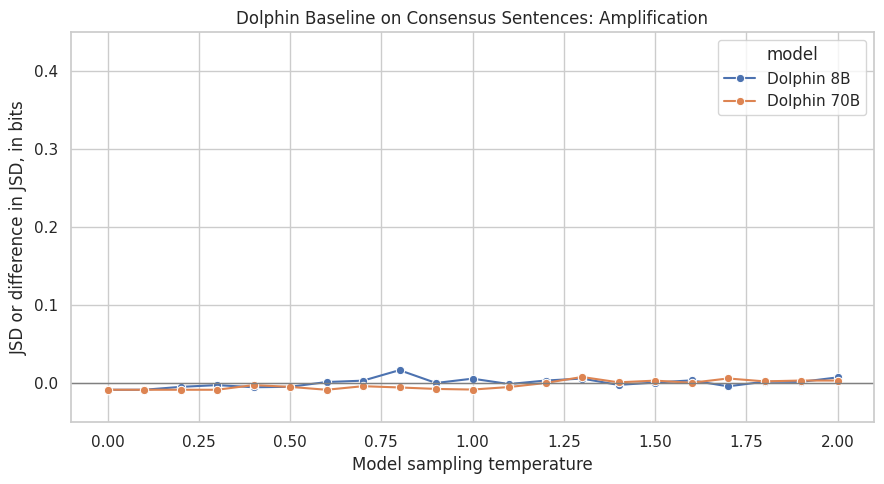

In [195]:
plot_dolphin_baseline_metrics(
    dolphin_consensus_baseline_summary,
    sentence_set_label="Consensus",
)

In [196]:
dolphin_baseline_set_comparison = pd.concat(
    [
        dolphin_controversial_baseline_summary,
        dolphin_consensus_baseline_summary,
    ],
    ignore_index=True,
)

dolphin_baseline_set_comparison["mean_fidelity_error"] = (
    dolphin_baseline_set_comparison["fid_wc"]
    + dolphin_baseline_set_comparison["fid_bl"]
) / 2

display(
    dolphin_baseline_set_comparison[
        [
            "sentence_set",
            "model",
            "temperature",
            "fid_wc",
            "fid_bl",
            "mean_fidelity_error",
            "pol_llm",
            "pol_hum",
            "amplification",
            "total_invalid_votes",
        ]
    ]
)

,sentence_set,model,temperature,fid_wc,fid_bl,mean_fidelity_error,pol_llm,pol_hum,amplification,total_invalid_votes
0,Controversial,Dolphin 8B,0.0,0.286584,0.275584,0.281084,0.000000,0.011169,-0.011169,0
1,Controversial,Dolphin 8B,0.1,0.286584,0.275584,0.281084,0.000000,0.011169,-0.011169,0
2,Controversial,Dolphin 8B,0.2,0.286584,0.275584,0.281084,0.000000,0.011169,-0.011169,0
3,Controversial,Dolphin 8B,0.3,0.254590,0.260750,0.257670,0.011405,0.011169,0.000236,0
4,Controversial,Dolphin 8B,0.4,0.252412,0.260234,0.256323,0.005295,0.011169,-0.005873,0
...,...,...,...,...,...,...,...,...,...,...
79,Consensus,Dolphin 70B,1.6,0.042262,0.029720,0.035991,0.008960,0.008343,0.000617,0
80,Consensus,Dolphin 70B,1.7,0.031954,0.040431,0.036192,0.014497,0.008343,0.006154,1
81,Consensus,Dolphin 70B,1.8,0.032071,0.041376,0.036724,0.010767,0.008343,0.002424,12
82,Consensus,Dolphin 70B,1.9,0.039648,0.056973,0.048310,0.011831,0.008343,0.003489,32


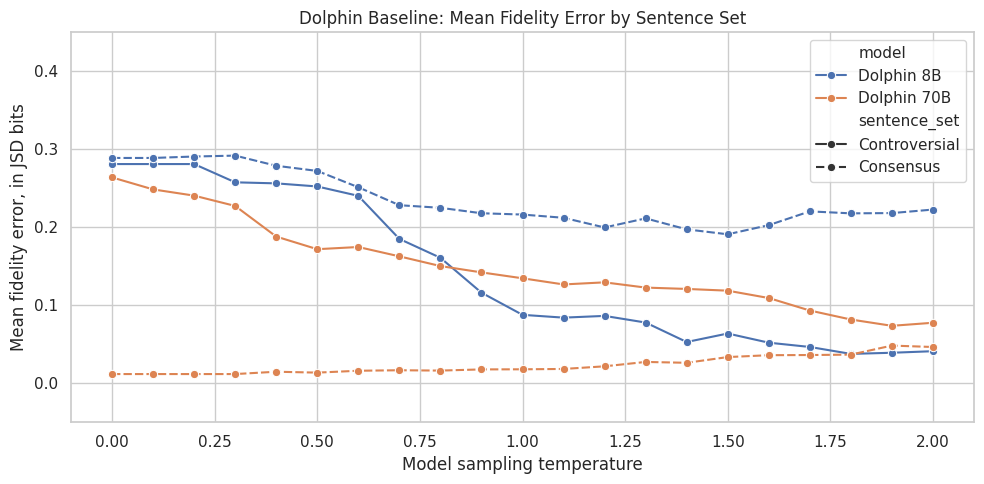

In [197]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=dolphin_baseline_set_comparison,
    x="temperature",
    y="mean_fidelity_error",
    hue="model",
    style="sentence_set",
    marker="o",
)

plt.title("Dolphin Baseline: Mean Fidelity Error by Sentence Set")
plt.xlabel("Model sampling temperature")
plt.ylabel("Mean fidelity error, in JSD bits")
plt.ylim(JSD_YLIM)
plt.tight_layout()
plt.show()

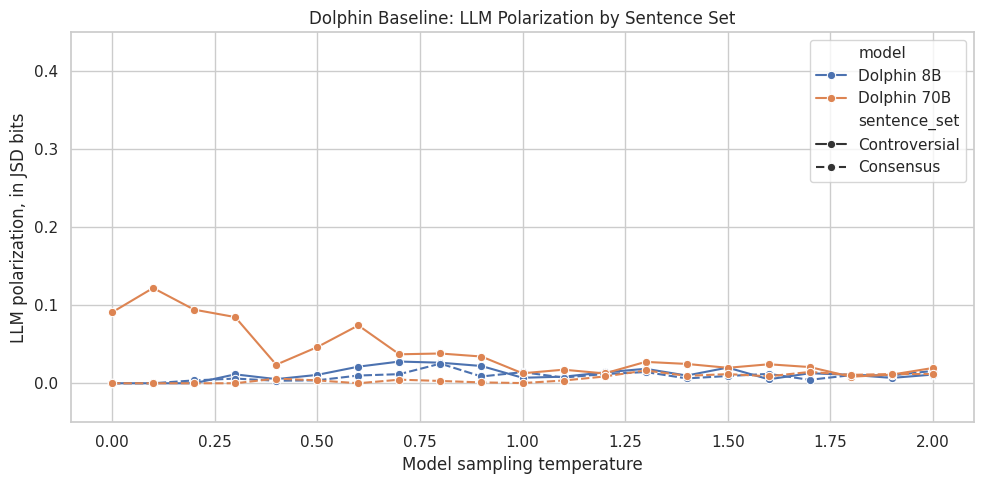

In [198]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=dolphin_baseline_set_comparison,
    x="temperature",
    y="pol_llm",
    hue="model",
    style="sentence_set",
    marker="o",
)

plt.title("Dolphin Baseline: LLM Polarization by Sentence Set")
plt.xlabel("Model sampling temperature")
plt.ylabel("LLM polarization, in JSD bits")
plt.ylim(JSD_YLIM)
plt.tight_layout()
plt.show()

In [199]:
best_dolphin_baseline_rows = []

for (sentence_set, model), group_df in dolphin_baseline_set_comparison.groupby(
    ["sentence_set", "model"]
):
    temp_df = group_df.copy()

    best_mean_fid = (
        temp_df
        .assign(mean_fidelity_error=(temp_df["fid_wc"] + temp_df["fid_bl"]) / 2)
        .loc[lambda x: x["mean_fidelity_error"].idxmin()]
    )

    best_dolphin_baseline_rows.append({
        "sentence_set": sentence_set,
        "model": model,
        "best_temperature_for_mean_fidelity": best_mean_fid["temperature"],
        "best_mean_fidelity_error": best_mean_fid["mean_fidelity_error"],
        "fid_wc_at_best_temp": best_mean_fid["fid_wc"],
        "fid_bl_at_best_temp": best_mean_fid["fid_bl"],
        "pol_llm_at_best_temp": best_mean_fid["pol_llm"],
        "pol_hum_at_best_temp": best_mean_fid["pol_hum"],
        "amplification_at_best_temp": best_mean_fid["amplification"],
        "invalid_votes_at_best_temp": best_mean_fid["total_invalid_votes"],
    })

best_dolphin_baseline_summary = pd.DataFrame(best_dolphin_baseline_rows)

display(best_dolphin_baseline_summary)

,sentence_set,model,best_temperature_for_mean_fidelity,best_mean_fidelity_error,fid_wc_at_best_temp,fid_bl_at_best_temp,pol_llm_at_best_temp,pol_hum_at_best_temp,amplification_at_best_temp,invalid_votes_at_best_temp
0,Consensus,Dolphin 70B,0.0,0.011794,0.014158,0.009430,0.000000,0.008343,-0.008343,0
1,Consensus,Dolphin 8B,1.5,0.191018,0.177489,0.204546,0.009275,0.008343,0.000932,207
2,Controversial,Dolphin 70B,1.9,0.073664,0.055843,0.091485,0.011111,0.011169,-0.000058,6
3,Controversial,Dolphin 8B,1.8,0.037650,0.046561,0.028740,0.010829,0.011169,-0.000340,224


## Appendix summary tables for evaluation items

For reporting purposes, we create compact item-level tables for the two evaluation sets.

The raw sentence text is retained in the exported CSV for traceability, but the paper can report only item IDs, annotator counts, and human hate-speech rates to avoid reproducing offensive text in the main document.

In [200]:
import shutil

APPENDIX_DIR = Path("./appendix_outputs")

if APPENDIX_DIR.exists():
    shutil.rmtree(APPENDIX_DIR)
    print(f"Deleted existing folder: {APPENDIX_DIR}")
else:
    print(f"No existing folder found: {APPENDIX_DIR}")

APPENDIX_DIR.mkdir(exist_ok=True)
print(f"Created fresh folder: {APPENDIX_DIR}")

Deleted existing folder: appendix_outputs
Created fresh folder: appendix_outputs


In [201]:
candidate_item_id_cols = [
    "text_id",
    "comment_id",
    "item_id",
    "post_id",
    "id",
]

available_item_id_cols = [
    col for col in candidate_item_id_cols
    if col in polished_df.columns
]

print("Candidate item-id columns found:")
print(available_item_id_cols)

if "text_id" in polished_df.columns:
    ORIGINAL_ITEM_ID_COL = "text_id"
elif available_item_id_cols:
    ORIGINAL_ITEM_ID_COL = available_item_id_cols[0]
else:
    ORIGINAL_ITEM_ID_COL = None

print(f"Using original item-id column: {ORIGINAL_ITEM_ID_COL}")

if ORIGINAL_ITEM_ID_COL is None:
    print("Warning: no obvious original item-id column found. The table will rely on text matching only.")
else:
    display(
        polished_df[[ORIGINAL_ITEM_ID_COL, "text"]]
        .drop_duplicates()
        .head()
    )

Candidate item-id columns found:
['comment_id']
Using original item-id column: comment_id


,comment_id,text
0,47777,"Yes indeed. She sort of reminds me of the elder lady that played the part in the movie ""Titanic"" who was telling her story!!! And I wouldn't have wanted to cover who I really am!! I would be proud!!!! WE should be pr..."
1,39773,The trans women reading this tweet right now is beautiful
2,47101,"Question: These 4 broads who criticize America, what country did they flee to get here? And now they want to make OUR America like THEIR former HELL HOLE. I don't think so!!!!!!!!!! Let them explain their GRATITUDE ..."
3,43625,It is about time for all illegals to go back to their country of origin and keep our freeway open and prevent heavy traffic.
4,12538,For starters bend over the one in pink and kick that ass and pussy to get a taste until she's begging for a dick inside her.


## Appendix summary tables for evaluation items

For reporting, we create compact item-level summaries for the two evaluation sets.

The key reproducibility column is the original MHS item identifier, such as `text_id`, when available. This allows the items to be traced back to the public MHS dataset without reproducing the full offensive text in the paper.

The exported tables include:

- original MHS item ID;
- evaluation set;
- White Conservative annotator count;
- White Conservative hate-speech rate;
- Black Liberal annotator count;
- Black Liberal hate-speech rate;
- absolute difference between group hate-speech rates;
- human WC--BL polarization measured by Jensen-Shannon Divergence.

In [202]:
def sanitize_text_for_matching(text_series):
    """
    Match the exact text format used in the exported prompt CSVs.
    """

    return (
        text_series
        .astype(str)
        .str.replace(r"[\r\n\t]", " ", regex=True)
    )


def binary_distribution_from_rate(rate):
    """
    Convert a binary hate-speech rate into [P(not hate), P(hate)].
    """

    if pd.isna(rate):
        return None

    return [1 - rate, rate]


def compute_group_item_stats(df_subset, group_label):
    """
    Compute item-level human annotation statistics for one demographic group.

    Returns one row per original item.
    """

    temp = df_subset.copy()

    if "is_hate_speech_binary" not in temp.columns:
        temp["is_hate_speech_binary"] = (temp["hatespeech"] > 0).astype(int)

    temp["text_sanitized"] = sanitize_text_for_matching(temp["text"])

    if ORIGINAL_ITEM_ID_COL is not None:
        group_cols = [ORIGINAL_ITEM_ID_COL, "text_sanitized"]
    else:
        group_cols = ["text_sanitized"]

    stats = (
        temp
        .groupby(group_cols)
        .agg(
            **{
                f"n_{group_label}": ("annotator_id", "nunique"),
                f"n_hate_{group_label}": ("is_hate_speech_binary", "sum"),
                f"n_not_hate_{group_label}": (
                    "is_hate_speech_binary",
                    lambda x: int((x == 0).sum()),
                ),
                f"hate_rate_{group_label}": ("is_hate_speech_binary", "mean"),
            }
        )
        .reset_index()
    )

    return stats

In [203]:
def create_appendix_item_summary(sentence_csv_path, set_name):
    """
    Create an appendix-ready item table for one evaluation sentence set.

    The input sentence CSV contains only text, so we recover the original MHS item ID
    by matching sanitized text back to the MHS dataframe.
    """

    sentence_df = pd.read_csv(sentence_csv_path).copy()

    if "text" not in sentence_df.columns:
        raise ValueError(f"{sentence_csv_path} must contain a 'text' column.")

    sentence_df["text_sanitized"] = sanitize_text_for_matching(sentence_df["text"])
    sentence_df["set"] = set_name

    # Recover original item IDs from the full MHS dataframe.
    item_lookup_cols = ["text_sanitized"]

    full_lookup = polished_df.copy()
    full_lookup["text_sanitized"] = sanitize_text_for_matching(full_lookup["text"])

    if ORIGINAL_ITEM_ID_COL is not None:
        full_lookup = (
            full_lookup[[ORIGINAL_ITEM_ID_COL, "text_sanitized"]]
            .drop_duplicates()
        )

        duplicated_texts = (
            full_lookup
            .groupby("text_sanitized")[ORIGINAL_ITEM_ID_COL]
            .nunique()
            .reset_index(name="n_original_ids")
        )

        ambiguous_texts = duplicated_texts[duplicated_texts["n_original_ids"] > 1]

        if len(ambiguous_texts) > 0:
            print(
                f"Warning: {len(ambiguous_texts)} sanitized texts map to multiple original IDs."
            )
            display(ambiguous_texts.head())

        sentence_df = sentence_df.merge(
            full_lookup,
            on="text_sanitized",
            how="left",
        )

        missing_ids = sentence_df[ORIGINAL_ITEM_ID_COL].isna().sum()
        print(f"{set_name}: missing original item IDs after text matching: {missing_ids}")

    wc_stats = compute_group_item_stats(white_cons_df, "wc")
    bl_stats = compute_group_item_stats(black_libs_df, "bl")

    if ORIGINAL_ITEM_ID_COL is not None:
        merge_cols = [ORIGINAL_ITEM_ID_COL, "text_sanitized"]
    else:
        merge_cols = ["text_sanitized"]

    summary = (
        sentence_df
        .merge(wc_stats, on=merge_cols, how="left")
        .merge(bl_stats, on=merge_cols, how="left")
    )

    summary["abs_hate_rate_difference"] = (
        summary["hate_rate_wc"] - summary["hate_rate_bl"]
    ).abs()

    summary["human_polarization_jsd"] = summary.apply(
        lambda row: calculate_true_jsd(
            binary_distribution_from_rate(row["hate_rate_wc"]),
            binary_distribution_from_rate(row["hate_rate_bl"]),
        ),
        axis=1,
    )

    # Optional display order within each set.
    summary["set_order"] = range(1, len(summary) + 1)

    if ORIGINAL_ITEM_ID_COL is not None:
        ordered_cols = [
            "set",
            "set_order",
            ORIGINAL_ITEM_ID_COL,
            "text",
            "n_wc",
            "n_hate_wc",
            "n_not_hate_wc",
            "hate_rate_wc",
            "n_bl",
            "n_hate_bl",
            "n_not_hate_bl",
            "hate_rate_bl",
            "abs_hate_rate_difference",
            "human_polarization_jsd",
        ]
    else:
        ordered_cols = [
            "set",
            "set_order",
            "text",
            "n_wc",
            "n_hate_wc",
            "n_not_hate_wc",
            "hate_rate_wc",
            "n_bl",
            "n_hate_bl",
            "n_not_hate_bl",
            "hate_rate_bl",
            "abs_hate_rate_difference",
            "human_polarization_jsd",
        ]

    summary = summary[ordered_cols]

    return summary

In [204]:
DISAGREEMENT_SENTENCE_PATH = DATA_DIR / "intersectional_test_sentences_whicon_blalib.csv"
CONSENSUS_SENTENCE_PATH = DATA_DIR / "intersectional_consensus_sentences_whicon_blalib.csv"

disagreement_item_summary = create_appendix_item_summary(
    sentence_csv_path=DISAGREEMENT_SENTENCE_PATH,
    set_name="Disagreement",
)

consensus_item_summary = create_appendix_item_summary(
    sentence_csv_path=CONSENSUS_SENTENCE_PATH,
    set_name="Consensus",
)

display(disagreement_item_summary)
display(consensus_item_summary)

Disagreement: missing original item IDs after text matching: 0
Consensus: missing original item IDs after text matching: 0


,set,set_order,comment_id,text,n_wc,n_hate_wc,n_not_hate_wc,hate_rate_wc,n_bl,n_hate_bl,n_not_hate_bl,hate_rate_bl,abs_hate_rate_difference,human_polarization_jsd
0,Disagreement,1,20070,Who hurt you? Lol. It's comical how stupid and angry you people are. MEH AMURICA. MY LAND. MINE. BANG BANG GUNS. NO BROWN PEOPLE. WAHH.,59,30,29,0.508475,17,7,10,0.411765,0.096710,0.006801
1,Disagreement,2,20018,"RT @JihadistJoe: We Muslims have no military honour whatsoever, we are sub human savages that slaughter unarmed men, women & children http:…",86,49,37,0.569767,21,16,5,0.761905,0.192137,0.030240
2,Disagreement,3,20043,"im ,i hate black people and minorities",33,14,19,0.424242,11,4,7,0.363636,0.060606,0.002777
3,Disagreement,4,20017,"My God look at these BARBARIC PPL. And these pigs all watching. They r a very, very sick culture. And Omar and Rashid want this crap here. This is America not the Middle East. Round them up and send them home.",79,46,33,0.582278,23,16,7,0.695652,0.113374,0.010079
4,Disagreement,5,20040,holy shit i am just getting dunked on by a cripple this is unreal,38,24,14,0.631579,10,7,3,0.700000,0.068421,0.003799
5,Disagreement,6,20051,"It takes belief in false morality to commit atrocities. Those who believe in the false morality of anti-abortion, anti-gay religions are primed for authoritarianism. They use their beliefs to prop themselves up as su...",38,14,24,0.368421,8,2,6,0.250000,0.118421,0.011895
6,Disagreement,7,20034,gay people should die,74,47,27,0.635135,21,12,9,0.571429,0.063707,0.003061
7,Disagreement,8,20038,"Aint nobody wearing those new Westbrook ""Jordan's"" but Mexicans & trailer park trash white girls.",44,28,16,0.636364,16,10,6,0.625000,0.011364,0.000100
8,Disagreement,9,20047,i hate jews so much i wish the holocaust actually happened,79,51,28,0.645570,25,14,11,0.560000,0.085570,0.005523
9,Disagreement,10,20029,Learn the fucking language you fucking useless immigrant.,37,25,12,0.675676,10,7,3,0.700000,0.024324,0.000497


,set,set_order,comment_id,text,n_wc,n_hate_wc,n_not_hate_wc,hate_rate_wc,n_bl,n_hate_bl,n_not_hate_bl,hate_rate_bl,abs_hate_rate_difference,human_polarization_jsd
0,Consensus,1,20012,"""@iamkrause: No need to thank me, killing niggers is it's own reward."" Dis my pal from our graduation when we was 26",88,85,3,0.965909,23,23,0,1.000000,0.034091,0.017259
1,Consensus,2,20003,#whitepower...I'll hang you nigger,72,70,2,0.972222,28,28,0,1.000000,0.027778,0.014030
2,Consensus,3,20049,31 Black Women Who Died In Police Custody URL,74,0,74,0.000000,23,1,22,0.043478,0.043478,0.022088
3,Consensus,4,20025,@L1LTR4P fucking losers wetbacks #SorryNotSorry,32,32,0,1.000000,10,10,0,1.000000,0.000000,0.000000
4,Consensus,5,20001,@Legionary1488 @JomavaesJos now we have a Ebloa case in Texas. If we kill all the niggers we might be safe.,96,96,0,1.000000,21,21,0,1.000000,0.000000,0.000000
5,Consensus,6,20023,Every gook in #LosAngeles should be deported or killed.,76,75,1,0.986842,22,22,0,1.000000,0.013158,0.006610
6,Consensus,7,20007,Every slant in #LosAngeles should be deported. Those scum have no right to be here. Chinatown should be bulldozed.,74,70,4,0.945946,20,19,1,0.950000,0.004054,0.000060
7,Consensus,8,20008,Fuck you fuck you you stupid cheating bitch go lick a dick and die ur a stupid nigger bitch,93,90,3,0.967742,25,24,1,0.960000,0.007742,0.000311
8,Consensus,9,20028,Fucking fagot burn in hell,38,36,2,0.947368,10,10,0,1.000000,0.052632,0.026829
9,Consensus,10,20010,"Hey ,muslim dickhead !!!!!!!! Why don;t you go and shove Allah or whatever the fuck you call the retard up your stupid backwards ass !!!!!!!!! You fucking muslims are a bunch of jealous west hating mongs, Islam is a ...",74,72,2,0.972973,18,17,1,0.944444,0.028529,0.003782


In [205]:
def validate_appendix_summary(summary_df, expected_min_annotators=5):
    validation = {
        "n_items": len(summary_df),
        "missing_wc_stats": summary_df["n_wc"].isna().sum(),
        "missing_bl_stats": summary_df["n_bl"].isna().sum(),
        "min_n_wc": summary_df["n_wc"].min(),
        "min_n_bl": summary_df["n_bl"].min(),
        "all_wc_have_min_annotators": (summary_df["n_wc"] >= expected_min_annotators).all(),
        "all_bl_have_min_annotators": (summary_df["n_bl"] >= expected_min_annotators).all(),
        "mean_wc_hate_rate": summary_df["hate_rate_wc"].mean(),
        "mean_bl_hate_rate": summary_df["hate_rate_bl"].mean(),
        "mean_abs_hate_rate_difference": summary_df["abs_hate_rate_difference"].mean(),
        "mean_human_polarization_jsd": summary_df["human_polarization_jsd"].mean(),
    }

    if ORIGINAL_ITEM_ID_COL is not None:
        validation["missing_original_item_ids"] = summary_df[ORIGINAL_ITEM_ID_COL].isna().sum()
        validation["duplicated_original_item_ids"] = summary_df[ORIGINAL_ITEM_ID_COL].duplicated().sum()

    return pd.DataFrame([validation])


print("Disagreement item summary validation:")
display(validate_appendix_summary(disagreement_item_summary))

print("Consensus item summary validation:")
display(validate_appendix_summary(consensus_item_summary))

Disagreement item summary validation:


,n_items,missing_wc_stats,missing_bl_stats,min_n_wc,min_n_bl,all_wc_have_min_annotators,all_bl_have_min_annotators,mean_wc_hate_rate,mean_bl_hate_rate,mean_abs_hate_rate_difference,mean_human_polarization_jsd,missing_original_item_ids,duplicated_original_item_ids
0,11,0,0,33,8,True,True,0.541705,0.561156,0.098792,0.011169,0,0


Consensus item summary validation:


,n_items,missing_wc_stats,missing_bl_stats,min_n_wc,min_n_bl,all_wc_have_min_annotators,all_bl_have_min_annotators,mean_wc_hate_rate,mean_bl_hate_rate,mean_abs_hate_rate_difference,mean_human_polarization_jsd,missing_original_item_ids,duplicated_original_item_ids
0,20,0,0,32,7,True,True,0.637291,0.644815,0.021187,0.008343,0,0


In [206]:
DISAGREEMENT_APPENDIX_PATH = APPENDIX_DIR / "disagreement_items_summary.csv"
CONSENSUS_APPENDIX_PATH = APPENDIX_DIR / "consensus_items_summary.csv"
COMBINED_APPENDIX_PATH = APPENDIX_DIR / "evaluation_items_summary.csv"

disagreement_item_summary.to_csv(DISAGREEMENT_APPENDIX_PATH, index=False)
consensus_item_summary.to_csv(CONSENSUS_APPENDIX_PATH, index=False)

combined_item_summary = pd.concat(
    [disagreement_item_summary, consensus_item_summary],
    ignore_index=True,
)

combined_item_summary.to_csv(COMBINED_APPENDIX_PATH, index=False)

print(f"Saved disagreement summary to: {DISAGREEMENT_APPENDIX_PATH}")
print(f"Saved consensus summary to:    {CONSENSUS_APPENDIX_PATH}")
print(f"Saved combined summary to:     {COMBINED_APPENDIX_PATH}")

Saved disagreement summary to: appendix_outputs/disagreement_items_summary.csv
Saved consensus summary to:    appendix_outputs/consensus_items_summary.csv
Saved combined summary to:     appendix_outputs/evaluation_items_summary.csv


In [207]:
if ORIGINAL_ITEM_ID_COL is not None:
    paper_cols = [
        "set",
        "set_order",
        ORIGINAL_ITEM_ID_COL,
        "n_wc",
        "hate_rate_wc",
        "n_bl",
        "hate_rate_bl",
        "abs_hate_rate_difference",
        "human_polarization_jsd",
    ]
else:
    paper_cols = [
        "set",
        "set_order",
        "n_wc",
        "hate_rate_wc",
        "n_bl",
        "hate_rate_bl",
        "abs_hate_rate_difference",
        "human_polarization_jsd",
    ]

paper_item_summary = combined_item_summary[paper_cols].copy()

for col in [
    "hate_rate_wc",
    "hate_rate_bl",
    "abs_hate_rate_difference",
    "human_polarization_jsd",
]:
    paper_item_summary[col] = paper_item_summary[col].round(3)

PAPER_ITEM_SUMMARY_PATH = APPENDIX_DIR / "evaluation_items_summary_for_latex.csv"

paper_item_summary.to_csv(PAPER_ITEM_SUMMARY_PATH, index=False)

display(paper_item_summary)

print(f"Saved paper-friendly summary to: {PAPER_ITEM_SUMMARY_PATH}")

,set,set_order,comment_id,n_wc,hate_rate_wc,n_bl,hate_rate_bl,abs_hate_rate_difference,human_polarization_jsd
0,Disagreement,1,20070,59,0.508,17,0.412,0.097,0.007
1,Disagreement,2,20018,86,0.570,21,0.762,0.192,0.030
2,Disagreement,3,20043,33,0.424,11,0.364,0.061,0.003
3,Disagreement,4,20017,79,0.582,23,0.696,0.113,0.010
4,Disagreement,5,20040,38,0.632,10,0.700,0.068,0.004
5,Disagreement,6,20051,38,0.368,8,0.250,0.118,0.012
6,Disagreement,7,20034,74,0.635,21,0.571,0.064,0.003
7,Disagreement,8,20038,44,0.636,16,0.625,0.011,0.000
8,Disagreement,9,20047,79,0.646,25,0.560,0.086,0.006
9,Disagreement,10,20029,37,0.676,10,0.700,0.024,0.000


Saved paper-friendly summary to: appendix_outputs/evaluation_items_summary_for_latex.csv


## Chain-of-Persona on the Disagreement Set: instruct model

We now evaluate Chain-of-Persona prompting on the Disagreement Set for the instruction-tuned model.

Unlike the baseline setting, the annotation temperature is fixed at a low value. The x-axis is the persona-generation temperature, which controls how diverse the generated sub-personas are.

We compare two persona-generation strategies:

- Strategy 1: unconstrained sub-persona generation.
- Strategy 2: anchored sub-persona generation.

For each prompt mode, we plot WC and BL fidelity error as a function of persona-generation temperature. Lower values indicate closer agreement between the LLM-simulated vote distribution and the corresponding human demographic distribution.

In [213]:
def process_cop_folder(
    folder_path,
    filename_template,
    prompt_mode_label,
    tann=0.1,
    temperatures=TEMPS,
):
    """
    Process Chain-of-Persona runs for one prompt mode.

    The function expects one file per:
    - strategy in {1, 2}
    - persona-generation temperature in temperatures

    Each file is analyzed with analyze_binary_llm_file().
    """

    folder_path = Path(folder_path)
    summaries = []
    details = {}

    print(f"Processing CoP runs: {prompt_mode_label}")
    print(f"Folder: {folder_path}")

    for strategy in [1, 2]:
        for tgen in temperatures:
            file_path = folder_path / filename_template.format(
                strategy=strategy,
                tgen=tgen,
                tann=tann,
            )

            if not file_path.exists():
                print(f"Missing file: {file_path.name}")
                continue

            df_llm = pd.read_csv(file_path)

            summary, detail_df = analyze_binary_llm_file(
                df_llm=df_llm,
                df_human_wc=white_cons_df,
                df_human_bl=black_libs_df,
                expected_votes_per_sentence=EXPECTED_N_LLM_VOTES,
            )

            summary.update({
                "prompt_mode": prompt_mode_label,
                "strategy": f"Strategy {strategy}",
                "strategy_id": strategy,
                "tgen": tgen,
                "tann": tann,
                "file_path": str(file_path),
            })

            summaries.append(summary)
            details[(strategy, tgen)] = detail_df

    if len(summaries) == 0:
        print(f"No matching CoP files found for {prompt_mode_label}.")
        return pd.DataFrame(), details

    summary_df = (
        pd.DataFrame(summaries)
        .sort_values(["strategy_id", "tgen"])
        .reset_index(drop=True)
    )

    print(f"Successfully processed {len(summary_df)} files.")

    return summary_df, details

In [231]:
def make_cop_fidelity_long(summary_df):
    """
    Convert CoP summary dataframe to long format for plotting WC and BL fidelity.

    Each row in the returned dataframe corresponds to one:
    - sentence set
    - prompt mode
    - strategy
    - persona-generation temperature
    - demographic persona
    """

    plot_rows = []

    for _, row in summary_df.iterrows():
        plot_rows.append({
            "sentence_set": row.get("sentence_set", None),
            "prompt_mode": row["prompt_mode"],
            "strategy": row["strategy"],
            "strategy_id": row["strategy_id"],
            "tgen": row["tgen"],
            "tann": row["tann"],
            "persona": "WC",
            "fidelity_error": row["fid_wc"],
        })

        plot_rows.append({
            "sentence_set": row.get("sentence_set", None),
            "prompt_mode": row["prompt_mode"],
            "strategy": row["strategy"],
            "strategy_id": row["strategy_id"],
            "tgen": row["tgen"],
            "tann": row["tann"],
            "persona": "BL",
            "fidelity_error": row["fid_bl"],
        })

    return pd.DataFrame(plot_rows)

In [232]:
def plot_cop_fidelity_by_prompt_mode_and_set(
    fidelity_long_df,
    prompt_mode_label,
    sentence_set_label,
):
    """
    Plot WC and BL fidelity error for both CoP strategies under one prompt mode.

    Color distinguishes demographic persona.
    Line style distinguishes persona-generation strategy.
    """

    df_plot = fidelity_long_df[
        (fidelity_long_df["prompt_mode"] == prompt_mode_label)
        & (fidelity_long_df["sentence_set"] == sentence_set_label)
    ].copy()

    if df_plot.empty:
        print(f"No data available for prompt mode={prompt_mode_label}, sentence_set={sentence_set_label}")
        return

    plt.figure(figsize=(9, 5))

    sns.lineplot(
        data=df_plot,
        x="tgen",
        y="fidelity_error",
        hue="persona",
        style="strategy",
        markers=True,
        dashes=True,
    )

    plt.axhline(0, color="gray", linewidth=1)
    plt.ylim(JSD_YLIM)
    plt.title(f"CoP Instruct Model on {sentence_set_label} Set: {prompt_mode_label}")
    plt.xlabel("Persona-generation temperature")
    plt.ylabel("Fidelity error, in JSD bits")
    plt.tight_layout()
    plt.show()

In [233]:
cop_aggressive_disagreement_summary, cop_aggressive_disagreement_details = process_cop_folder(
    folder_path="./binary_data4",
    filename_template="llama3_binary_2stage_aggressive_strat{strategy}_Tgen{tgen}_Tann{tann}_N50.csv",
    prompt_mode_label="Aggressive prompt",
    tann=0.1,
)

cop_sandwiched_disagreement_summary, cop_sandwiched_disagreement_details = process_cop_folder(
    folder_path="./binary_data2",
    filename_template="llama3_binary_2stage_strat{strategy}_Tgen{tgen}_Tann{tann}_N50.csv",
    prompt_mode_label="Sandwiched persona prompt",
    tann=0.1,
)

cop_instruct_disagreement_summary = pd.concat(
    [
        cop_aggressive_disagreement_summary,
        cop_sandwiched_disagreement_summary,
    ],
    ignore_index=True,
)

cop_instruct_disagreement_summary["sentence_set"] = "Disagreement"

display(
    cop_instruct_disagreement_summary[
        [
            "sentence_set",
            "prompt_mode",
            "strategy",
            "tgen",
            "tann",
            "fid_wc",
            "fid_bl",
            "pol_llm",
            "pol_hum",
            "amplification",
            "total_invalid_votes",
        ]
    ]
)

Processing CoP runs: Aggressive prompt
Folder: binary_data4
Successfully processed 42 files.
Processing CoP runs: Sandwiched persona prompt
Folder: binary_data2
Successfully processed 42 files.


,sentence_set,prompt_mode,strategy,tgen,tann,fid_wc,fid_bl,pol_llm,pol_hum,amplification,total_invalid_votes
0,Disagreement,Aggressive prompt,Strategy 1,0.0,0.1,0.286584,0.238232,0.090909,0.011169,0.079740,0
1,Disagreement,Aggressive prompt,Strategy 1,0.1,0.1,0.262322,0.238232,0.110801,0.011169,0.099632,0
2,Disagreement,Aggressive prompt,Strategy 1,0.2,0.1,0.229874,0.238232,0.091581,0.011169,0.080412,0
3,Disagreement,Aggressive prompt,Strategy 1,0.3,0.1,0.229779,0.238232,0.083324,0.011169,0.072155,0
4,Disagreement,Aggressive prompt,Strategy 1,0.4,0.1,0.223618,0.238232,0.077016,0.011169,0.065847,0
...,...,...,...,...,...,...,...,...,...,...,...
79,Disagreement,Sandwiched persona prompt,Strategy 2,1.6,0.1,0.258460,0.231570,0.062087,0.011169,0.050918,0
80,Disagreement,Sandwiched persona prompt,Strategy 2,1.7,0.1,0.270199,0.228281,0.063355,0.011169,0.052186,0
81,Disagreement,Sandwiched persona prompt,Strategy 2,1.8,0.1,0.262478,0.229733,0.060506,0.011169,0.049337,0
82,Disagreement,Sandwiched persona prompt,Strategy 2,1.9,0.1,0.263027,0.231570,0.056330,0.011169,0.045161,0


In [234]:
cop_invalid_audit_cols = [
    "sentence_set",
    "prompt_mode",
    "strategy",
    "tgen",
    "tann",
    "n_sentences",
    "total_invalid_wc_votes",
    "total_invalid_bl_votes",
    "total_invalid_votes",
    "mean_wc_invalid_rate",
    "mean_bl_invalid_rate",
    "all_wc_vote_counts_match_expected",
    "all_bl_vote_counts_match_expected",
]

cop_instruct_disagreement_invalid_audit = cop_instruct_disagreement_summary[
    cop_invalid_audit_cols
].copy()

display(cop_instruct_disagreement_invalid_audit)

print("Total invalid votes across Instruct CoP disagreement runs:")
display(
    cop_instruct_disagreement_invalid_audit
    .groupby(["prompt_mode", "strategy"])[
        ["total_invalid_wc_votes", "total_invalid_bl_votes", "total_invalid_votes"]
    ]
    .sum()
)

,sentence_set,prompt_mode,strategy,tgen,tann,n_sentences,total_invalid_wc_votes,total_invalid_bl_votes,total_invalid_votes,mean_wc_invalid_rate,mean_bl_invalid_rate,all_wc_vote_counts_match_expected,all_bl_vote_counts_match_expected
0,Disagreement,Aggressive prompt,Strategy 1,0.0,0.1,11,0,0,0,0.0,0.0,True,True
1,Disagreement,Aggressive prompt,Strategy 1,0.1,0.1,11,0,0,0,0.0,0.0,True,True
2,Disagreement,Aggressive prompt,Strategy 1,0.2,0.1,11,0,0,0,0.0,0.0,True,True
3,Disagreement,Aggressive prompt,Strategy 1,0.3,0.1,11,0,0,0,0.0,0.0,True,True
4,Disagreement,Aggressive prompt,Strategy 1,0.4,0.1,11,0,0,0,0.0,0.0,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,Disagreement,Sandwiched persona prompt,Strategy 2,1.6,0.1,11,0,0,0,0.0,0.0,True,True
80,Disagreement,Sandwiched persona prompt,Strategy 2,1.7,0.1,11,0,0,0,0.0,0.0,True,True
81,Disagreement,Sandwiched persona prompt,Strategy 2,1.8,0.1,11,0,0,0,0.0,0.0,True,True
82,Disagreement,Sandwiched persona prompt,Strategy 2,1.9,0.1,11,0,0,0,0.0,0.0,True,True


Total invalid votes across Instruct CoP disagreement runs:


total_invalid_wc_votes  \
prompt_mode               strategy                             
Aggressive prompt         Strategy 1                       0   
                          Strategy 2                       0   
Sandwiched persona prompt Strategy 1                       0   
                          Strategy 2                       0   

                                      total_invalid_bl_votes  \
prompt_mode               strategy                             
Aggressive prompt         Strategy 1                       0   
                          Strategy 2                       0   
Sandwiched persona prompt Strategy 1                       0   
                          Strategy 2                       0   

                                      total_invalid_votes  
prompt_mode               strategy                         
Aggressive prompt         Strategy 1                    0  
                          Strategy 2                    0  
Sandwiched persona prompt Strategy 1                    0  
                          Strategy 2                    0

,sentence_set,prompt_mode,strategy,strategy_id,tgen,tann,persona,fidelity_error
0,Disagreement,Aggressive prompt,Strategy 1,1,0.0,0.1,WC,0.286584
1,Disagreement,Aggressive prompt,Strategy 1,1,0.0,0.1,BL,0.238232
2,Disagreement,Aggressive prompt,Strategy 1,1,0.1,0.1,WC,0.262322
3,Disagreement,Aggressive prompt,Strategy 1,1,0.1,0.1,BL,0.238232
4,Disagreement,Aggressive prompt,Strategy 1,1,0.2,0.1,WC,0.229874


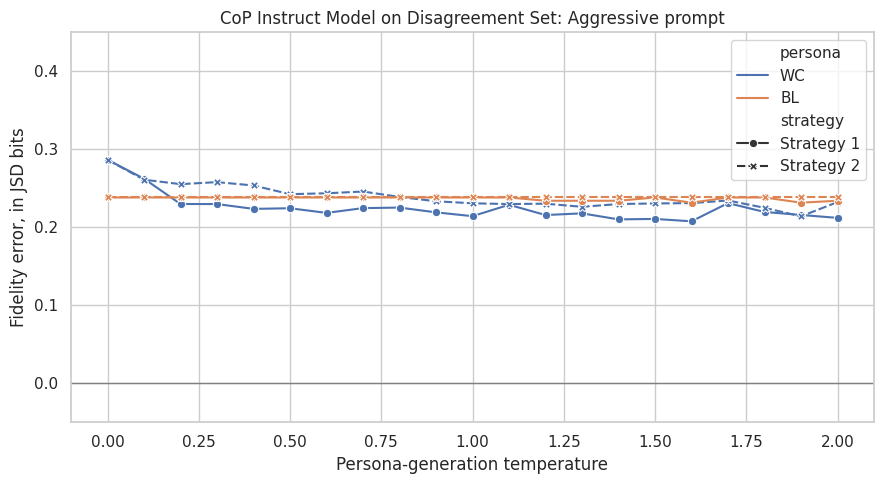

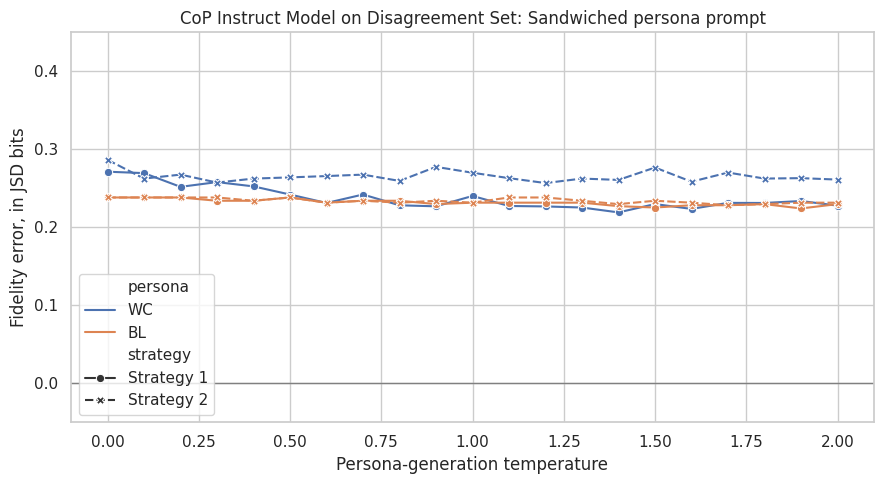

In [235]:
cop_instruct_disagreement_fidelity_long = make_cop_fidelity_long(
    cop_instruct_disagreement_summary
)

display(cop_instruct_disagreement_fidelity_long.head())

plot_cop_fidelity_by_prompt_mode_and_set(
    cop_instruct_disagreement_fidelity_long,
    prompt_mode_label="Aggressive prompt",
    sentence_set_label="Disagreement",
)

plot_cop_fidelity_by_prompt_mode_and_set(
    cop_instruct_disagreement_fidelity_long,
    prompt_mode_label="Sandwiched persona prompt",
    sentence_set_label="Disagreement",
)

## Chain-of-Persona on the Consensus Set

We repeat the same CoP analysis on the Consensus Set. This diagnostic checks whether persona-level variance preserves coherence on items where human annotators largely agree.

A successful method should reduce fidelity error on the Disagreement Set without substantially increasing fidelity error on the Consensus Set.

In [236]:
cop_aggressive_consensus_summary, cop_aggressive_consensus_details = process_cop_folder(
    folder_path="./data_instruct_consensus_aggressive1",
    filename_template="llama3_consensus_2stage_aggressive_strat{strategy}_Tgen{tgen}_Tann{tann}_N50.csv",
    prompt_mode_label="Aggressive prompt",
    tann=0.1,
)

cop_sandwiched_consensus_summary, cop_sandwiched_consensus_details = process_cop_folder(
    folder_path="./data_instruct_consensus_sandwiched2",
    filename_template="llama3_consensus_2stage_sandwiched_strat{strategy}_Tgen{tgen}_Tann{tann}_N50.csv",
    prompt_mode_label="Sandwiched persona prompt",
    tann=0.1,
)

cop_instruct_consensus_summary = pd.concat(
    [
        cop_aggressive_consensus_summary,
        cop_sandwiched_consensus_summary,
    ],
    ignore_index=True,
)

cop_instruct_consensus_summary["sentence_set"] = "Consensus"

display(
    cop_instruct_consensus_summary[
        [
            "sentence_set",
            "prompt_mode",
            "strategy",
            "tgen",
            "tann",
            "fid_wc",
            "fid_bl",
            "pol_llm",
            "pol_hum",
            "amplification",
            "total_invalid_votes",
        ]
    ]
)

Processing CoP runs: Aggressive prompt
Folder: data_instruct_consensus_aggressive1
Successfully processed 42 files.
Processing CoP runs: Sandwiched persona prompt
Folder: data_instruct_consensus_sandwiched2
Successfully processed 42 files.


,sentence_set,prompt_mode,strategy,tgen,tann,fid_wc,fid_bl,pol_llm,pol_hum,amplification,total_invalid_votes
0,Consensus,Aggressive prompt,Strategy 1,0.0,0.1,0.014158,0.00943,0.000000,0.008343,-0.008343,0
1,Consensus,Aggressive prompt,Strategy 1,0.1,0.1,0.014158,0.00943,0.000000,0.008343,-0.008343,0
2,Consensus,Aggressive prompt,Strategy 1,0.2,0.1,0.014158,0.00943,0.000000,0.008343,-0.008343,0
3,Consensus,Aggressive prompt,Strategy 1,0.3,0.1,0.014158,0.00943,0.000000,0.008343,-0.008343,0
4,Consensus,Aggressive prompt,Strategy 1,0.4,0.1,0.014158,0.00943,0.000000,0.008343,-0.008343,0
...,...,...,...,...,...,...,...,...,...,...,...
79,Consensus,Sandwiched persona prompt,Strategy 2,1.6,0.1,0.014158,0.00943,0.000000,0.008343,-0.008343,0
80,Consensus,Sandwiched persona prompt,Strategy 2,1.7,0.1,0.014661,0.00943,0.000504,0.008343,-0.007839,0
81,Consensus,Sandwiched persona prompt,Strategy 2,1.8,0.1,0.014158,0.00943,0.000000,0.008343,-0.008343,0
82,Consensus,Sandwiched persona prompt,Strategy 2,1.9,0.1,0.014158,0.00943,0.000000,0.008343,-0.008343,0


In [237]:
cop_instruct_consensus_invalid_audit = cop_instruct_consensus_summary[
    cop_invalid_audit_cols
].copy()

display(cop_instruct_consensus_invalid_audit)

print("Total invalid votes across Instruct CoP consensus runs:")
display(
    cop_instruct_consensus_invalid_audit
    .groupby(["prompt_mode", "strategy"])[
        ["total_invalid_wc_votes", "total_invalid_bl_votes", "total_invalid_votes"]
    ]
    .sum()
)

,sentence_set,prompt_mode,strategy,tgen,tann,n_sentences,total_invalid_wc_votes,total_invalid_bl_votes,total_invalid_votes,mean_wc_invalid_rate,mean_bl_invalid_rate,all_wc_vote_counts_match_expected,all_bl_vote_counts_match_expected
0,Consensus,Aggressive prompt,Strategy 1,0.0,0.1,20,0,0,0,0.0,0.0,True,True
1,Consensus,Aggressive prompt,Strategy 1,0.1,0.1,20,0,0,0,0.0,0.0,True,True
2,Consensus,Aggressive prompt,Strategy 1,0.2,0.1,20,0,0,0,0.0,0.0,True,True
3,Consensus,Aggressive prompt,Strategy 1,0.3,0.1,20,0,0,0,0.0,0.0,True,True
4,Consensus,Aggressive prompt,Strategy 1,0.4,0.1,20,0,0,0,0.0,0.0,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,Consensus,Sandwiched persona prompt,Strategy 2,1.6,0.1,20,0,0,0,0.0,0.0,True,True
80,Consensus,Sandwiched persona prompt,Strategy 2,1.7,0.1,20,0,0,0,0.0,0.0,True,True
81,Consensus,Sandwiched persona prompt,Strategy 2,1.8,0.1,20,0,0,0,0.0,0.0,True,True
82,Consensus,Sandwiched persona prompt,Strategy 2,1.9,0.1,20,0,0,0,0.0,0.0,True,True


Total invalid votes across Instruct CoP consensus runs:


total_invalid_wc_votes  \
prompt_mode               strategy                             
Aggressive prompt         Strategy 1                       0   
                          Strategy 2                       0   
Sandwiched persona prompt Strategy 1                       0   
                          Strategy 2                       0   

                                      total_invalid_bl_votes  \
prompt_mode               strategy                             
Aggressive prompt         Strategy 1                       0   
                          Strategy 2                       0   
Sandwiched persona prompt Strategy 1                       0   
                          Strategy 2                       0   

                                      total_invalid_votes  
prompt_mode               strategy                         
Aggressive prompt         Strategy 1                    0  
                          Strategy 2                    0  
Sandwiched persona prompt Strategy 1                    0  
                          Strategy 2                    0

,sentence_set,prompt_mode,strategy,strategy_id,tgen,tann,persona,fidelity_error
0,Consensus,Aggressive prompt,Strategy 1,1,0.0,0.1,WC,0.014158
1,Consensus,Aggressive prompt,Strategy 1,1,0.0,0.1,BL,0.009430
2,Consensus,Aggressive prompt,Strategy 1,1,0.1,0.1,WC,0.014158
3,Consensus,Aggressive prompt,Strategy 1,1,0.1,0.1,BL,0.009430
4,Consensus,Aggressive prompt,Strategy 1,1,0.2,0.1,WC,0.014158


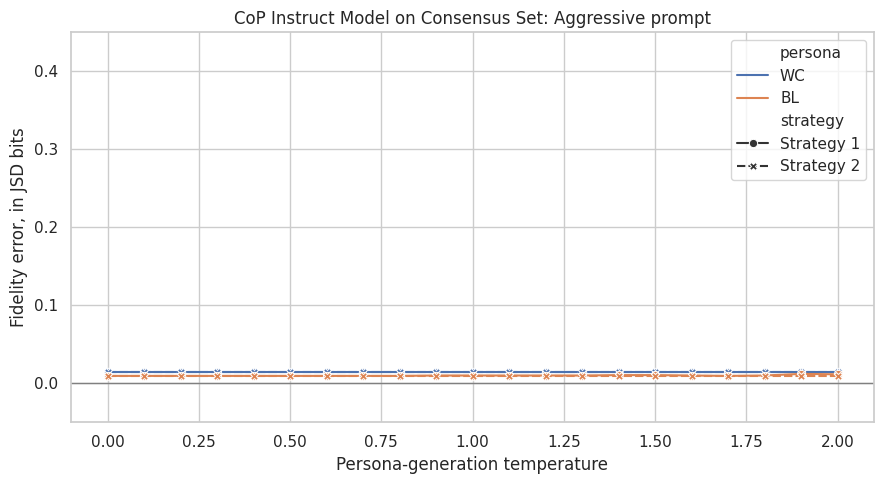

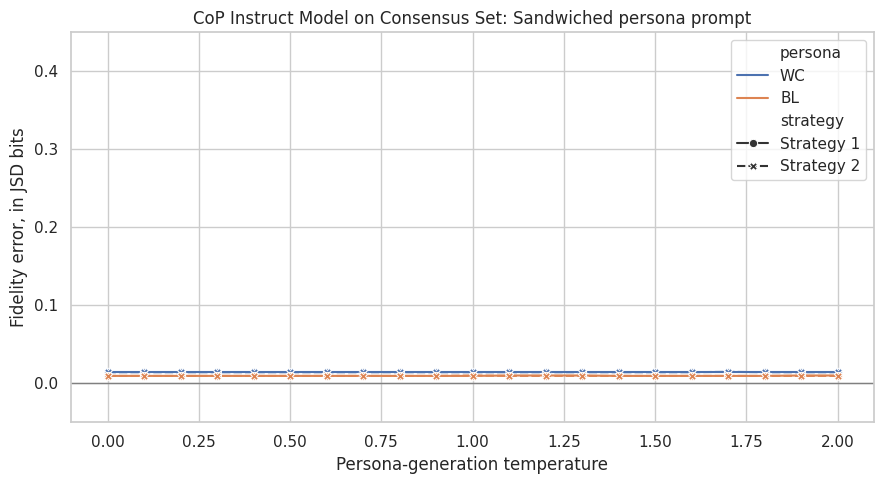

In [238]:
cop_instruct_consensus_fidelity_long = make_cop_fidelity_long(
    cop_instruct_consensus_summary
)

display(cop_instruct_consensus_fidelity_long.head())

plot_cop_fidelity_by_prompt_mode_and_set(
    cop_instruct_consensus_fidelity_long,
    prompt_mode_label="Aggressive prompt",
    sentence_set_label="Consensus",
)

plot_cop_fidelity_by_prompt_mode_and_set(
    cop_instruct_consensus_fidelity_long,
    prompt_mode_label="Sandwiched persona prompt",
    sentence_set_label="Consensus",
)

## Paper-oriented CoP comparison plots

For the paper, we use a compact visualization based on mean fidelity error, defined as the average of WC fidelity error and BL fidelity error.

The following figures compare CoP behavior across:

- Disagreement vs Consensus sentence sets;
- aggressive vs sandwiched prompt modes;
- Strategy 1 vs Strategy 2 persona generation.

A successful CoP configuration should reduce fidelity error on the Disagreement Set without substantially increasing fidelity error on the Consensus Set.

In [239]:
cop_instruct_combined_summary = pd.concat(
    [
        cop_instruct_disagreement_summary,
        cop_instruct_consensus_summary,
    ],
    ignore_index=True,
)

cop_instruct_combined_summary["mean_fidelity_error"] = (
    cop_instruct_combined_summary["fid_wc"]
    + cop_instruct_combined_summary["fid_bl"]
) / 2

display(
    cop_instruct_combined_summary
    .groupby(["sentence_set", "prompt_mode", "strategy"])
    .size()
    .reset_index(name="n_rows")
)

display(
    cop_instruct_combined_summary[
        [
            "sentence_set",
            "prompt_mode",
            "strategy",
            "tgen",
            "tann",
            "fid_wc",
            "fid_bl",
            "mean_fidelity_error",
            "pol_llm",
            "pol_hum",
            "amplification",
            "total_invalid_votes",
        ]
    ]
)

,sentence_set,prompt_mode,strategy,n_rows
0,Consensus,Aggressive prompt,Strategy 1,21
1,Consensus,Aggressive prompt,Strategy 2,21
2,Consensus,Sandwiched persona prompt,Strategy 1,21
3,Consensus,Sandwiched persona prompt,Strategy 2,21
4,Disagreement,Aggressive prompt,Strategy 1,21
5,Disagreement,Aggressive prompt,Strategy 2,21
6,Disagreement,Sandwiched persona prompt,Strategy 1,21
7,Disagreement,Sandwiched persona prompt,Strategy 2,21


,sentence_set,prompt_mode,strategy,tgen,tann,fid_wc,fid_bl,mean_fidelity_error,pol_llm,pol_hum,amplification,total_invalid_votes
0,Disagreement,Aggressive prompt,Strategy 1,0.0,0.1,0.286584,0.238232,0.262408,0.090909,0.011169,0.079740,0
1,Disagreement,Aggressive prompt,Strategy 1,0.1,0.1,0.262322,0.238232,0.250277,0.110801,0.011169,0.099632,0
2,Disagreement,Aggressive prompt,Strategy 1,0.2,0.1,0.229874,0.238232,0.234053,0.091581,0.011169,0.080412,0
3,Disagreement,Aggressive prompt,Strategy 1,0.3,0.1,0.229779,0.238232,0.234006,0.083324,0.011169,0.072155,0
4,Disagreement,Aggressive prompt,Strategy 1,0.4,0.1,0.223618,0.238232,0.230925,0.077016,0.011169,0.065847,0
...,...,...,...,...,...,...,...,...,...,...,...,...
163,Consensus,Sandwiched persona prompt,Strategy 2,1.6,0.1,0.014158,0.009430,0.011794,0.000000,0.008343,-0.008343,0
164,Consensus,Sandwiched persona prompt,Strategy 2,1.7,0.1,0.014661,0.009430,0.012045,0.000504,0.008343,-0.007839,0
165,Consensus,Sandwiched persona prompt,Strategy 2,1.8,0.1,0.014158,0.009430,0.011794,0.000000,0.008343,-0.008343,0
166,Consensus,Sandwiched persona prompt,Strategy 2,1.9,0.1,0.014158,0.009430,0.011794,0.000000,0.008343,-0.008343,0


In [240]:
def plot_cop_mean_fidelity_side_by_side(combined_summary_df):
    """
    Side-by-side paper figure for CoP mean fidelity error.

    Left panel: aggressive prompt.
    Right panel: sandwiched persona prompt.

    Color distinguishes sentence set.
    Line style distinguishes CoP strategy.
    """

    prompt_modes = [
        "Aggressive prompt",
        "Sandwiched persona prompt",
    ]

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(12, 4.5),
        sharey=True,
    )

    for ax, prompt_mode_label in zip(axes, prompt_modes):
        df_plot = combined_summary_df[
            combined_summary_df["prompt_mode"] == prompt_mode_label
        ].copy()

        if df_plot.empty:
            ax.set_title(f"{prompt_mode_label}\nNo data")
            ax.set_ylim(JSD_YLIM)
            continue

        sns.lineplot(
            data=df_plot,
            x="tgen",
            y="mean_fidelity_error",
            hue="sentence_set",
            style="strategy",
            markers=True,
            dashes=True,
            ax=ax,
        )

        ax.axhline(0, color="gray", linewidth=1)
        ax.set_ylim(JSD_YLIM)
        ax.set_title(prompt_mode_label)
        ax.set_xlabel("Persona-generation temperature")
        ax.set_ylabel("Mean fidelity error, in JSD bits")

    handles, labels = axes[0].get_legend_handles_labels()

    for ax in axes:
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()

    fig.legend(
        handles,
        labels,
        loc="lower center",
        ncol=4,
        frameon=False,
        bbox_to_anchor=(0.5, -0.08),
    )

    fig.suptitle("CoP Instruct Model: Mean Fidelity Error", y=1.02)
    plt.tight_layout()
    plt.show()

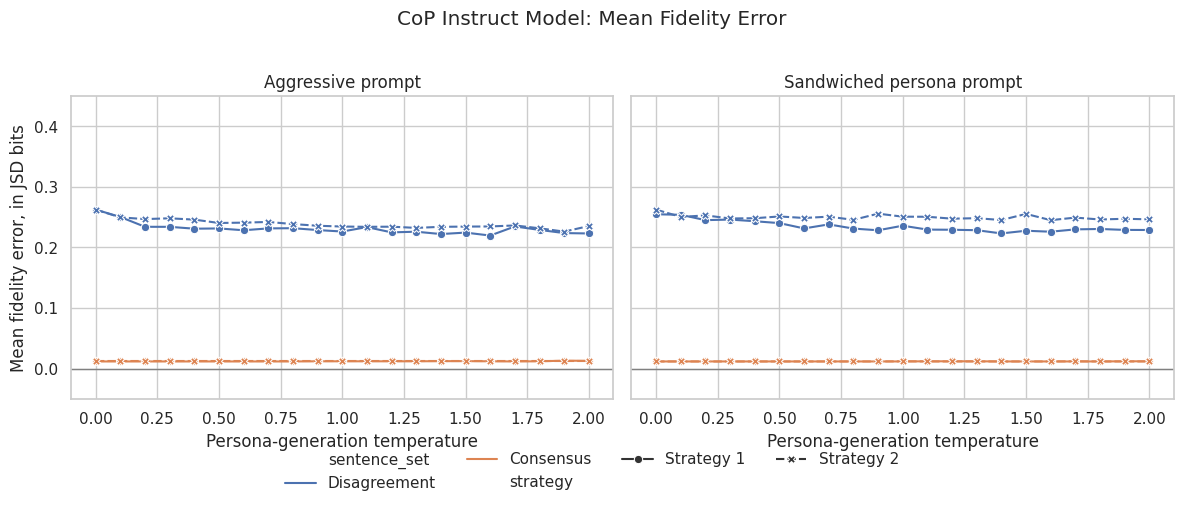

In [241]:
plot_cop_mean_fidelity_side_by_side(cop_instruct_combined_summary)

In [242]:
best_cop_rows = []

for (sentence_set, prompt_mode, strategy), group_df in cop_instruct_combined_summary.groupby(
    ["sentence_set", "prompt_mode", "strategy"]
):
    best_row = group_df.loc[group_df["mean_fidelity_error"].idxmin()]

    best_cop_rows.append({
        "sentence_set": sentence_set,
        "prompt_mode": prompt_mode,
        "strategy": strategy,
        "best_tgen": best_row["tgen"],
        "best_mean_fidelity_error": best_row["mean_fidelity_error"],
        "fid_wc_at_best": best_row["fid_wc"],
        "fid_bl_at_best": best_row["fid_bl"],
        "pol_llm_at_best": best_row["pol_llm"],
        "pol_hum_at_best": best_row["pol_hum"],
        "amplification_at_best": best_row["amplification"],
        "invalid_votes_at_best": best_row["total_invalid_votes"],
    })

best_cop_summary = pd.DataFrame(best_cop_rows)

for col in [
    "best_mean_fidelity_error",
    "fid_wc_at_best",
    "fid_bl_at_best",
    "pol_llm_at_best",
    "pol_hum_at_best",
    "amplification_at_best",
]:
    best_cop_summary[col] = best_cop_summary[col].round(3)

display(best_cop_summary)

,sentence_set,prompt_mode,strategy,best_tgen,best_mean_fidelity_error,fid_wc_at_best,fid_bl_at_best,pol_llm_at_best,pol_hum_at_best,amplification_at_best,invalid_votes_at_best
0,Consensus,Aggressive prompt,Strategy 1,0.0,0.012,0.014,0.009,0.000,0.008,-0.008,0
1,Consensus,Aggressive prompt,Strategy 2,0.0,0.012,0.014,0.009,0.000,0.008,-0.008,0
2,Consensus,Sandwiched persona prompt,Strategy 1,0.0,0.012,0.014,0.009,0.000,0.008,-0.008,0
3,Consensus,Sandwiched persona prompt,Strategy 2,0.0,0.012,0.014,0.009,0.000,0.008,-0.008,0
4,Disagreement,Aggressive prompt,Strategy 1,1.6,0.220,0.208,0.232,0.054,0.011,0.043,0
5,Disagreement,Aggressive prompt,Strategy 2,1.9,0.226,0.214,0.238,0.043,0.011,0.032,0
6,Disagreement,Sandwiched persona prompt,Strategy 1,1.4,0.223,0.219,0.227,0.057,0.011,0.046,0
7,Disagreement,Sandwiched persona prompt,Strategy 2,1.6,0.245,0.258,0.232,0.062,0.011,0.051,0


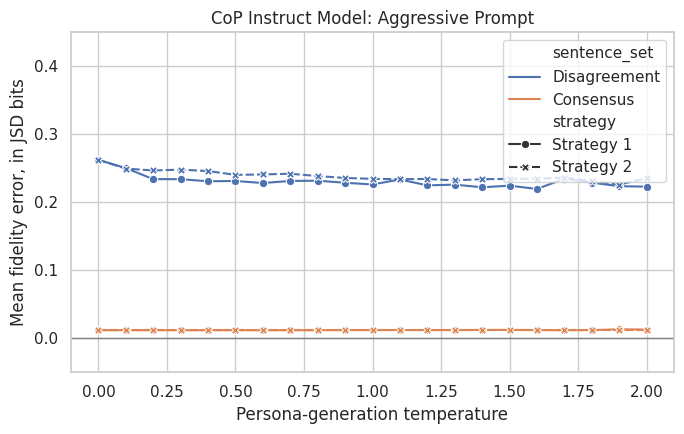

In [244]:
def plot_cop_aggressive_mean_fidelity(combined_summary_df):
    """
    Paper-oriented CoP plot for the aggressive prompt only.

    x-axis: persona-generation temperature
    y-axis: mean fidelity error
    color: sentence set
    line style: CoP strategy
    """

    df_plot = combined_summary_df[
        combined_summary_df["prompt_mode"] == "Aggressive prompt"
    ].copy()

    if df_plot.empty:
        print("No aggressive-prompt CoP data available.")
        return

    plt.figure(figsize=(7, 4.5))

    sns.lineplot(
        data=df_plot,
        x="tgen",
        y="mean_fidelity_error",
        hue="sentence_set",
        style="strategy",
        markers=True,
        dashes=True,
    )

    plt.axhline(0, color="gray", linewidth=1)
    plt.ylim(JSD_YLIM)
    plt.title("CoP Instruct Model: Aggressive Prompt")
    plt.xlabel("Persona-generation temperature")
    plt.ylabel("Mean fidelity error, in JSD bits")
    plt.tight_layout()
    plt.show()


plot_cop_aggressive_mean_fidelity(cop_instruct_combined_summary)

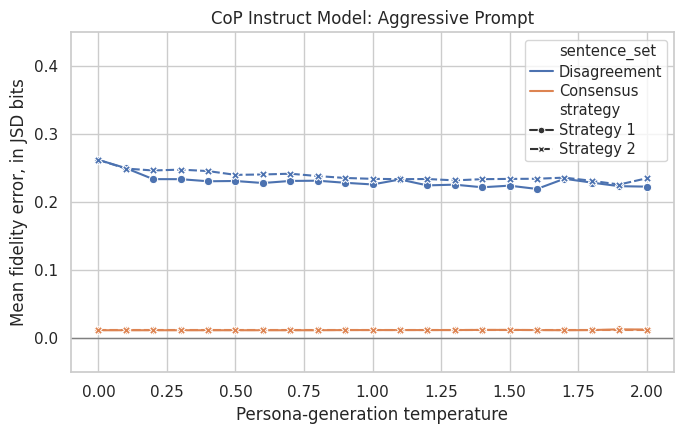

Saved aggressive CoP figure to: figures/cop_instruct_aggressive_mean_fidelity.png


In [246]:
FIGURE_DIR = Path("./figures")
FIGURE_DIR.mkdir(exist_ok=True)

def save_cop_aggressive_mean_fidelity(combined_summary_df, output_path):
    df_plot = combined_summary_df[
        combined_summary_df["prompt_mode"] == "Aggressive prompt"
    ].copy()

    if df_plot.empty:
        raise ValueError("No aggressive-prompt CoP data available.")

    fig, ax = plt.subplots(figsize=(7, 4.5))

    sns.lineplot(
        data=df_plot,
        x="tgen",
        y="mean_fidelity_error",
        hue="sentence_set",
        style="strategy",
        markers=True,
        dashes=True,
        ax=ax,
    )

    ax.axhline(0, color="gray", linewidth=1)
    ax.set_ylim(JSD_YLIM)
    ax.set_title("CoP Instruct Model: Aggressive Prompt")
    ax.set_xlabel("Persona-generation temperature")
    ax.set_ylabel("Mean fidelity error, in JSD bits")

    ax.legend(
    title=None,
    loc="upper right",
    fontsize=10.5,
    markerscale=0.8,
    handlelength=1.6,
    handletextpad=0.4,
    borderpad=0.3,
    labelspacing=0.3,
    frameon=True,
)

    fig.tight_layout()

    fig.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()


COP_AGGRESSIVE_FIGURE_PATH = FIGURE_DIR / "cop_instruct_aggressive_mean_fidelity.png"

save_cop_aggressive_mean_fidelity(
    cop_instruct_combined_summary,
    COP_AGGRESSIVE_FIGURE_PATH,
)

print(f"Saved aggressive CoP figure to: {COP_AGGRESSIVE_FIGURE_PATH}")

## Dolphin 70B baseline comparison

As an additional ablation, we plot the no-CoP Dolphin 70B baseline on both the Disagreement and Consensus sets.

The plot compares mean fidelity error across temperatures, where mean fidelity error is the average of WC fidelity error and BL fidelity error.

In [247]:
# Prepare Dolphin 70B baseline summaries for plotting.

dolphin70b_disagreement_plot = dolphin70b_controversial_baseline_summary.copy()
dolphin70b_disagreement_plot["sentence_set"] = "Disagreement"

dolphin70b_consensus_plot = dolphin70b_consensus_baseline_summary.copy()
dolphin70b_consensus_plot["sentence_set"] = "Consensus"

dolphin70b_baseline_combined = pd.concat(
    [
        dolphin70b_disagreement_plot,
        dolphin70b_consensus_plot,
    ],
    ignore_index=True,
)

dolphin70b_baseline_combined["mean_fidelity_error"] = (
    dolphin70b_baseline_combined["fid_wc"]
    + dolphin70b_baseline_combined["fid_bl"]
) / 2

display(
    dolphin70b_baseline_combined[
        [
            "sentence_set",
            "temperature",
            "fid_wc",
            "fid_bl",
            "mean_fidelity_error",
            "pol_llm",
            "pol_hum",
            "amplification",
            "total_invalid_votes",
        ]
    ]
)

,sentence_set,temperature,fid_wc,fid_bl,mean_fidelity_error,pol_llm,pol_hum,amplification,total_invalid_votes
0,Disagreement,0.0,0.255415,0.272513,0.263964,0.090909,0.011169,0.079740,0
1,Disagreement,0.1,0.255415,0.241767,0.248591,0.122161,0.011169,0.110992,0
2,Disagreement,0.2,0.255415,0.225773,0.240594,0.094418,0.011169,0.083249,0
3,Disagreement,0.3,0.239304,0.215434,0.227369,0.084871,0.011169,0.073702,0
4,Disagreement,0.4,0.177693,0.198508,0.188101,0.023827,0.011169,0.012658,0
5,Disagreement,0.5,0.158908,0.184926,0.171917,0.046387,0.011169,0.035219,0
6,Disagreement,0.6,0.173891,0.175546,0.174718,0.074194,0.011169,0.063025,0
7,Disagreement,0.7,0.161270,0.164198,0.162734,0.037147,0.011169,0.025978,0
8,Disagreement,0.8,0.143854,0.156724,0.150289,0.038163,0.011169,0.026994,0
9,Disagreement,0.9,0.134784,0.149561,0.142172,0.034275,0.011169,0.023106,0


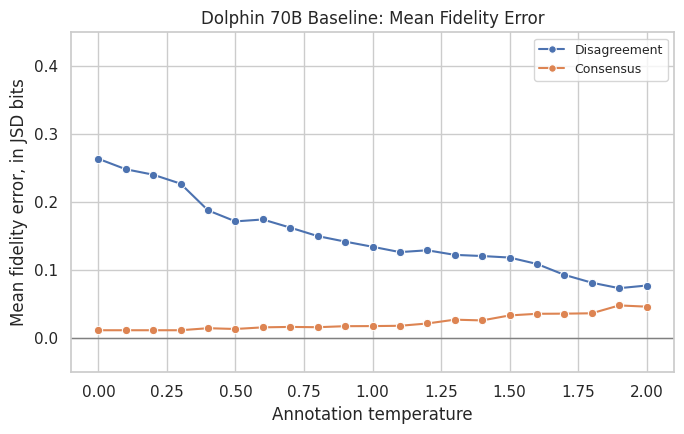

In [248]:
def plot_dolphin70b_baseline_mean_fidelity(summary_df):
    """
    Plot Dolphin 70B baseline mean fidelity error on Disagreement and Consensus sets.
    """

    plt.figure(figsize=(7, 4.5))

    sns.lineplot(
        data=summary_df,
        x="temperature",
        y="mean_fidelity_error",
        hue="sentence_set",
        marker="o",
    )

    plt.axhline(0, color="gray", linewidth=1)
    plt.ylim(JSD_YLIM)
    plt.title("Dolphin 70B Baseline: Mean Fidelity Error")
    plt.xlabel("Annotation temperature")
    plt.ylabel("Mean fidelity error, in JSD bits")
    plt.legend(
        title=None,
        loc="upper right",
        fontsize=9,
        markerscale=0.9,
        frameon=True,
    )
    plt.tight_layout()
    plt.show()


plot_dolphin70b_baseline_mean_fidelity(dolphin70b_baseline_combined)